# 📊 Gehaltsprognose & Interpretation für Data-Berufe (ML-Projekt)

---

### 📌 Projekt-Metadaten

* **Datenquelle:** [Stack Overflow Developer Survey](https://survey.stackoverflow.co/)
* **Untersuchungszeitraum:** 2020–2025

---

### 🔍 Kurzbeschreibung

Entwicklung einer End-to-End-Pipeline zur Vorhersage und Interpretation von Gehältern auf dem internationalen Markt für Data-Berufe. Das Projekt umfasst die Bereinigung von Extremwerten (Ausreißern) via IQR-Methode, das Filtern und Aggregieren spezifischer Data-Rollen sowie das Training robuster Regressionsmodelle. Die Integration von SHAP-Analysen sorgt für maximale Transparenz der Vorhersagen (White-Box-Ansatz), indem der reine wirtschaftliche Effekt einzelner Skills isoliert von Störfaktoren gemessen wird.

---
### 📘 Inhalt
0. Bibliotheken importieren und Daten herunterladen  
1. EDA  
2. Base Model 
3. ML
4. SHAP 
5. Empfehlungssystem 

---



---
## 0. Bibliotheksimport, Datenladen und allgemeine Datenstrukturen

📦 Externe Bibliotheken und Module, die für die Projektdurchführung benötigt werden

In [41]:
# 1. Systemabhängigkeiten (Prozessmanagement, Warnungsfilterung)
import importlib
import os
import re
import warnings
from itertools import product as iterproduct
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

# 2. Datenanalyse-Tools
import numpy as np
import pandas as pd

# 3. Visualisierungsbibliotheken
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# 4. Machine learning
# 4.1. Pipelines und Architektur
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline  # Оставлен чистый sklearn pipeline

# 4.2. Textvorverarbeitung, Imputation und Vektorisierung
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, MultiLabelBinarizer, OneHotEncoder, StandardScaler

# 4.3.Validierung, Clustering und Dekomposition
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity

# 4.4. Basis- und lineare Modelle, Klassifikatoren
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor, StackingRegressor, GradientBoostingRegressor

# 4.5. Gradient Boosting
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# 4.6. Hyperparameter-Optimierung und Modellinterpretierbarkeit
import optuna
import shap
from optuna.samplers import TPESampler
from collections import Counter

# 5. Visualisierung
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 6. Lokale Projektmodule
import config_mappings as cfg
import utils
import devtype_solution


# Module werden automatisch neu gestartet, wenn sich ihr Quellcode (.py) ändert.
importlib.reload(utils)
importlib.reload(cfg)
importlib.reload(devtype_solution)

# Explizite Einfuhr der benötigten Funktionen
from utils import (categorize_currency, 
                   classify_data_role,
                   clean_employment_status,
                   merge_feature_cols,
                   data_split,
                   drop_columns,
                   result,
                   explore_multivalue_column,
                   explore_unique_values,
                   group_rare_categories,
                   load_year,
                   normalize_multivalue_column,
                   normalize_year,
                   optimize_types,
                   overview,
                   replace_rare_with_other,
                   eda_categorical, eda_numeric, fix_apostrophes, impute_work_exp, generate_skill_meta)
from devtype_solution import (
    enrich_devtype_features,
    compute_sample_weights,
    ROLE_CATEGORY_MAPPING,
)

🎨 Globale Visualisierung und Anpassung der Farbpalette

In [2]:
# Erzeugung der gemischten 'tab20'-Palette
# Fixierung des 'seed' zur Gewährleistung der Reproduzierbarkeit der Farbanordnung
base_colors = list(sns.color_palette("tab20", 20).as_hex())
rng = np.random.default_rng(seed=4)
rng.shuffle(base_colors)

# Globale Registrierung der Palette in Seaborn
# Definition der benutzerdefinierten Farbpalette als Standard für alle nachfolgenden Grafiken.
sns.set_palette(sns.color_palette(base_colors))

# Definition von Farb-Konstanten für den manuellen Zugriff
COLORS = base_colors
C_BLUE, C_RED, C_GREEN = COLORS[0], COLORS[1], COLORS[2]

# Konfiguration der globalen Stileinstellungen (RcParams)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFBFB",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": True,
    "grid.color": "#EAEAEA",
    "grid.alpha": 0.8,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "figure.dpi": 100,
    "savefig.bbox": "tight"
})

print("✅ Erfolgreiche Aktivierung von Stil für das gesamte Notebook.")

✅ Erfolgreiche Aktivierung von Stil für das gesamte Notebook.


📂 Historische Daten laden und Funktionsumfang prüfen

In [3]:
# 1. Sequenzielles Laden und Zusammenführen von Daten

# Puffer zum Sammeln verarbeiteter Datenrahmen
frames, loaded, missing = [], [], []
print("⏳ Daten laden...")

# Iteration über das Forschungszeitintervall
for year in list(range(2020, 2026)):
    # Laden des Rohdatenrahmens und des Dateinamens aus dem lokalen Verzeichnis „data“
    df_raw, fname = load_year(year, 'data')

    # Schutz vor fehlenden Dateien
    if df_raw is None:
        print(f"  ❌ {year}: Datei nicht gefunden")
        missing.append(year)
        continue

    # Standardisierung von Spaltennamen und Datentypen gemäß dem Konfigurationsschema
    df_norm = normalize_year(df_raw, year, cfg.schema)
    
    # Anzahl der ausgefüllten Fragebögen mit Zielvariable (Gehalt)
    n_salary = df_norm['salary'].notna().sum()
    
    # Speichern des gelöschten Datenrahmens im Puffer
    frames.append(df_norm)
    loaded.append(year)
    
    # Zeigt ein detailliertes Protokoll der Downloads des laufenden Jahres an
    print(f"✔️ {year}  [{fname:18s}]  {len(df_raw):>7,} Zeilen salary={n_salary:>7,}")

# Abschließende Zusammenführung aller Dateien
df = pd.concat(frames, ignore_index=True)

# 2. Erstellung und Analyse einer Feature-Abdeckungskarte (Feature Coverage Map)

print("\n" + "="*60 + " Feature Coverage Map " + "="*60)

# Hervorhebung nur der wichtigsten Merkmale
feature_cols = [c for c in df.columns if c != 'year']
coverage_records = []

# Überprüfung des Vorhandenseins und der Vollständigkeit der Features für jedes erfolgreich geladene Jahr
for year in sorted(loaded):
    df_yr = df[df['year'] == year]
    row = {'Год': year}
    
    for c in feature_cols:
        # Ein Feature gilt als verfügbar (+), wenn die Spalte existiert und mehr als nur NaN-Werte enthält
        has_data = c in df_yr.columns and df_yr[c].notna().any()
        row[c] = '+' if has_data else '-'
        
    coverage_records.append(row)

# Das Ergebnis ist ein lesbarer DataFrame
df_coverage = pd.DataFrame(coverage_records).set_index('Год')

# Ausgabe der Abdeckungsmatrix
print(df_coverage.to_string())

⏳ Daten laden...
✔️ 2020  [so_2020.csv       ]   64,461 Zeilen salary= 34,756
✔️ 2021  [so_2021.csv       ]   83,439 Zeilen salary= 46,844
✔️ 2022  [so_2022.csv       ]   73,268 Zeilen salary= 38,071
✔️ 2023  [so_2023.csv       ]   89,184 Zeilen salary= 48,019
✔️ 2024  [so_2024.csv       ]   65,437 Zeilen salary= 23,435
✔️ 2025  [so_2025.csv       ]   49,191 Zeilen salary= 23,947

============================================================ Feature Coverage Map ============================================================
     salary currency country work_exp years_code remote branch devtype education employment industry org_size icorpm language_have language_entry database_have database_entry platform_have platform_entry webframe_have webframe_entry tech_have tech_entry ai_have ai_entry ai_select ai_agents
Год                                                                                                                                                                                   

In [4]:
df = merge_feature_cols(df, 'language_have', 'language_entry', 'language')
df = merge_feature_cols(df, 'database_have', 'database_entry', 'database')
df = merge_feature_cols(df, 'platform_have', 'platform_entry', 'platform')
df = merge_feature_cols(df, 'webframe_have', 'webframe_entry', 'webframe')
df = merge_feature_cols(df, 'tech_have', 'tech_entry', 'tech')
df = merge_feature_cols(df, 'ai_have', 'ai_entry', 'ai')
df = drop_columns(df, ['language_have', 'language_entry', 'database_have', 'database_entry', 'platform_have', 'platform_entry', 'webframe_have', 'webframe_entry', 
                       'tech_have', 'tech_entry', 'ai_have', 'ai_entry'])

🧹 Normalisierung von Lückenmustern in Zeichenketten und Behandlung von Textanomalien

In [5]:
# Liste der String-Variationen mit Lücken
nan_variants = ["NaN", "nan", "<NA>", "<na>", "None", "none", "null", ""]

# Spalten nach Datentyp trennen
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Vereinheitlichung kategorischer Auslassungen ('Unknown')
df[cat_cols] = df[cat_cols].map(lambda x: ('Unknown' if pd.isna(x) or str(x).strip() in nan_variants or x is None else x))

# Datenbereinigung der Berufserfahrung (`work_exp`, `years_code`)
df['work_exp'] = df['work_exp'].replace({'Unknown': np.nan}).astype(float)
df['years_code'] = df['years_code'].replace({'Less than 1 year': 0, 'More than 50 years': 51, 'Unknown': np.nan}).astype(float)

print(f"✔️ Verarbeitung abgeschlossen")

✔️ Verarbeitung abgeschlossen


🛠️ Auf Duplikate prüfen

In [6]:
# Auf Duplikate prüfen
print(f"📝 Anzahl der Duplikate: {df.duplicated().sum()}")

if df.duplicated().sum()>0:
    df = df.drop_duplicates(keep='first')
    print(f"✔️ Duplikate entfernt.")

📝 Anzahl der Duplikate: 12545
✔️ Duplikate entfernt.


🗂️ Auswahl von Datenberufen

In [7]:
# Anreicherung der Merkmale aus 'devtype'
df = enrich_devtype_features(df, devtype_col='devtype')
df = drop_columns(df, ['devtype'])

# Bereinigung der 'devtype_data'-Spalte:
df['devtype_data'] = (df['devtype_data'].str.split(";").str[0].str.strip().replace('None', 'Unknown'))

✂️ Ausreißerfilterung (IQR-Methode)

In [8]:
# Entfernung von NaN-Werten in der Zielvariable
df = df.dropna(subset=['salary']).copy()

# Berechnung von Quantilen und Interquartilsabstand (IQR)
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

# Adaptive Obergrenze und feste Untergrenze
upper_bound = Q3 + 3.0 * IQR
lower_bound = 5000  # Bedingtes Null-Einkommen

print(f"📐 Die Grenzen für angemessene Gehälter wurden definiert: von ${lower_bound:,} bis ${upper_bound:,.0f}")

# Filtern des Datenrahmens, Entfernen von Anomalien
df = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)].copy()
df['salary'] = df['salary'] / 1000

📐 Die Grenzen für angemessene Gehälter wurden definiert: von $5,000 bis $343,728


📊 Datenstruktur

In [9]:
print(f"✏️ Datensatzdimension: {df.shape}")

✏️ Datensatzdimension: (198623, 25)


In [10]:
# Transponierte Ausgabe der ersten 5 Zeilen des Dataframes
df.head().T

,7,9,10,11,12
year,2020,2020,2020,2020,2020
salary,116.0,32.315,40.07,14.268,38.916
currency,United States dollar,Pound sterling,Pound sterling,European Euro,European Euro
country,United States,United Kingdom,United Kingdom,Spain,Netherlands
work_exp,NaN,NaN,NaN,NaN,NaN
years_code,17.0,8.0,10.0,7.0,35.0
remote,Unknown,Unknown,Unknown,Unknown,Unknown
branch,I am a developer by profession,I am a developer by profession,I am a developer by profession,I am a developer by profession,"I am not primarily a developer, but I write co..."
education,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Some college/university study without earning ...,"Secondary school (e.g. American high school, G..."
employment,Employed full-time,Employed full-time,Employed full-time,Employed full-time,Employed full-time


In [11]:
# Allgemeiner Überblick über die Datenstruktur
overview(df)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,198623,0,0.000000,6,"[2020, 2021, 2022, 2023, 2024, 2025]"
salary,float64,198623,0,0.000000,28380,"[116.0, 32.315, 40.07, 14.268, 38.916, 66.0, 1..."
currency,str,198623,0,0.000000,275,"[United States dollar, Pound sterling, Europea..."
country,str,198623,0,0.000000,187,"[United States, United Kingdom, Spain, Netherl..."
work_exp,float64,92145,106478,53.608092,66,"[nan, 6.0, 14.0, 5.0, 4.0, 23.0, 9.0, 21.0, 3...."
years_code,float64,197946,677,0.340847,66,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
remote,str,198623,0,0.000000,9,"[Unknown, Hybrid (some remote, some in-person)..."
branch,str,198623,0,0.000000,7,"[I am a developer by profession, I am not prim..."
education,str,198623,0,0.000000,13,"[Bachelor’s degree (B.A., B.S., B.Eng., etc.),..."
employment,str,198623,0,0.000000,60,"[Employed full-time, Independent contractor, f..."


In [12]:
# Deskriptive Statistik numerischer Merkmale
df.describe()

,year,salary,work_exp,years_code,role_count,data_role_purity
count,198623.000000,198623.000000,92145.000000,197946.000000,198623.000000,198623.000000
mean,2022.237289,79.843822,11.802388,15.346226,1.982555,0.078158
std,1.565002,59.079743,9.111844,9.820126,1.838404,0.227722
min,2020.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,2021.000000,36.753000,5.000000,8.000000,1.000000,0.000000
50%,2022.000000,65.663000,10.000000,13.000000,1.000000,0.000000
75%,2023.000000,108.000000,16.000000,20.000000,2.000000,0.000000
max,2025.000000,343.603000,100.000000,100.000000,29.000000,1.000000


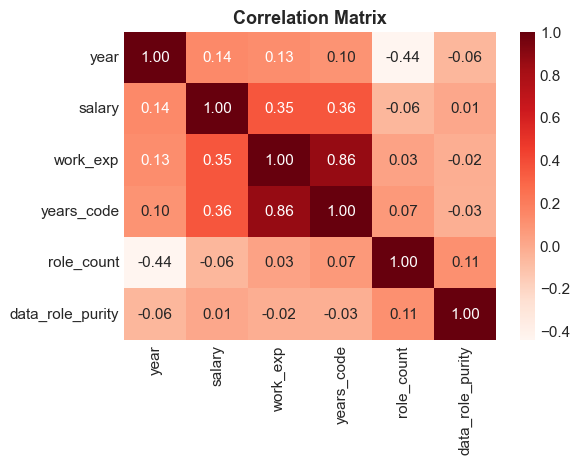

In [13]:
# Correlation Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap=plt.cm.Reds) 
plt.title('Correlation Matrix')
plt.show()

---
## 🔎 1. EDA + Idee für Features Engineering

📈 Analyse der ursprünglichen und logarithmischen Verteilung der Zielvariablen

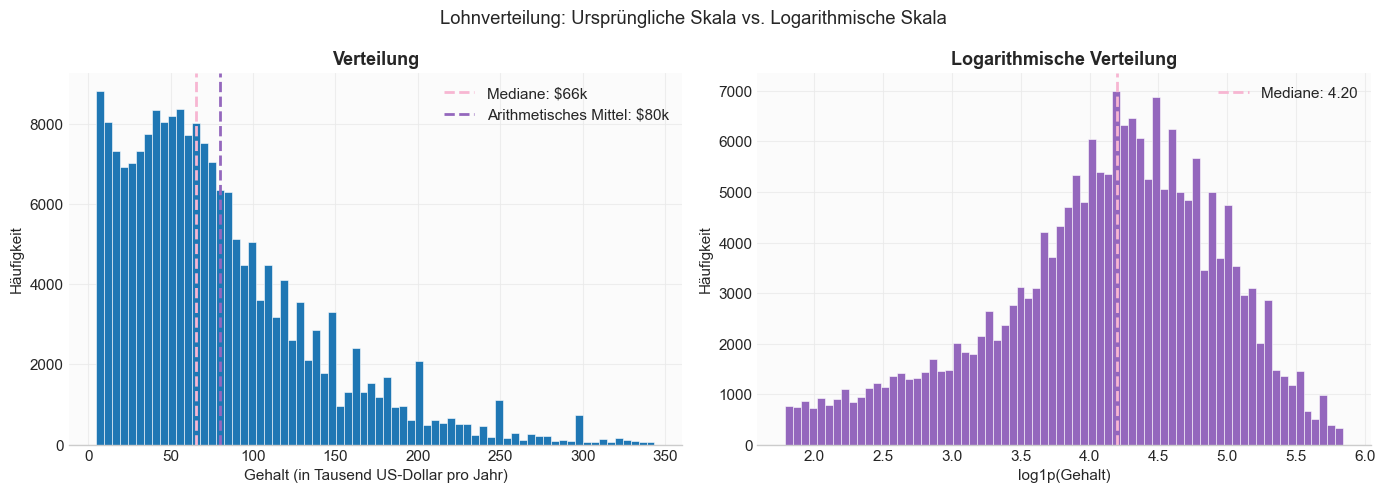

In [14]:
# Initialisieren eines Grafikfensters mit zwei Zeichenbereichen
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lohnverteilung: Ursprüngliche Skala vs. Logarithmische Skala")

# Ursprüngliche Skala
ax[0].hist(df['salary'], bins=70, color=C_BLUE, edgecolor="white", linewidth=0.4)

# Mediane
ax[0].axvline(df['salary'].median(), color=C_RED, lw=2, ls="--", label=f"Mediane: ${df['salary'].median():.0f}k")

# Arithmetisches Mittel
ax[0].axvline(df['salary'].mean(), color=C_GREEN, lw=2, ls="--", label=f"Arithmetisches Mittel: ${df['salary'].mean():.0f}k")

ax[0].set_xlabel("Gehalt (in Tausend US-Dollar pro Jahr)")
ax[0].set_ylabel("Häufigkeit")
ax[0].set_title("Verteilung")
ax[0].legend()

# Logarithmische Verteilung
ax[1].hist(np.log1p(df['salary']), bins=70, color=C_GREEN, edgecolor="white", linewidth=0.4)

# Mediane
ax[1].axvline(np.log1p(df['salary']).median(), color=C_RED, lw=2, ls="--", label=f"Mediane: {np.log1p(df['salary']).median():.2f}")

ax[1].set_xlabel("log1p(Gehalt)")
ax[1].set_ylabel("Häufigkeit")
ax[1].set_title("Logarithmische Verteilung")
ax[1].legend()

plt.tight_layout()
plt.show()

📊 Visualisierung von Mediangehältern und Datenrollenbesetzung

In [15]:
# Dataframe mit neu der Features
df_grp = df.copy()

# Kaskadierende Ausführung der Transformations-Pipeline
df_grp = normalize_multivalue_column(df_grp, 'devtype_data', mapping=cfg.data_role_mapping)
explore_multivalue_column(df_grp[df_grp['devtype_data'] != 'Unknown'], 'devtype_data', top_n = 100)

🔍 Spaltenanalyse: 'devtype_data'
Zeilen: 29,472     Ausgefüllt (Nicht-NaN): 29,472     Eindeutige Werte: 8
Anzeige der ersten 8 Zeilen:
                                Häufigkeit  Anteil (%)
devtype_data                                          
Database Administrator                7894       26.78
Data Engineer                         7402       25.12
Data Scientist / ML specialist        7194       24.41
Data Analyst                          4605       15.62
Scientist                             1863        6.32
AI/ML Engineer                         312        1.06
Applied scientist                      152        0.52
Financial Analyst                       50        0.17
------------------------------------------------------------



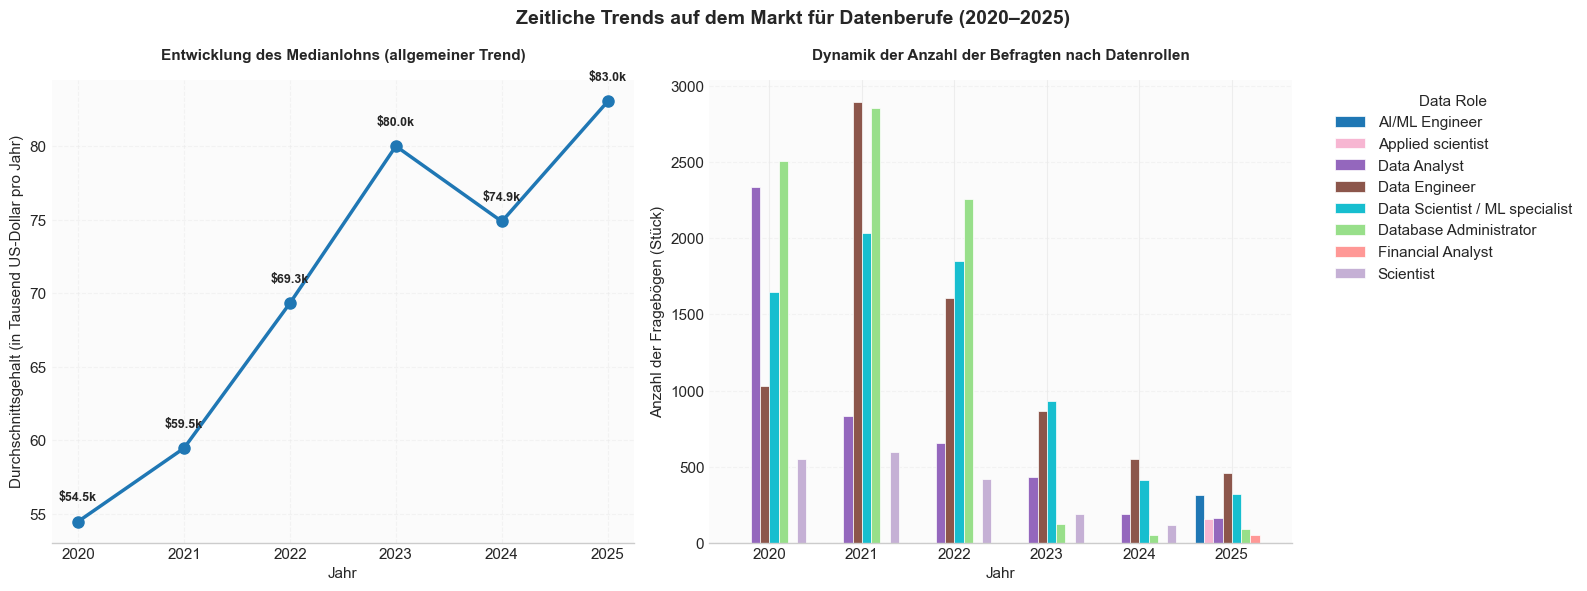

In [16]:
# Initialisieren eines Grafikfensters mit zwei Bereichen
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Zeitliche Trends auf dem Markt für Datenberufe (2020–2025)", fontsize=14, fontweight='bold')

# Aufbereitung aggregierter Daten
yearly_salaries = df_grp[df_grp['devtype_data'] != 'Unknown'].groupby('year')['salary'].median().reset_index()

# Dynamik der Mediangehälter
ax[0].plot(yearly_salaries["year"], yearly_salaries["salary"], 
         marker='o', color=C_BLUE, linewidth=2.5, markersize=8, label="Медиана ($ тыс.)")

# Anbringen von Textbeschriftungen mit genauen Beträgen über den Zeitmarken
for idx, row in yearly_salaries.iterrows():
    ax[0].annotate(f"${row['salary']:.1f}k", 
                 (row['year'], row['salary']),
                 textcoords="offset points", xytext=(0, 15), ha='center', fontsize=9, fontweight='bold')

ax[0].set_title("Entwicklung des Medianlohns (allgemeiner Trend)", fontsize=11, pad=15)
ax[0].set_xlabel("Jahr")
ax[0].set_ylabel("Durchschnittsgehalt (in Tausend US-Dollar pro Jahr)")
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].set_xticks(yearly_salaries["year"])

# Dynamik der Rollenbesetzung

df_exploded = df_grp[df_grp['devtype_data'] != 'Unknown'].assign(data_role_split = df_grp[df_grp['devtype_data'] != 'Unknown']['devtype_data'].str.split(';')
                                                                 ).explode('data_role_split')


df_exploded['data_role_split'] = df_exploded['data_role_split'].str.strip()

df_clean = df_exploded[df_exploded['data_role_split'].notna() & (df_exploded['data_role_split'] != 'None') & 
                       (df_exploded['data_role_split'] != '')]

roles_by_year = df_clean.groupby(['year', 'data_role_split'])['salary'].count().unstack().fillna(0)

roles_by_year.plot(kind="bar", ax=ax[1], edgecolor="white", linewidth=0.5, width=0.8)

ax[1].set_title("Dynamik der Anzahl der Befragten nach Datenrollen", fontsize=11, pad=15)
ax[1].set_xlabel("Jahr")
ax[1].set_ylabel("Anzahl der Fragebögen (Stück)")
ax[1].grid(True, axis='y', linestyle="--", alpha=0.5)
ax[1].tick_params(axis='x', rotation=0)
ax[1].legend(title="Data Role", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#### 💡 Hinweis
Die Stagnation der Stichprobengröße (n) zwischen 2023 und 2025 deutet weder auf eine Schrumpfung des IT-Marktes noch auf einen Rückgang der Nachfrage nach Data-Science-Fachkräften hin. Dieser Trend spiegelt vielmehr einen systematischen Rückgang der Gesamtzahl der Teilnehmer an der Stack-Overflow-Umfrage sowie eine Änderung der internen Validierungsmethodik des Fragebogens der Plattform wider.

🔄 Normalisierung und Aggregatbildung der Features — Features engineering

In [17]:
# Normalisierung und Aggregatbildung von kategorialer Variablen
for c in ['remote', 'branch', 'industry', 'icorpm', 'ai_select']:
    # Replace
    df_grp[c] = df_grp[c].replace(getattr(cfg, f"{c}_mapping"))
    explore_unique_values(df_grp, c) # Häufigkeitskontrolle der Kategorien

# Erstellung des ordinalen Rangs
df_grp['education'] = df_grp['education'].replace(cfg.education_mapping).astype(object)
explore_unique_values(df_grp, 'education') # Häufigkeitskontrolle der Kategorien

df_grp['education_rank'] = df_grp['education'].replace(cfg.education_rank_mapping).astype(object)
explore_unique_values(df_grp, 'education_rank') # Häufigkeitskontrolle der Kategorien

# Erstellung des ordinalen Rangs
df_grp['org_size'] = df_grp['org_size'].replace(cfg.org_size_mapping).astype(object)
explore_unique_values(df_grp, 'org_size') # Häufigkeitskontrolle der Kategorien

df_grp['org_size_rank'] = df_grp['org_size'].replace(cfg.org_size_rank_mapping).astype(object)
explore_unique_values(df_grp, 'org_size_rank') # Häufigkeitskontrolle der Kategorien

# Bereinigung und Standardisierung des Beschäftigungsstatus
df_grp['employment'] = df_grp['employment'].apply(clean_employment_status)
explore_unique_values(df_grp, 'employment') # Häufigkeitskontrolle der Kategorien

# Replace der Land
df_grp['country'] = df_grp['country'].replace({'United States of America': 'United States',
                                               'United Kingdom of Great Britain and Northern Ireland': 'Great Britain'})
# Zusammenfassung von seltenen Ländern zur Reduzierung der Feature-Breite
df_grp['country'] = group_rare_categories(df_grp, 'country')
explore_unique_values(df_grp, 'country') # Häufigkeitskontrolle der Kategorien

🔍 Spaltenanalyse: 'remote'
Zeilen: 198,623     Ausgefüllt (Nicht-NaN): 198,623     Eindeutige Werte: 4
Anzeige der ersten 4 Zeilen:
         Häufigkeit  Anteil (%)
remote                         
Unknown       77708       39.12
Hybrid        53559       26.97
Remote        51182       25.77
On-site       16174        8.14
------------------------------------------------------------

🔍 Spaltenanalyse: 'branch'
Zeilen: 198,623     Ausgefüllt (Nicht-NaN): 198,623     Eindeutige Werte: 3
Anzeige der ersten 3 Zeilen:
                        Häufigkeit  Anteil (%)
branch                                        
Professional                180924       91.09
Coding at Work/Studies       16511        8.31
Other                         1188        0.60
------------------------------------------------------------

🔍 Spaltenanalyse: 'industry'
Zeilen: 198,623     Ausgefüllt (Nicht-NaN): 198,623     Eindeutige Werte: 13
Anzeige der ersten 5 Zeilen:
                                         Häufigkei

In [18]:
# Standardisierung der Gehaltswährungen
df_grp['currency'] = df_grp['currency'].apply(categorize_currency)
# Zusammenfassung von seltenen Währungszeichen zur Reduzierung der Feature-Breite
df_grp['currency'] = group_rare_categories(df_grp, 'currency')
explore_unique_values(df_grp, 'currency') # Häufigkeitskontrolle der Kategorien

🔍 Spaltenanalyse: 'currency'
Zeilen: 198,623     Ausgefüllt (Nicht-NaN): 198,623     Eindeutige Werte: 5
Anzeige der ersten 5 Zeilen:
          Häufigkeit  Anteil (%)
currency                        
Other          68154       34.31
EUR            53747       27.06
USD            52592       26.48
GBP            13818        6.96
INR            10312        5.19
------------------------------------------------------------



In [19]:
# Normalisierung und Aggregatbildung von Multivalue-Variablen (Listenstrukturen)
for c in ['language', 'database', 'platform', 'webframe', 'tech', 'ai']:
    # Dynamisches Laden des passenden Mappings aus der cfg-Klasse (z.B. cfg.language_mapping)
    current_mapping = getattr(cfg, f"{c}_mapping")
    
    # Kaskadierende Ausführung der Transformations-Pipeline
    df_grp = normalize_multivalue_column(df_grp, c, mapping=current_mapping)
    df_grp = replace_rare_with_other(df_grp, c)
    explore_multivalue_column(df_grp, c, top_n = 100)

🔍 Spaltenanalyse: 'language'
Zeilen: 198,623     Ausgefüllt (Nicht-NaN): 198,623     Eindeutige Werte: 19
Anzeige der ersten 19 Zeilen:
                       Häufigkeit  Anteil (%)
language                                     
JavaScript                 130007       65.45
HTML/CSS                   108427       54.59
SQL                        106366       53.55
Python                      88807       44.71
Bash/Shell/PowerShell       81429       41.00
TypeScript                  76895       38.71
Other                       66798       33.63
Java                        59347       29.88
C#                          58512       29.46
PHP                         38453       19.36
C++                         34898       17.57
C                           28552       14.37
Go                          25076       12.62
Rust                        17734        8.93
Kotlin                      17449        8.78
Node.js                     15294        7.70
Ruby                        14783   

In [20]:
overview(df_grp)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,198623,0,0.000000,6,"[2020, 2021, 2022, 2023, 2024, 2025]"
salary,float64,198623,0,0.000000,28380,"[116.0, 32.315, 40.07, 14.268, 38.916, 66.0, 1..."
currency,str,198623,0,0.000000,5,"[USD, GBP, EUR, Other, INR]"
country,str,198623,0,0.000000,5,"[United States, Other, Germany, India, Great B..."
work_exp,float64,92145,106478,53.608092,66,"[nan, 6.0, 14.0, 5.0, 4.0, 23.0, 9.0, 21.0, 3...."
years_code,float64,197946,677,0.340847,66,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
remote,str,198623,0,0.000000,4,"[Unknown, Hybrid, Remote, On-site]"
branch,str,198623,0,0.000000,3,"[Professional, Coding at Work/Studies, Other]"
education,object,198623,0,0.000000,6,"[Bachelor, Master, College / Undergrad, School..."
employment,str,198623,0,0.000000,4,"[Full-time, Freelance, Part-time, Unknown]"


In [21]:
# Features engineering
df_grp["temporal_weight"] = df_grp["year"].map({2020: 0.5, 
                                                2021: 0.7,
                                                2022: 1.0,
                                                2023: 1.5,
                                                2024: 2.5,
                                                2025: 3.0})

df_grp["country_region"] = (df["country"].map(cfg.region_mapping).fillna("Other"))

df_grp = impute_work_exp(df_grp)

df_grp['country_region'] = (df_grp['country'].map(cfg.region_mapping).fillna('Other')) 

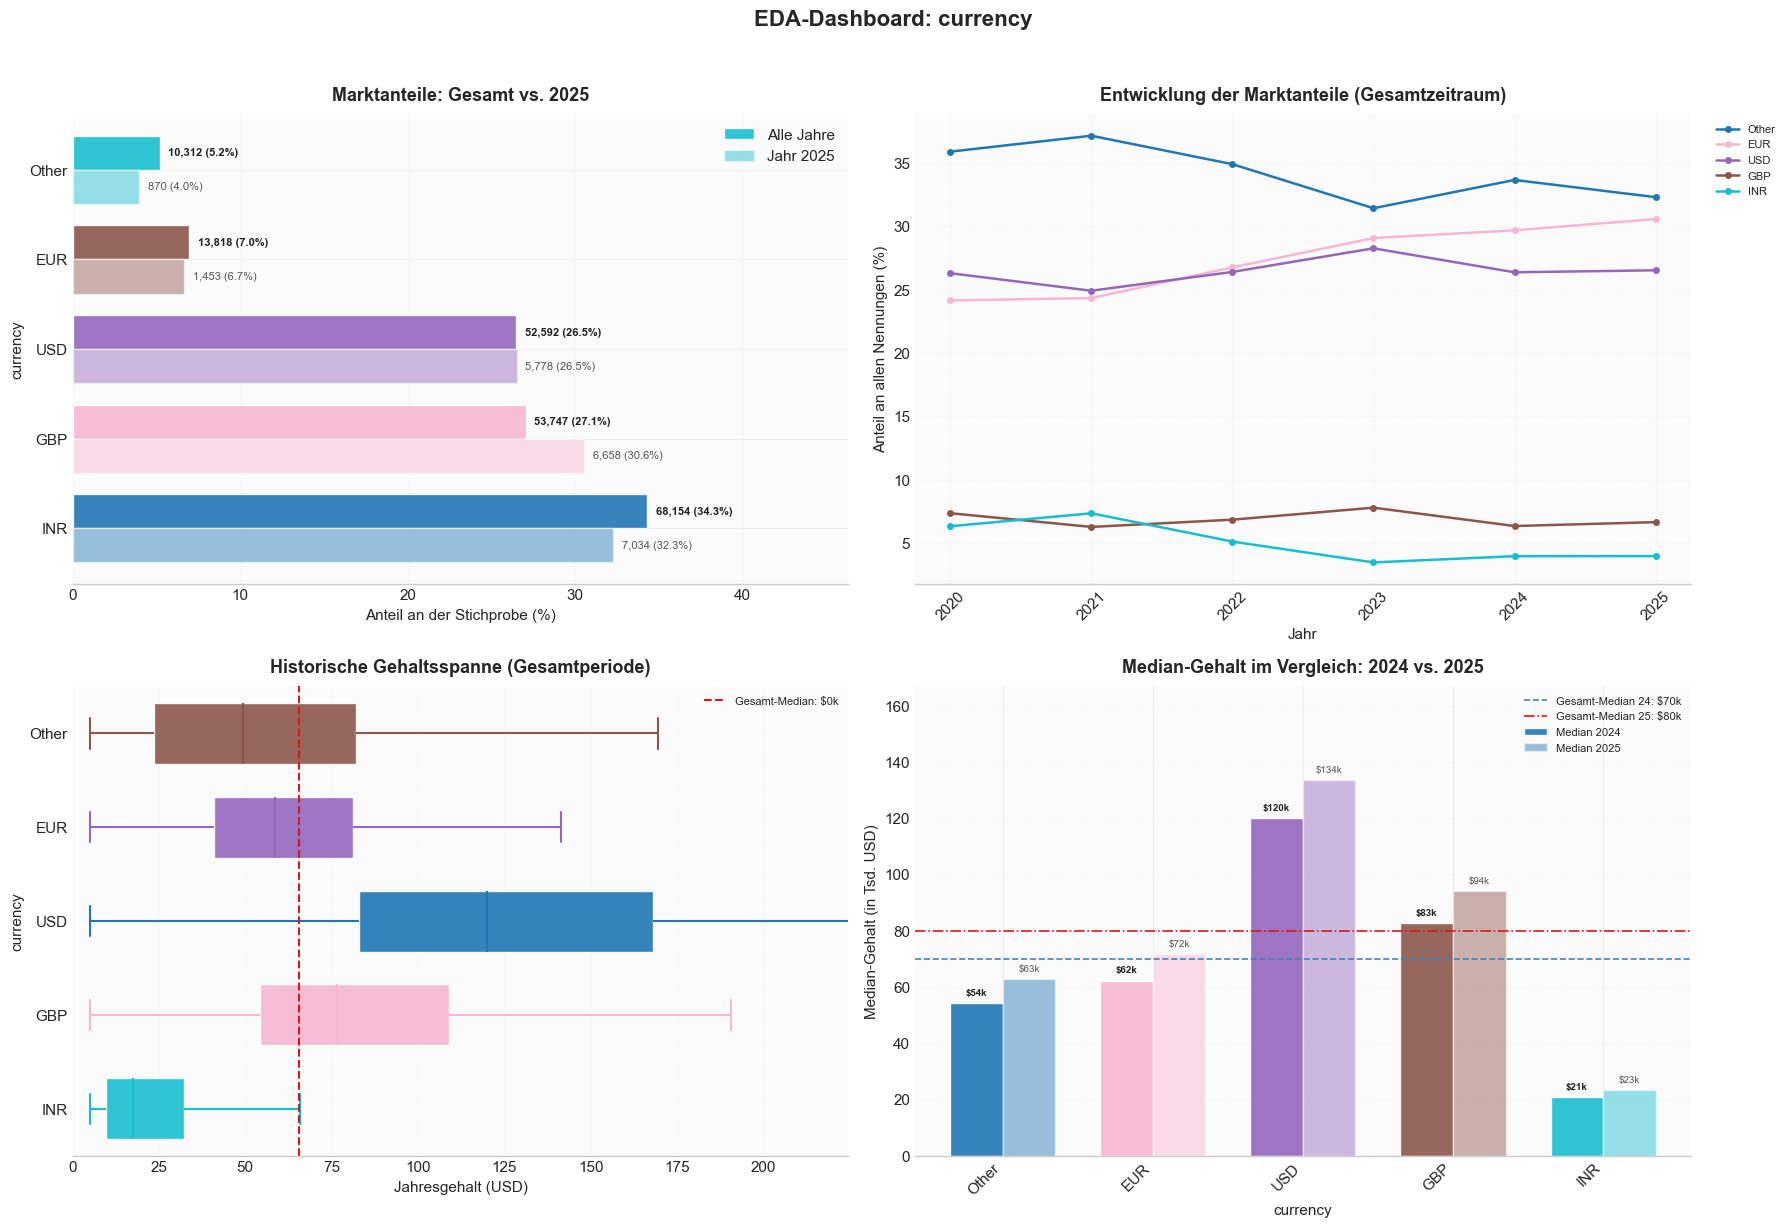

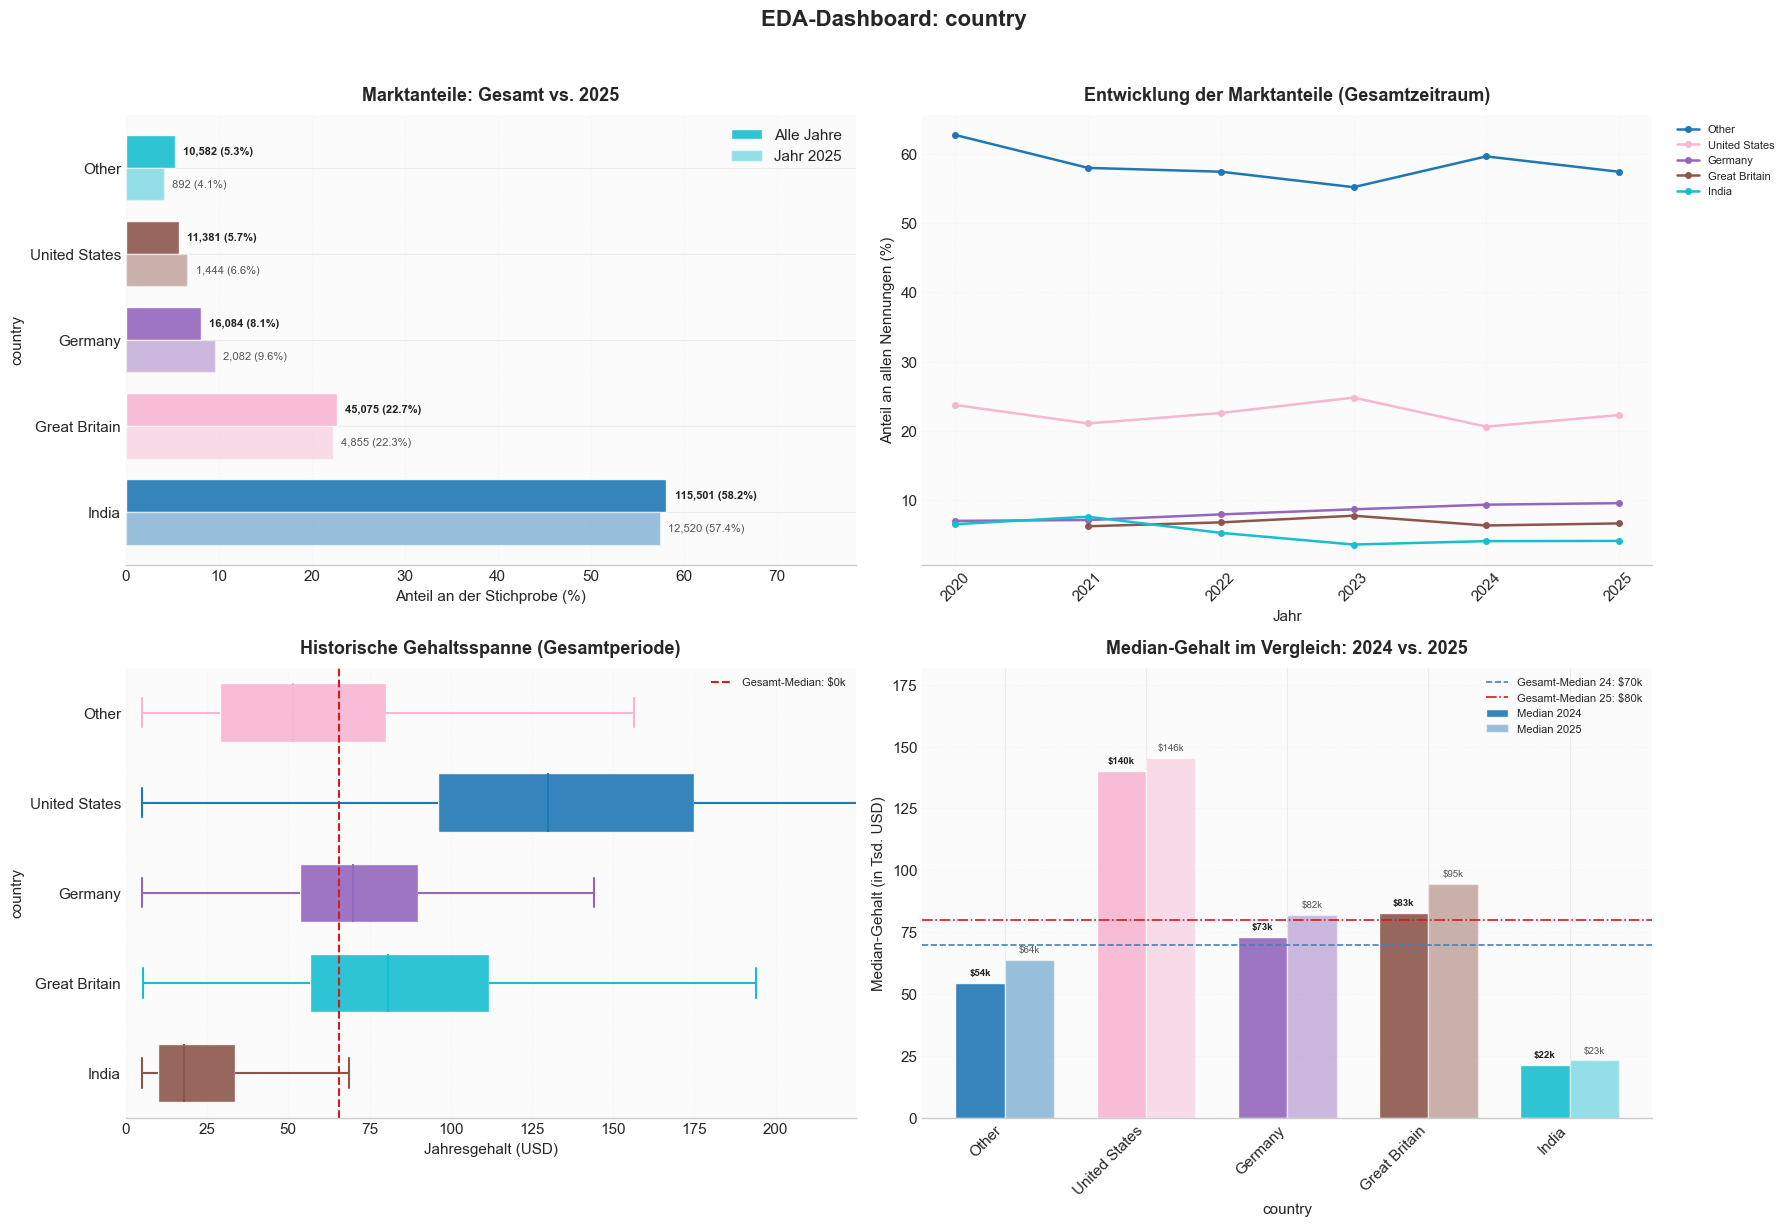

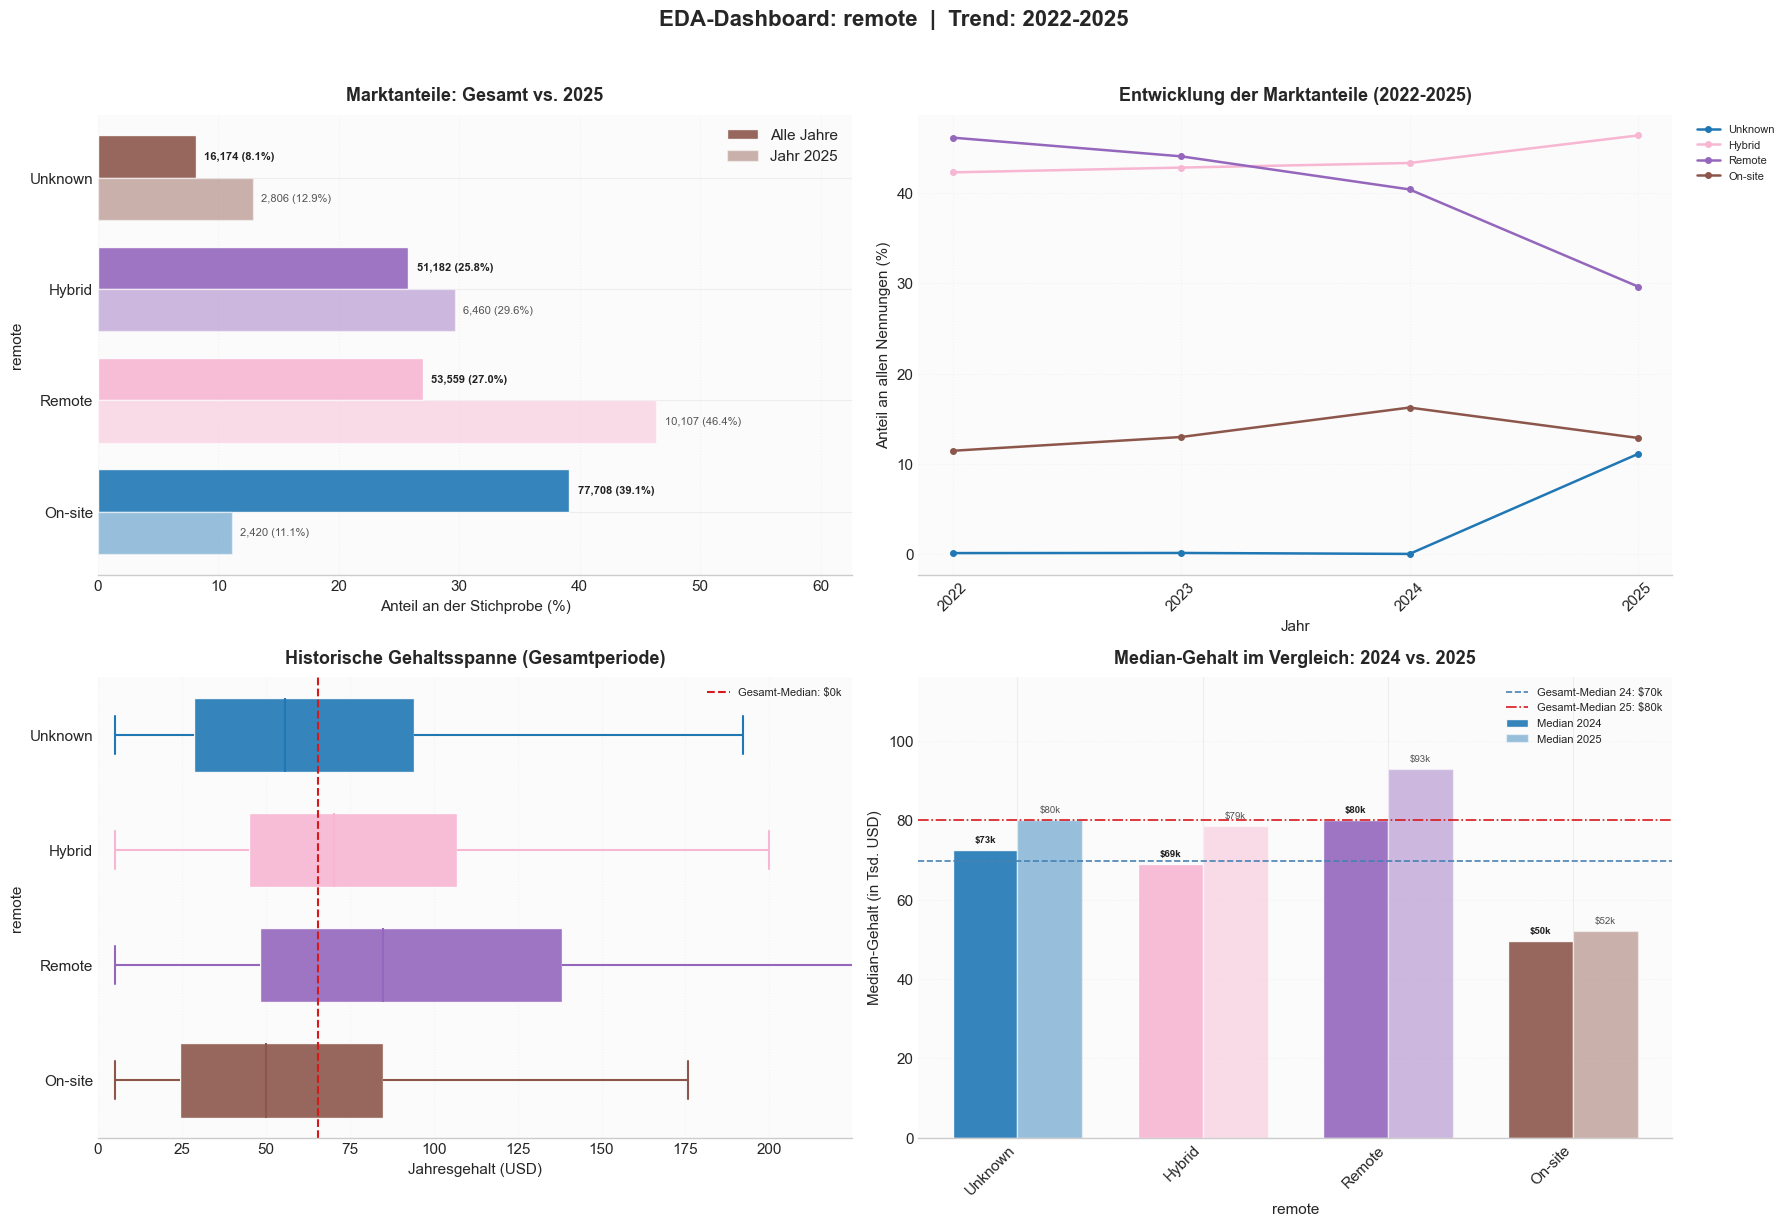

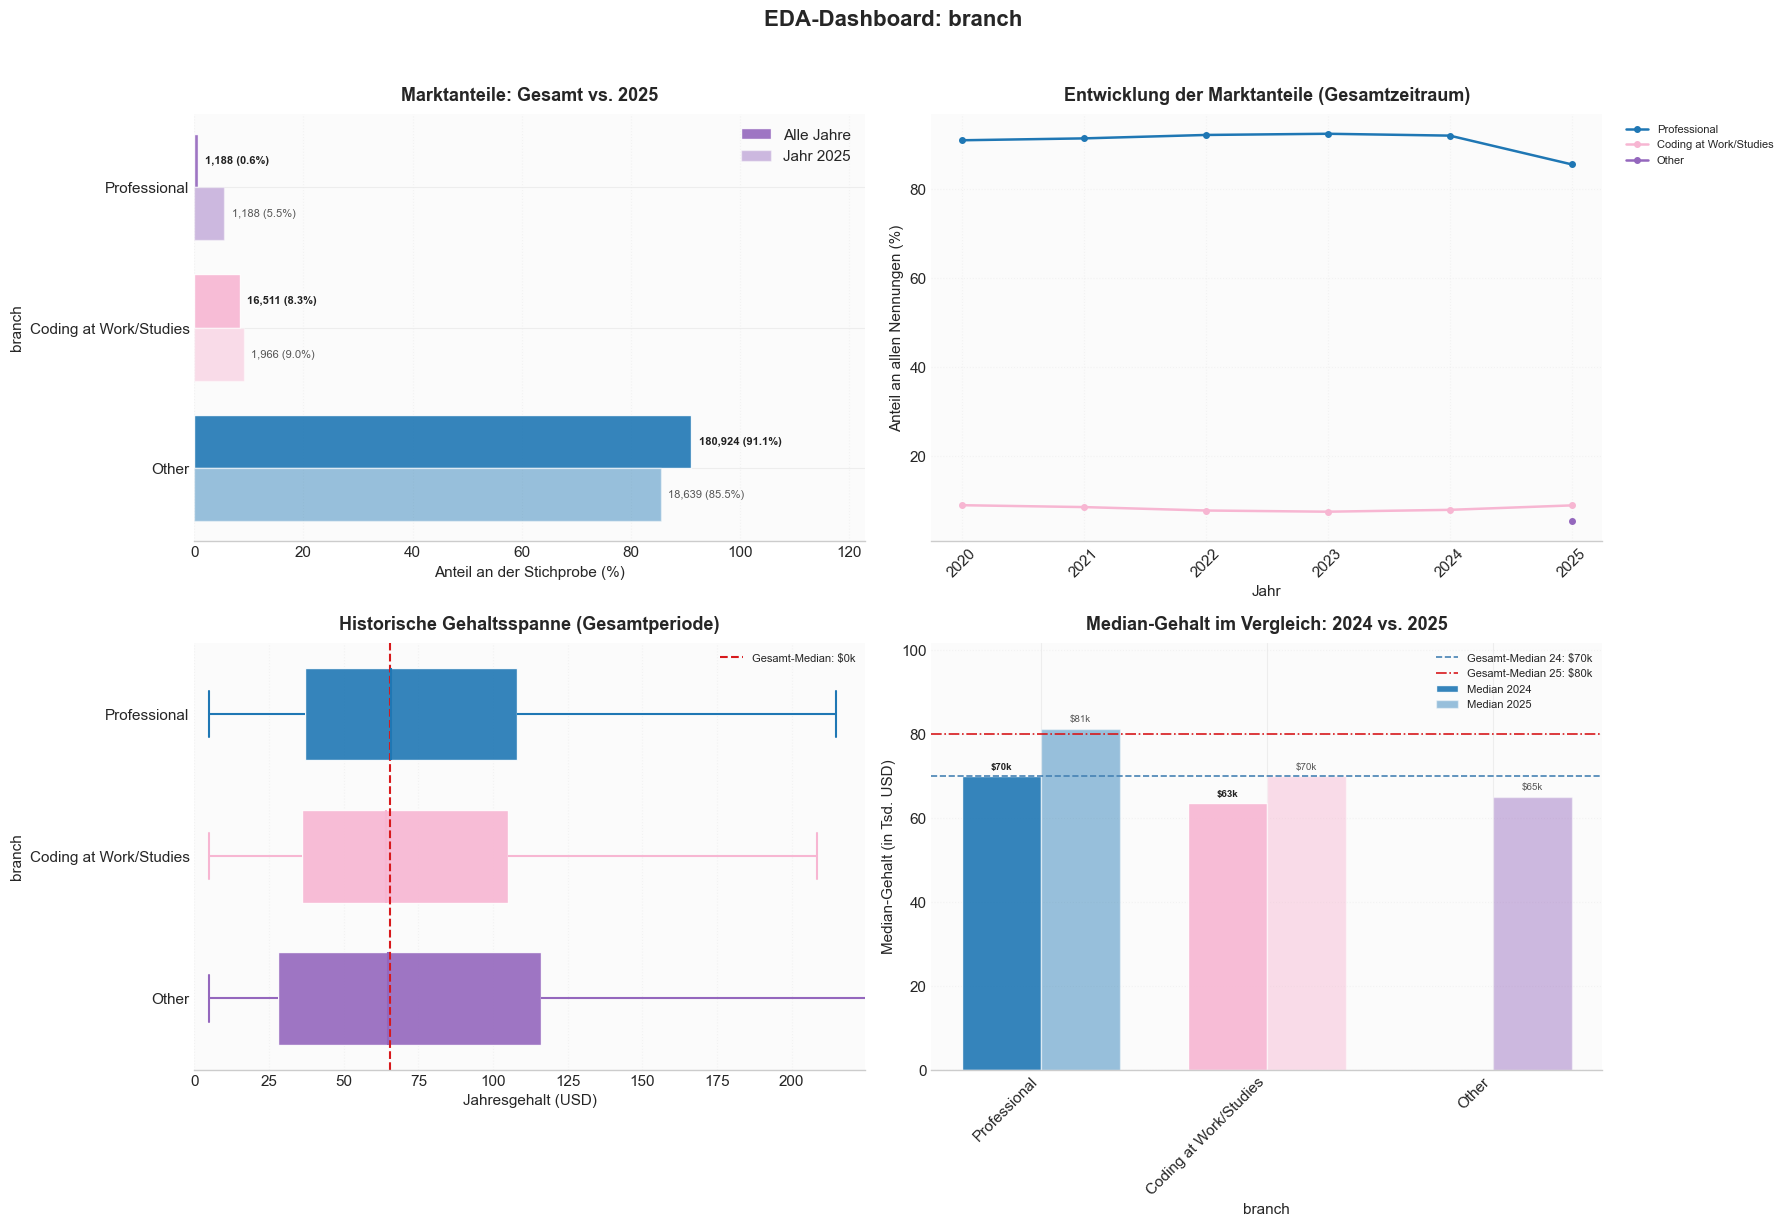

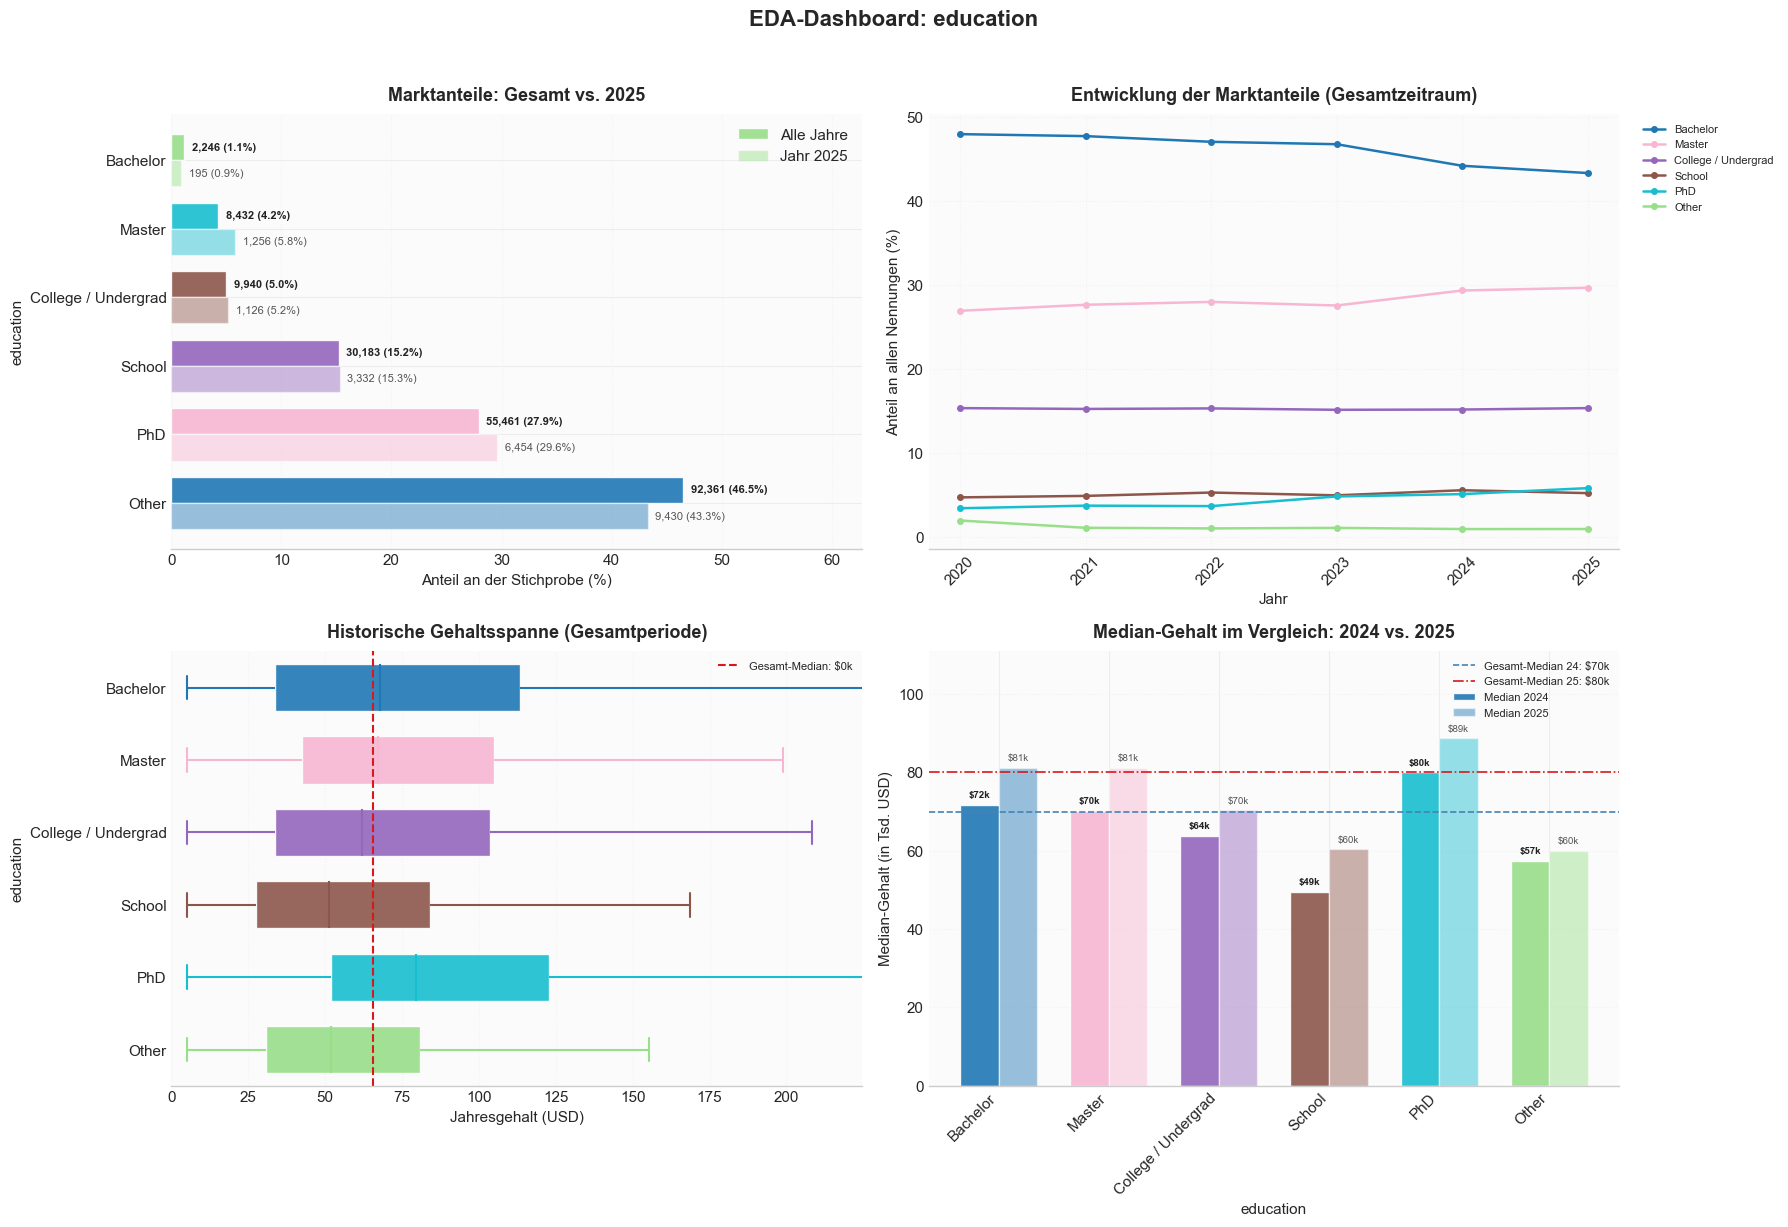

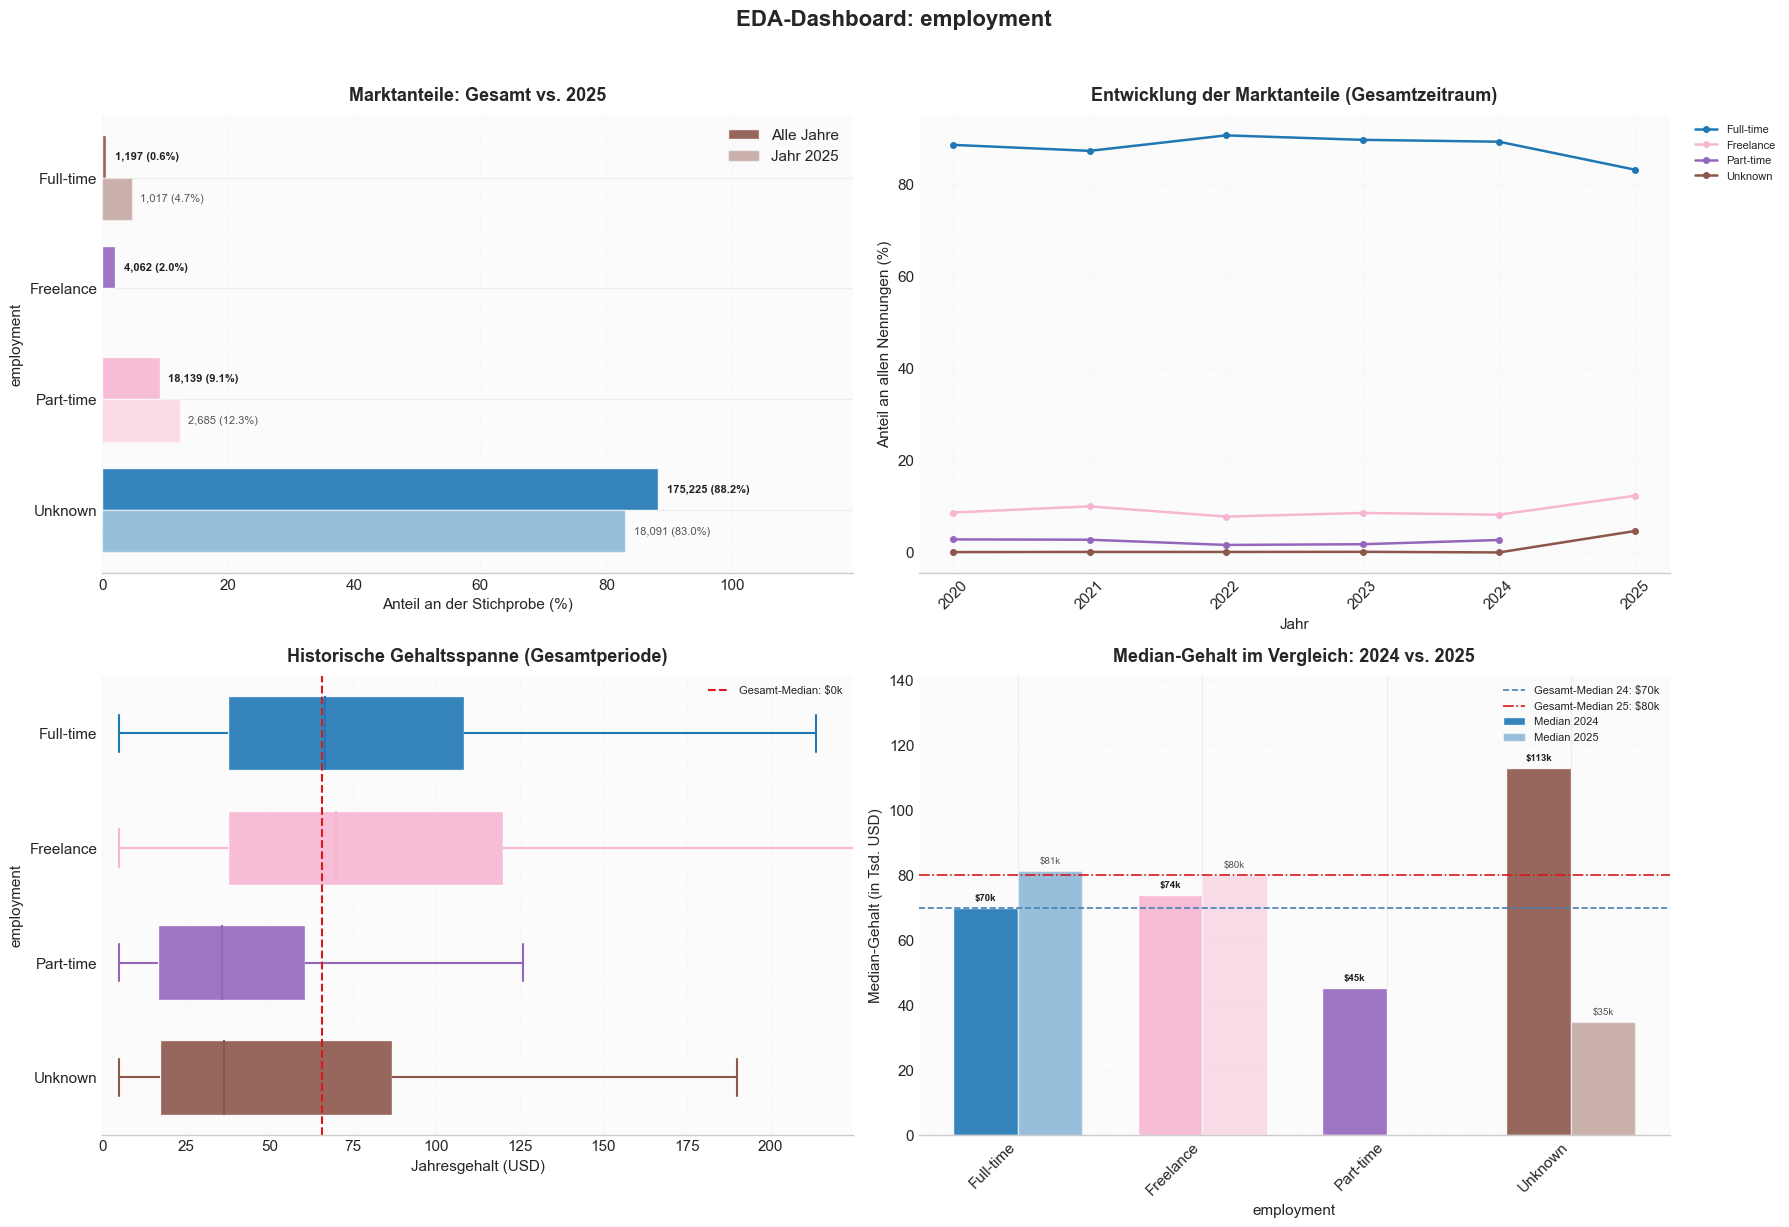

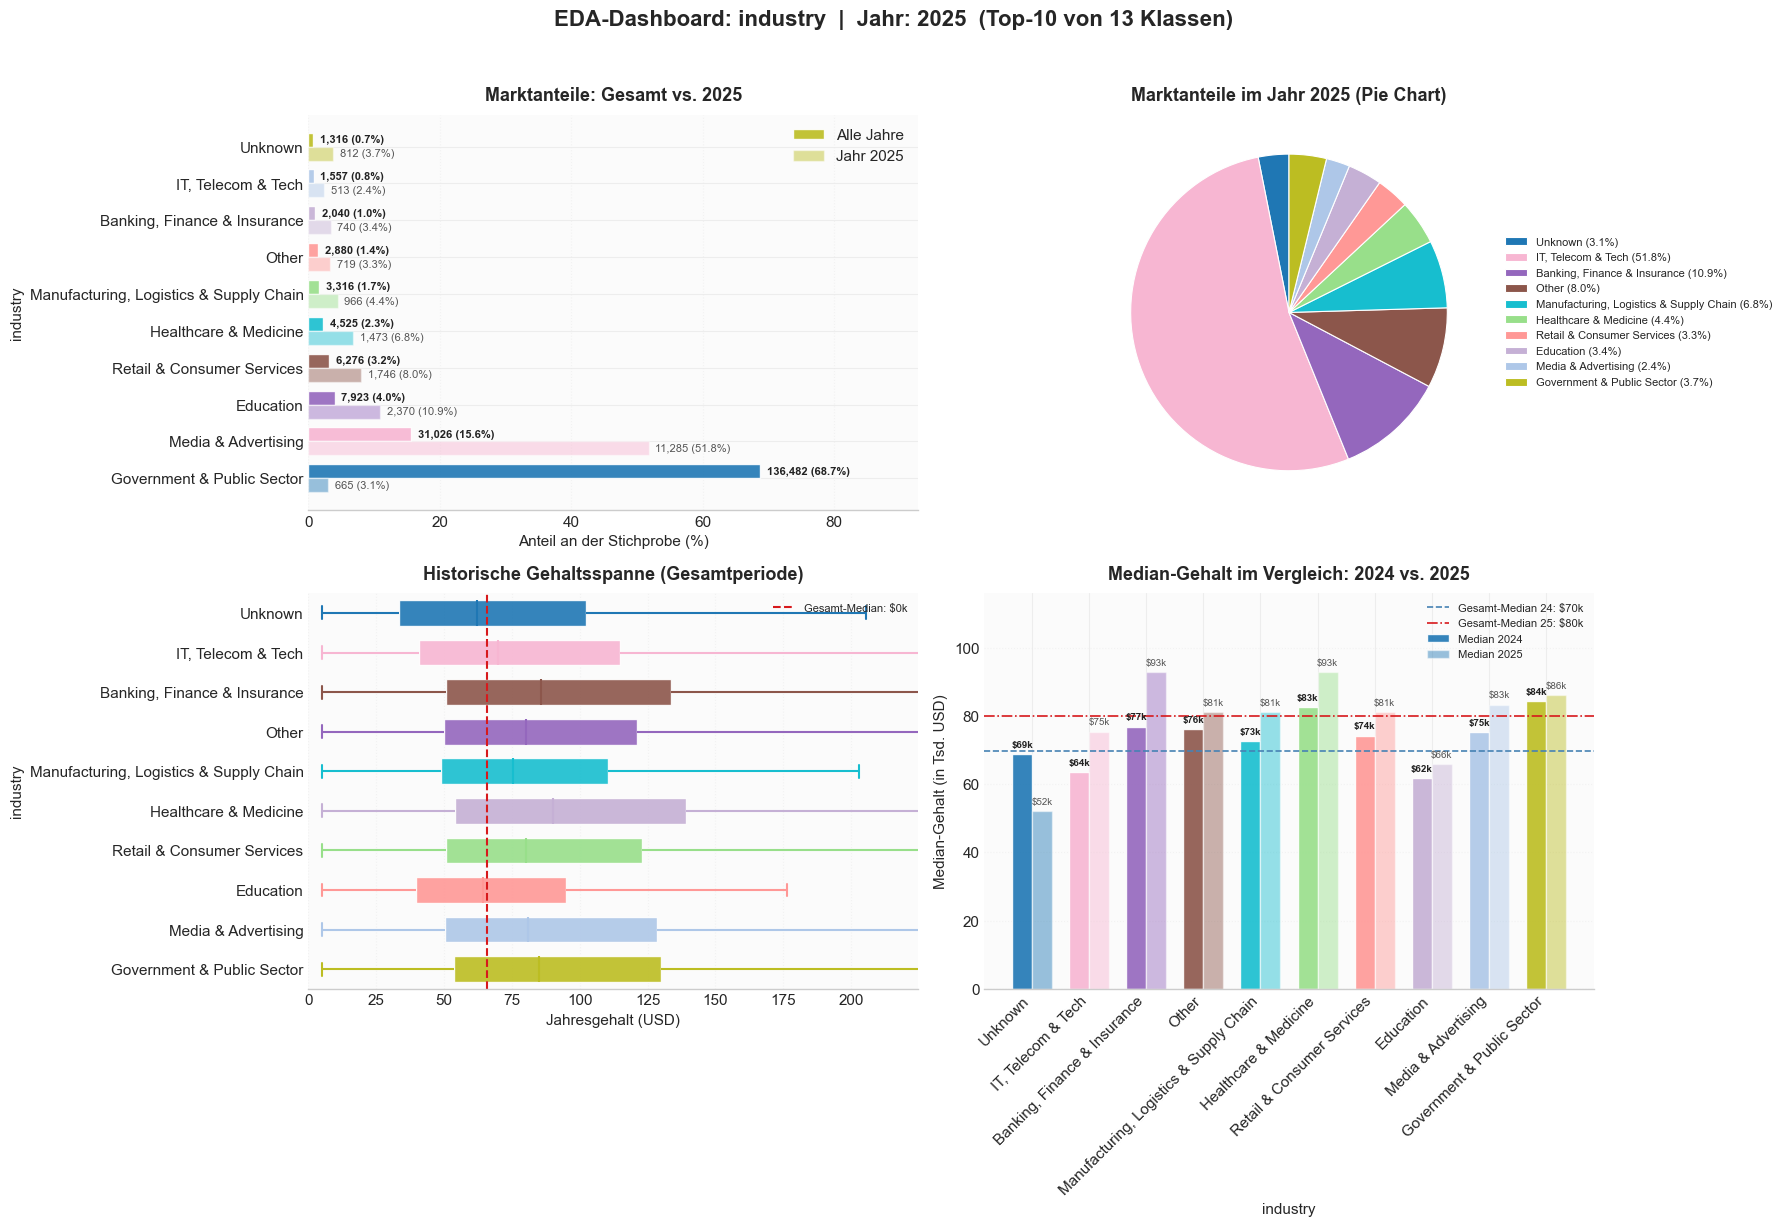

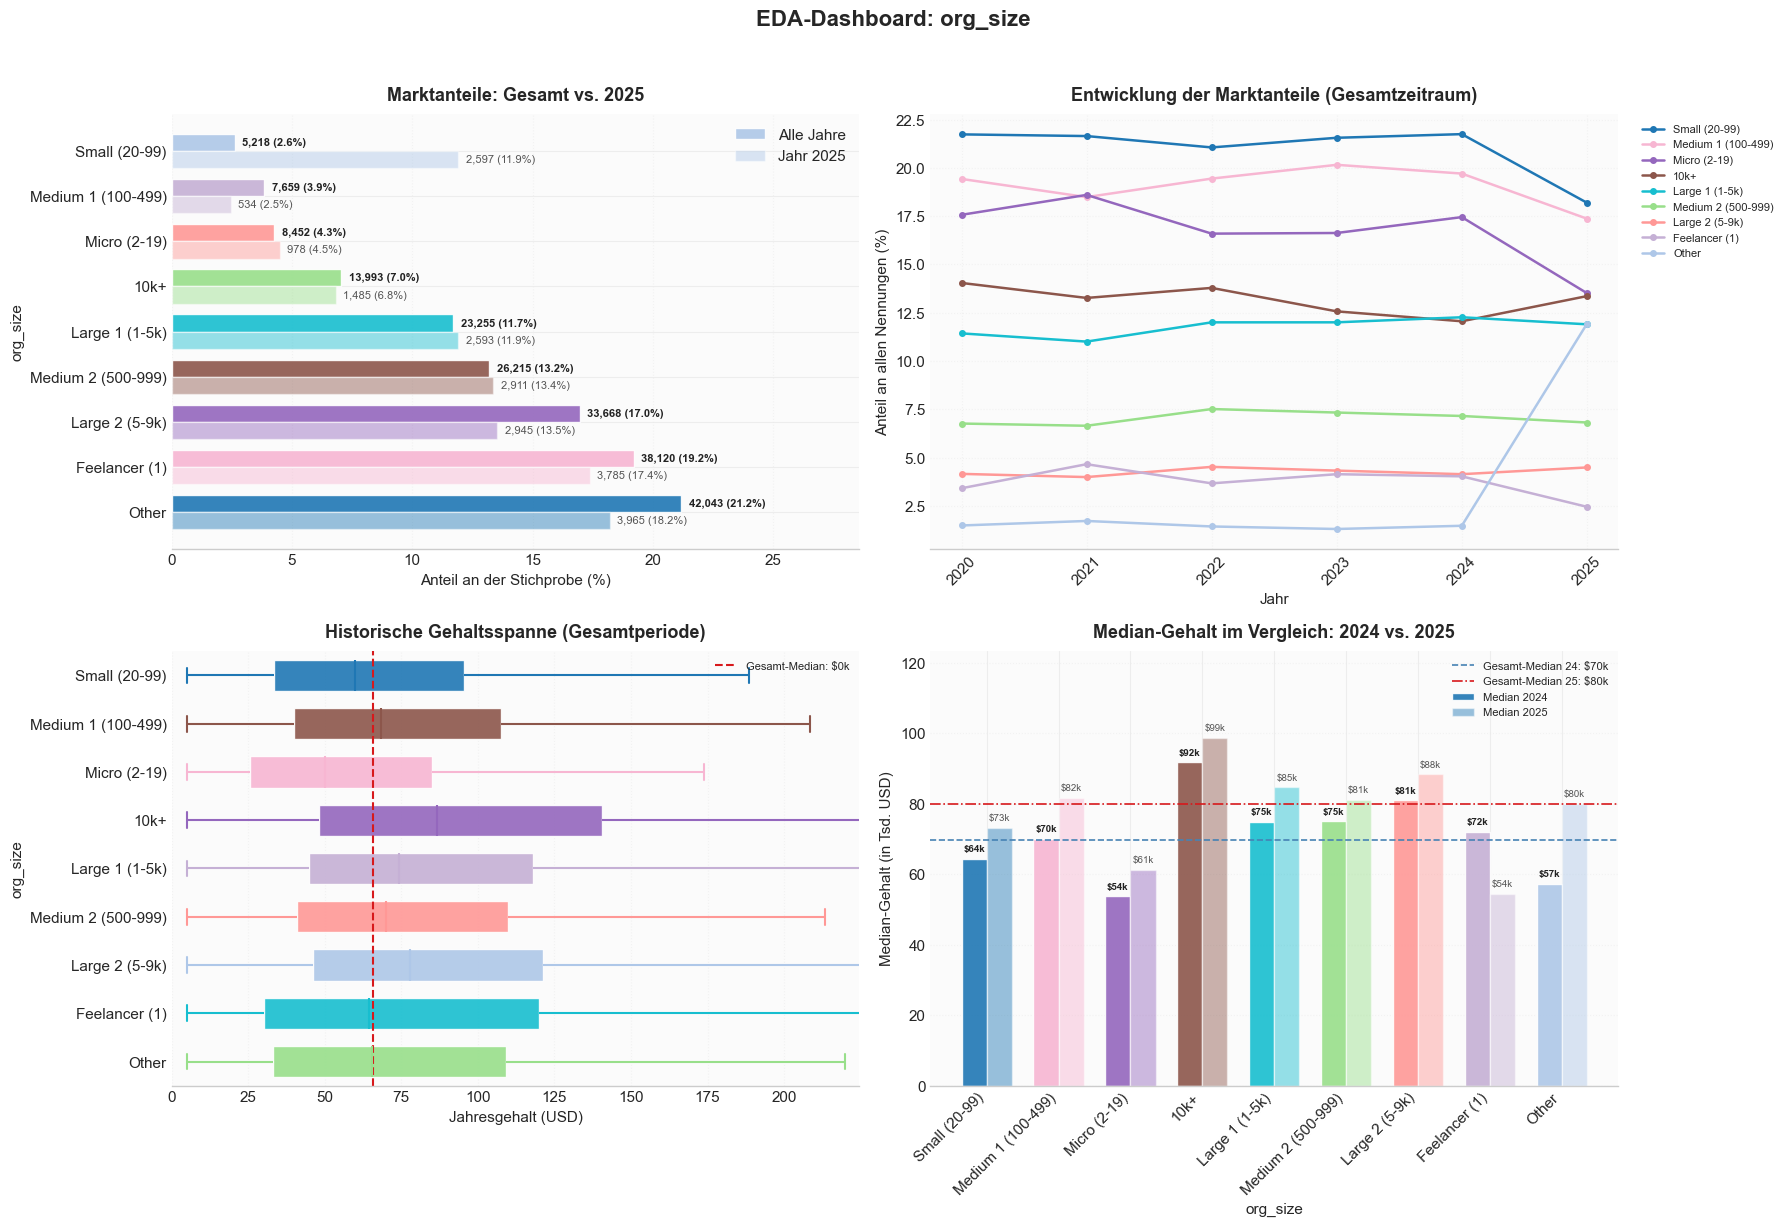

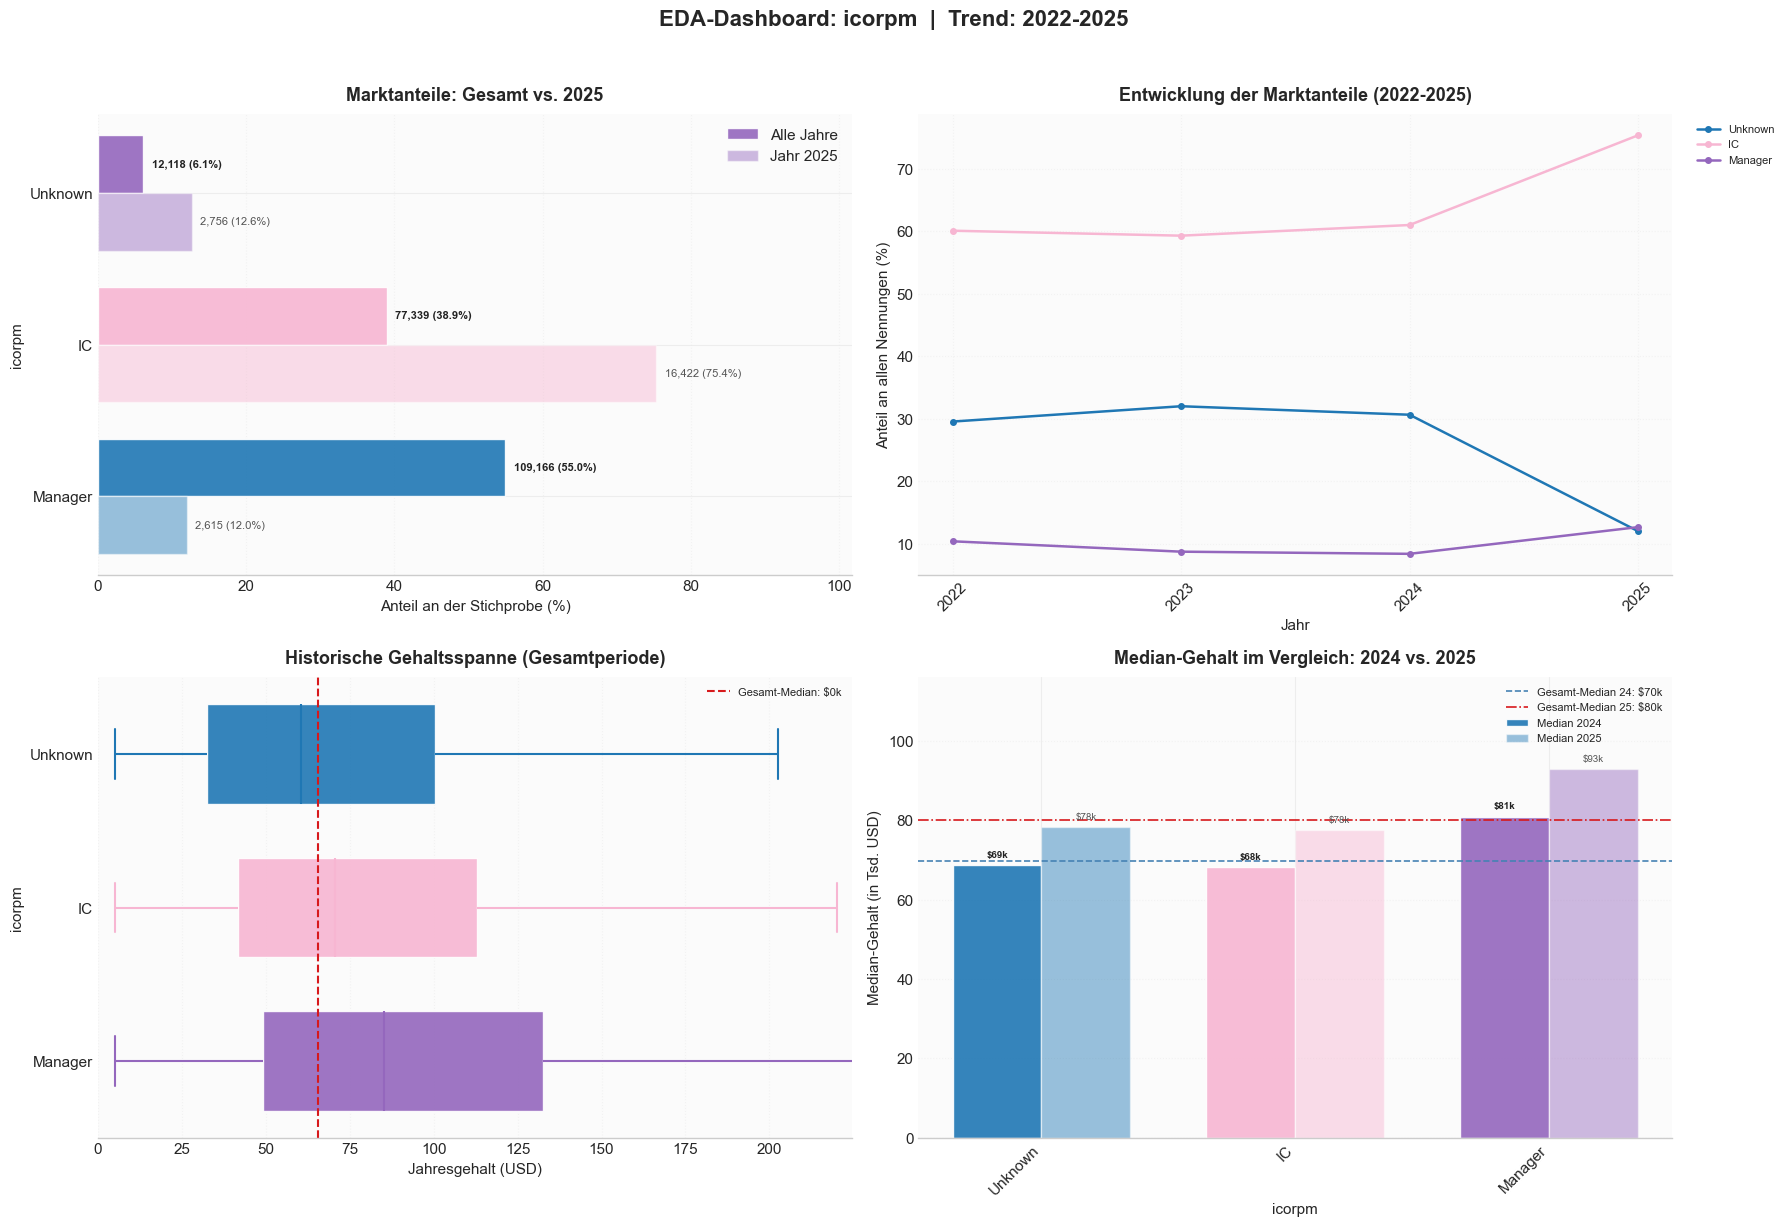

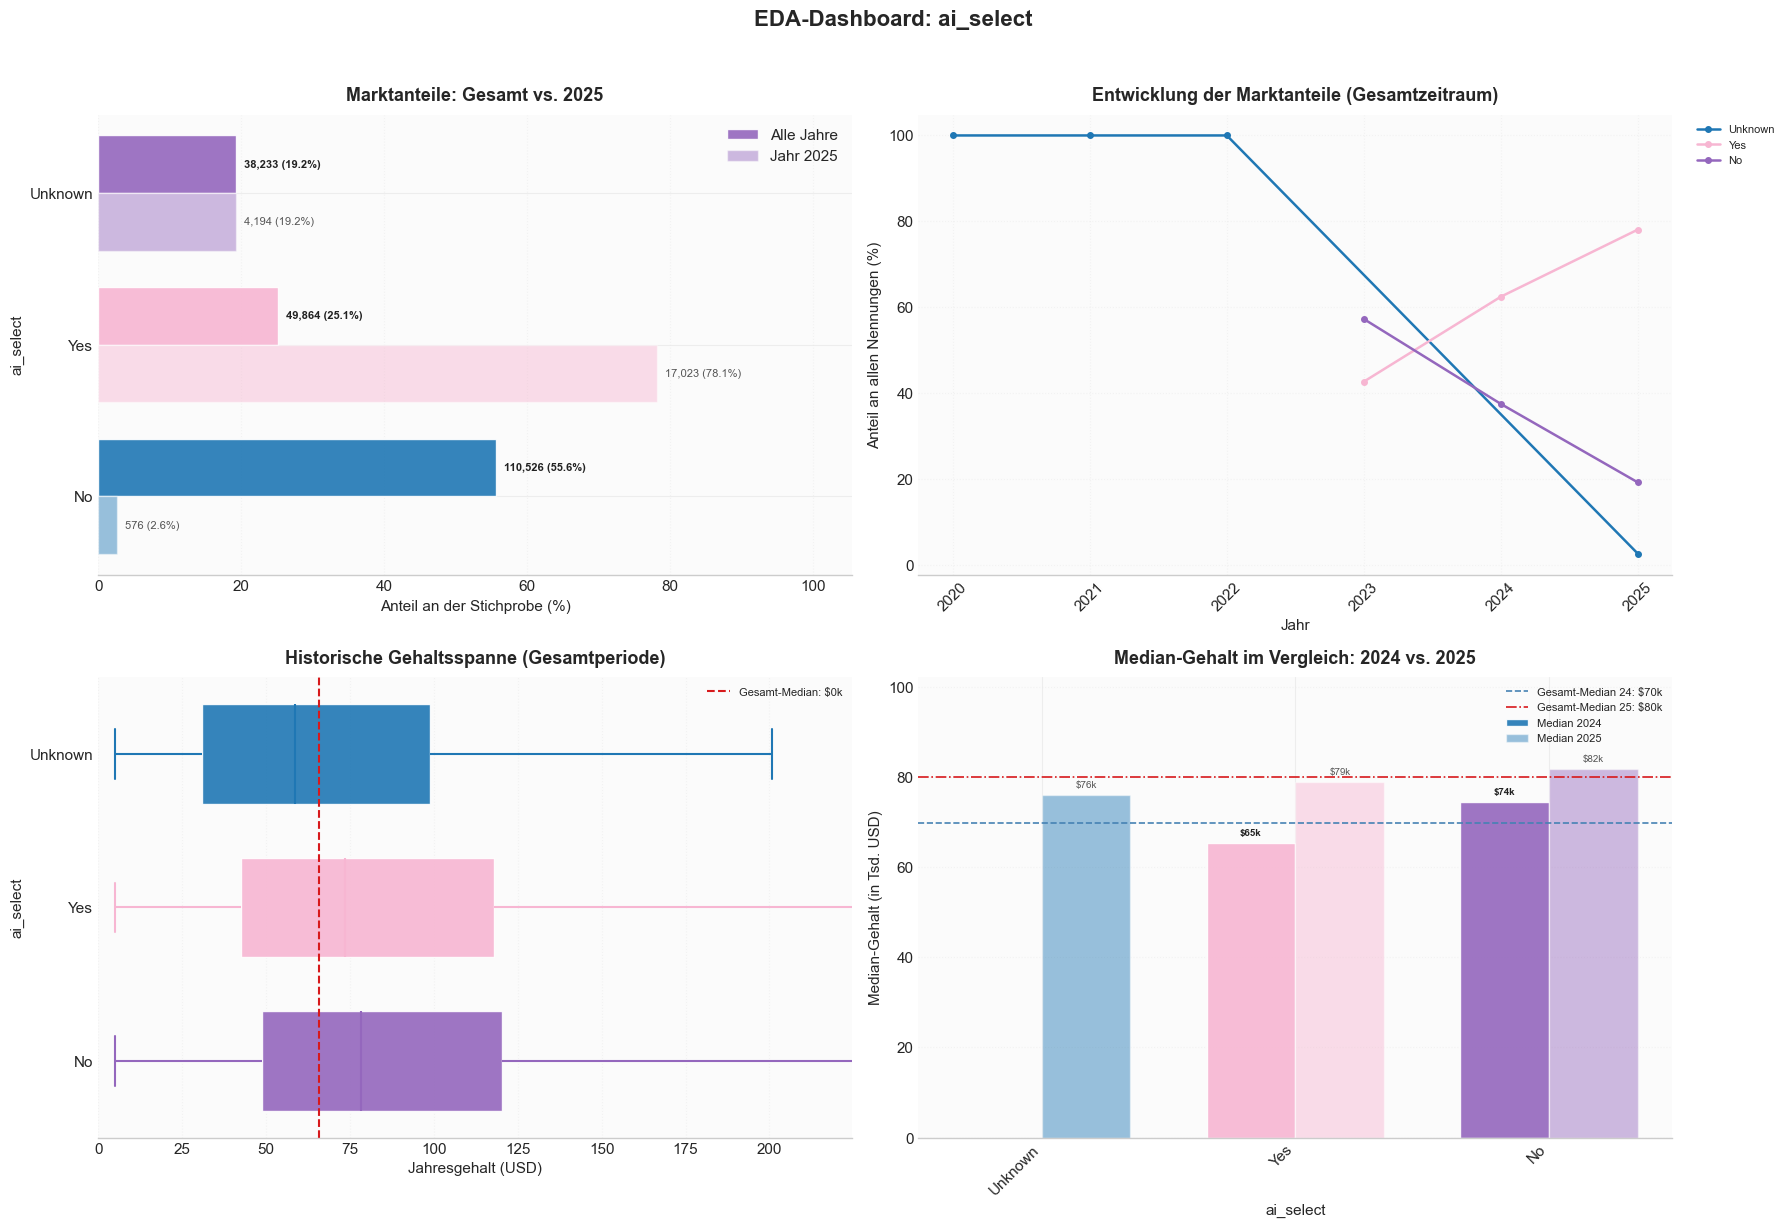

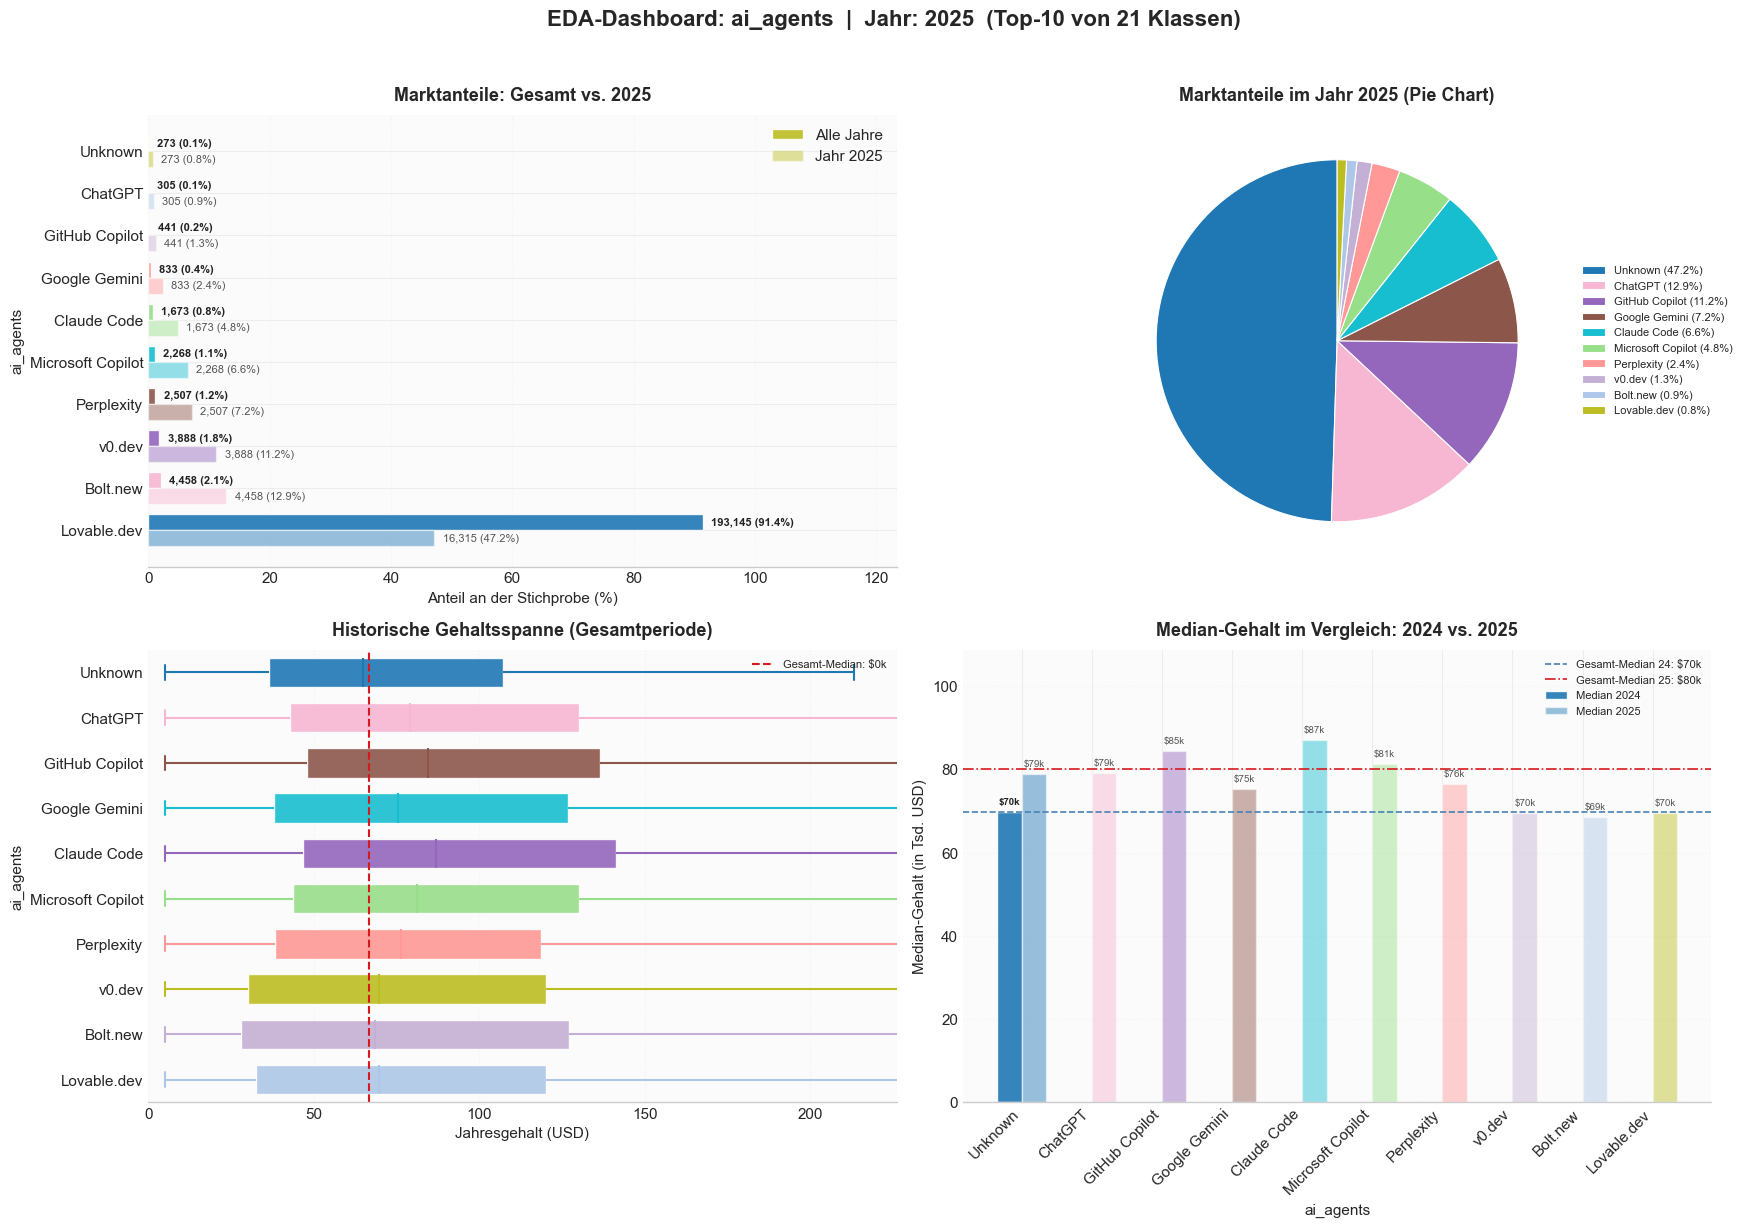

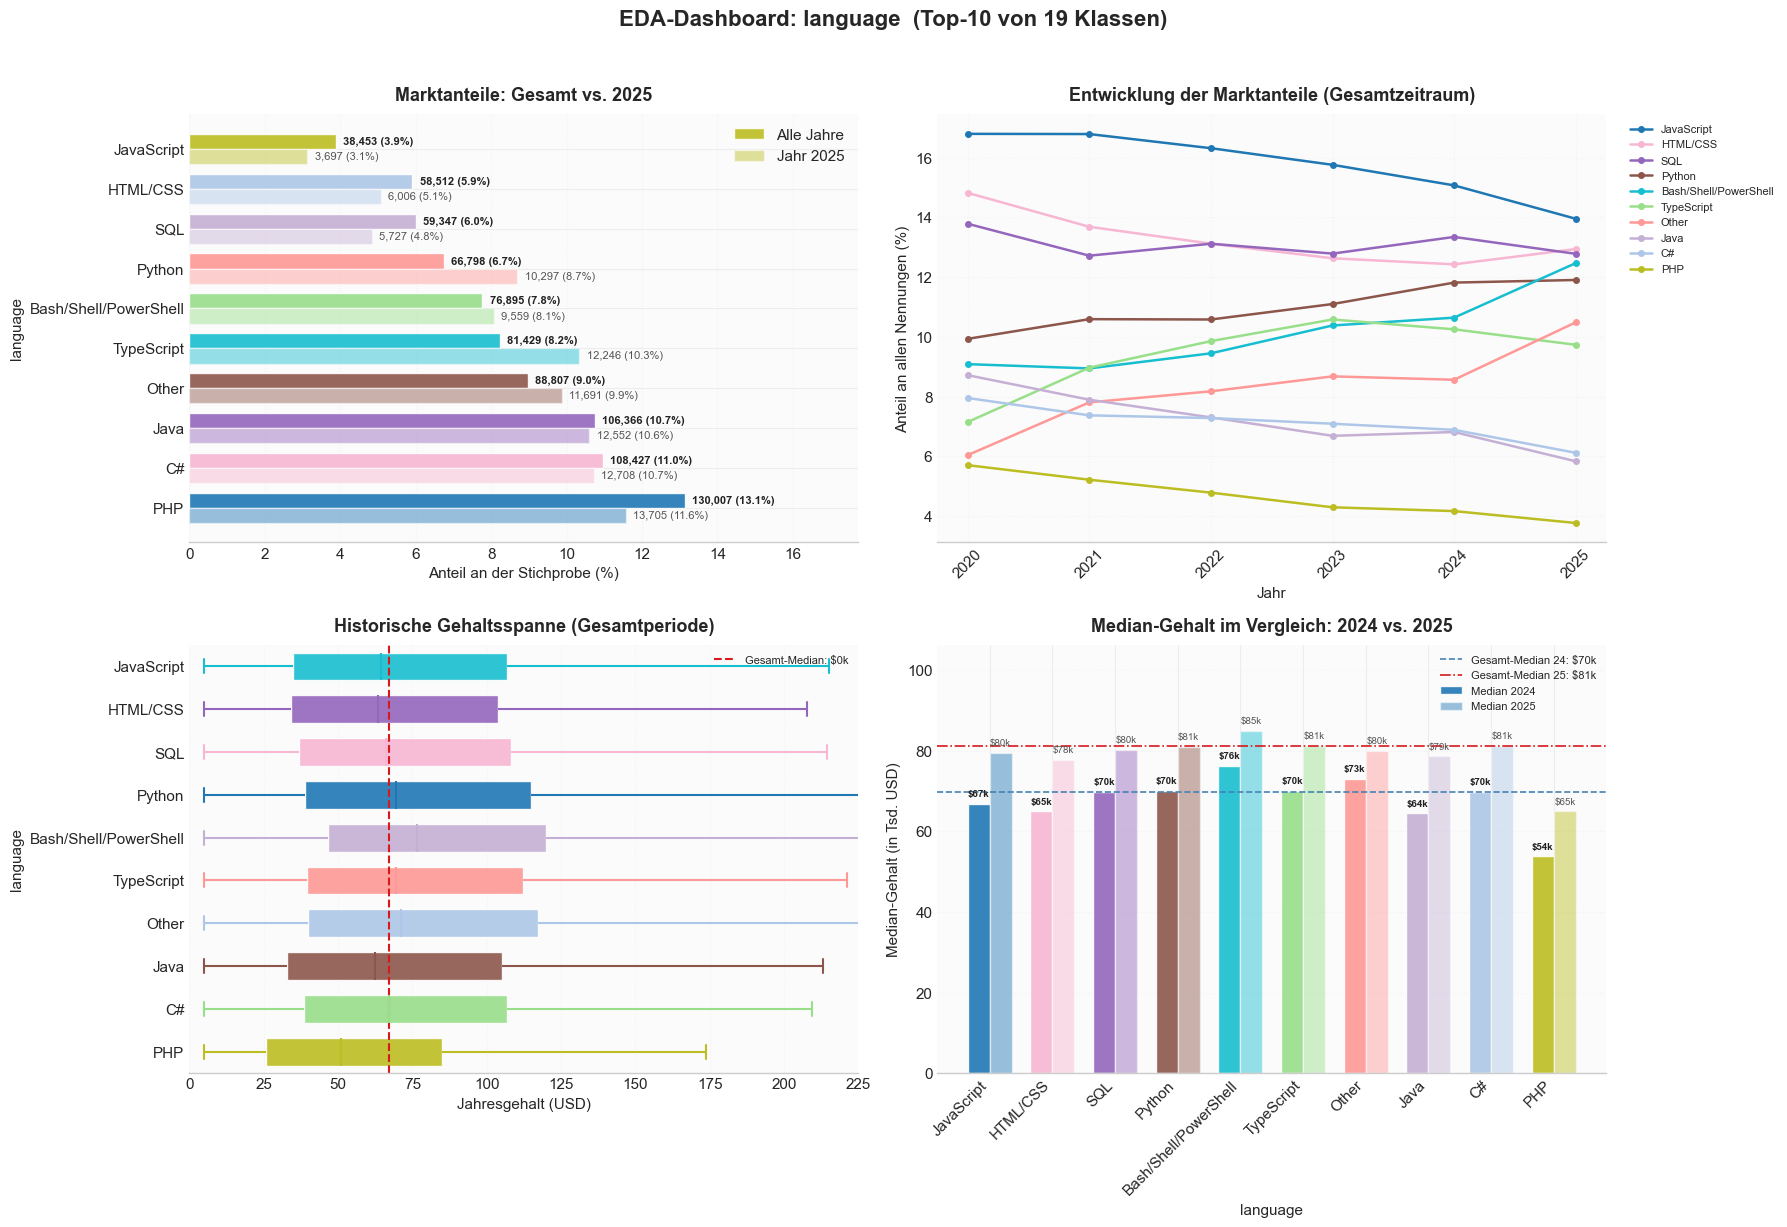

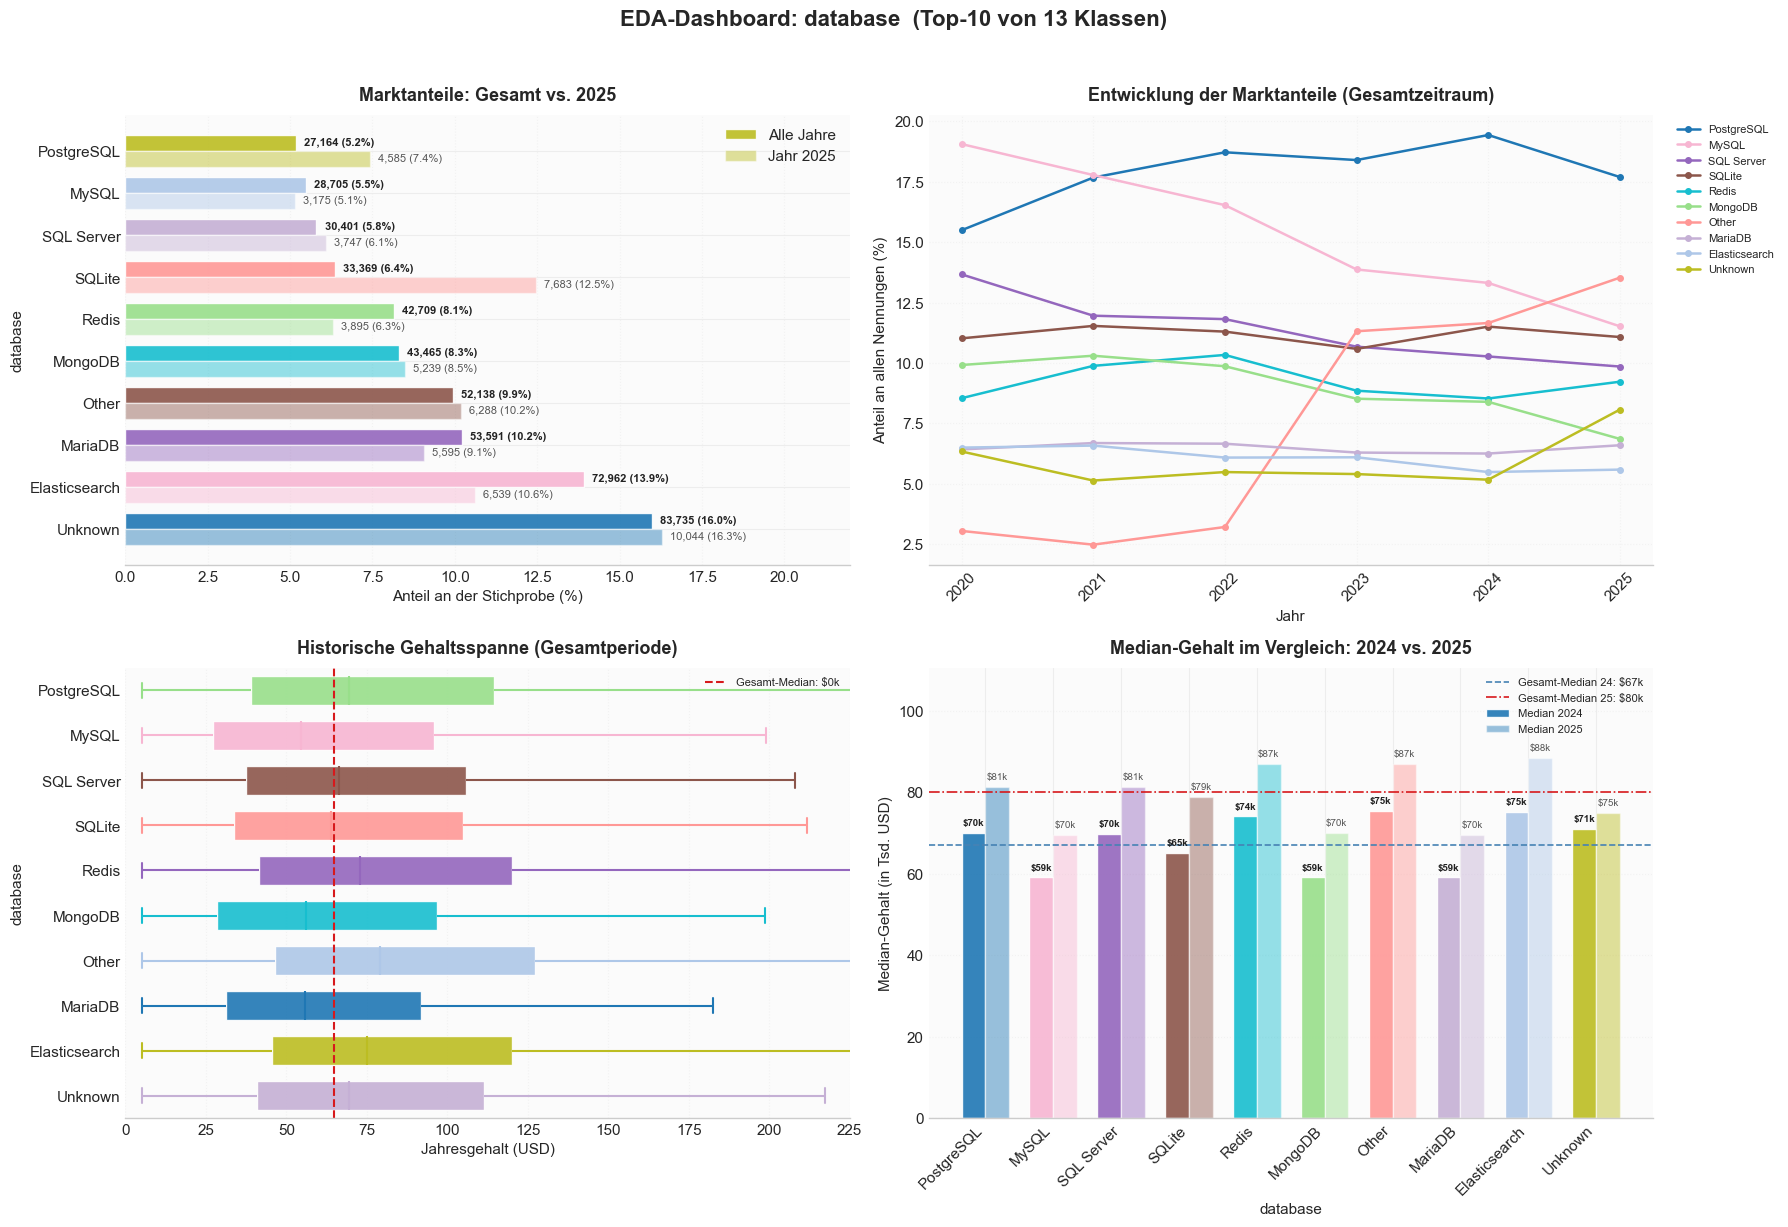

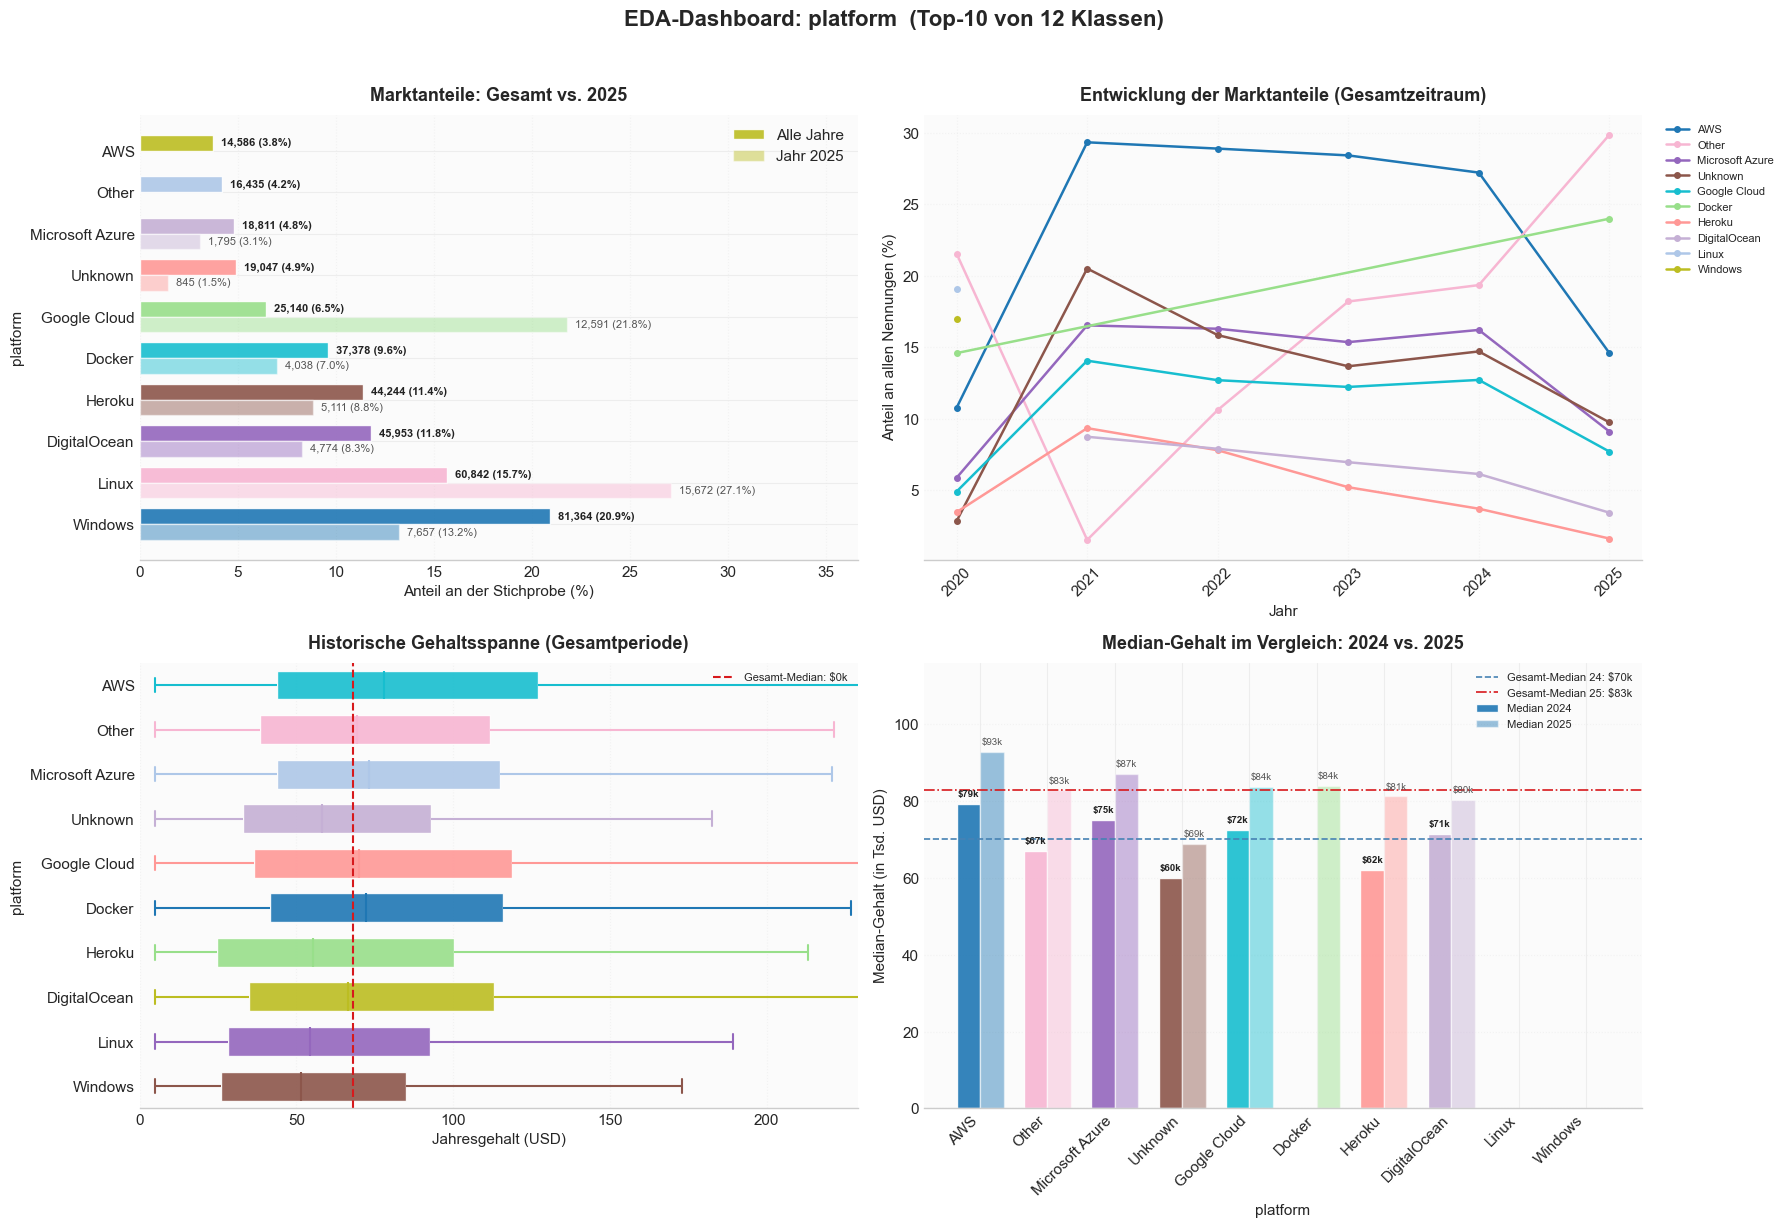

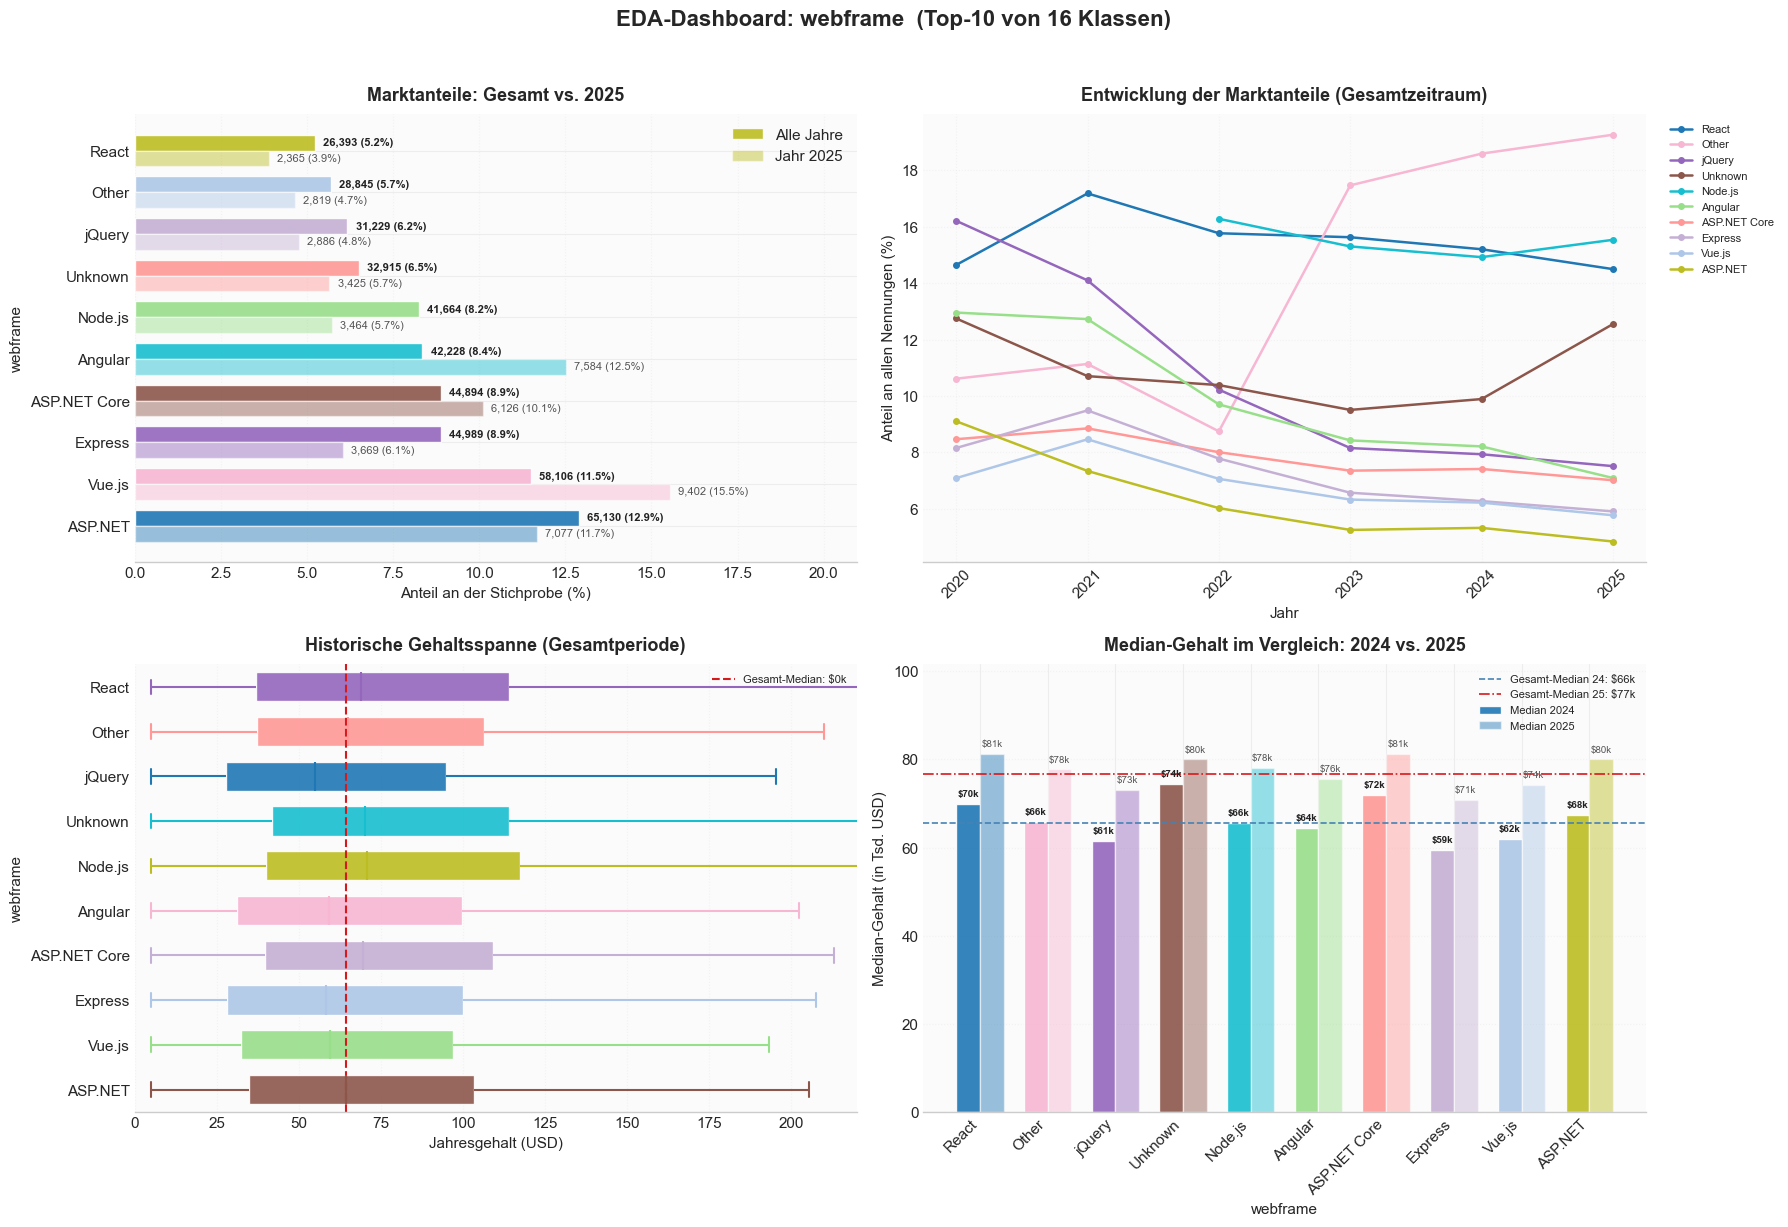

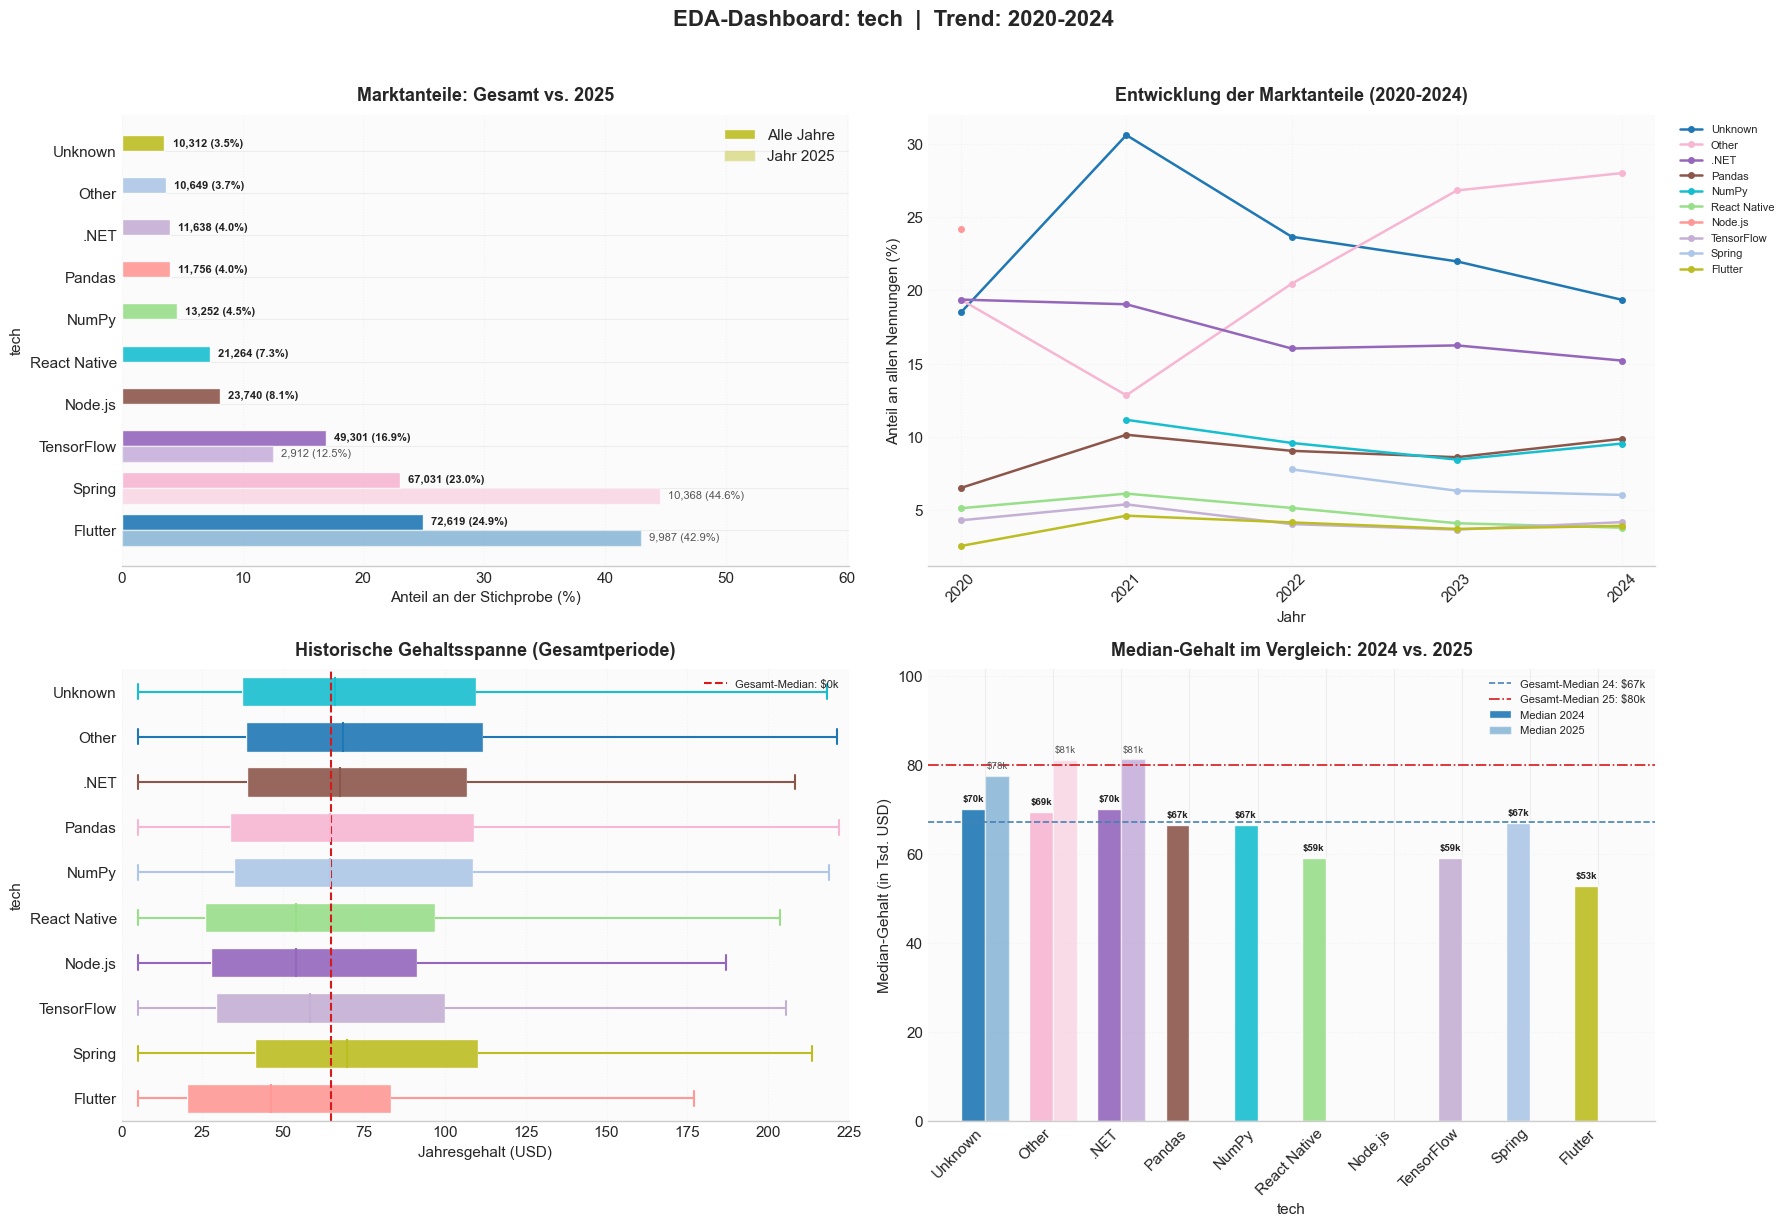

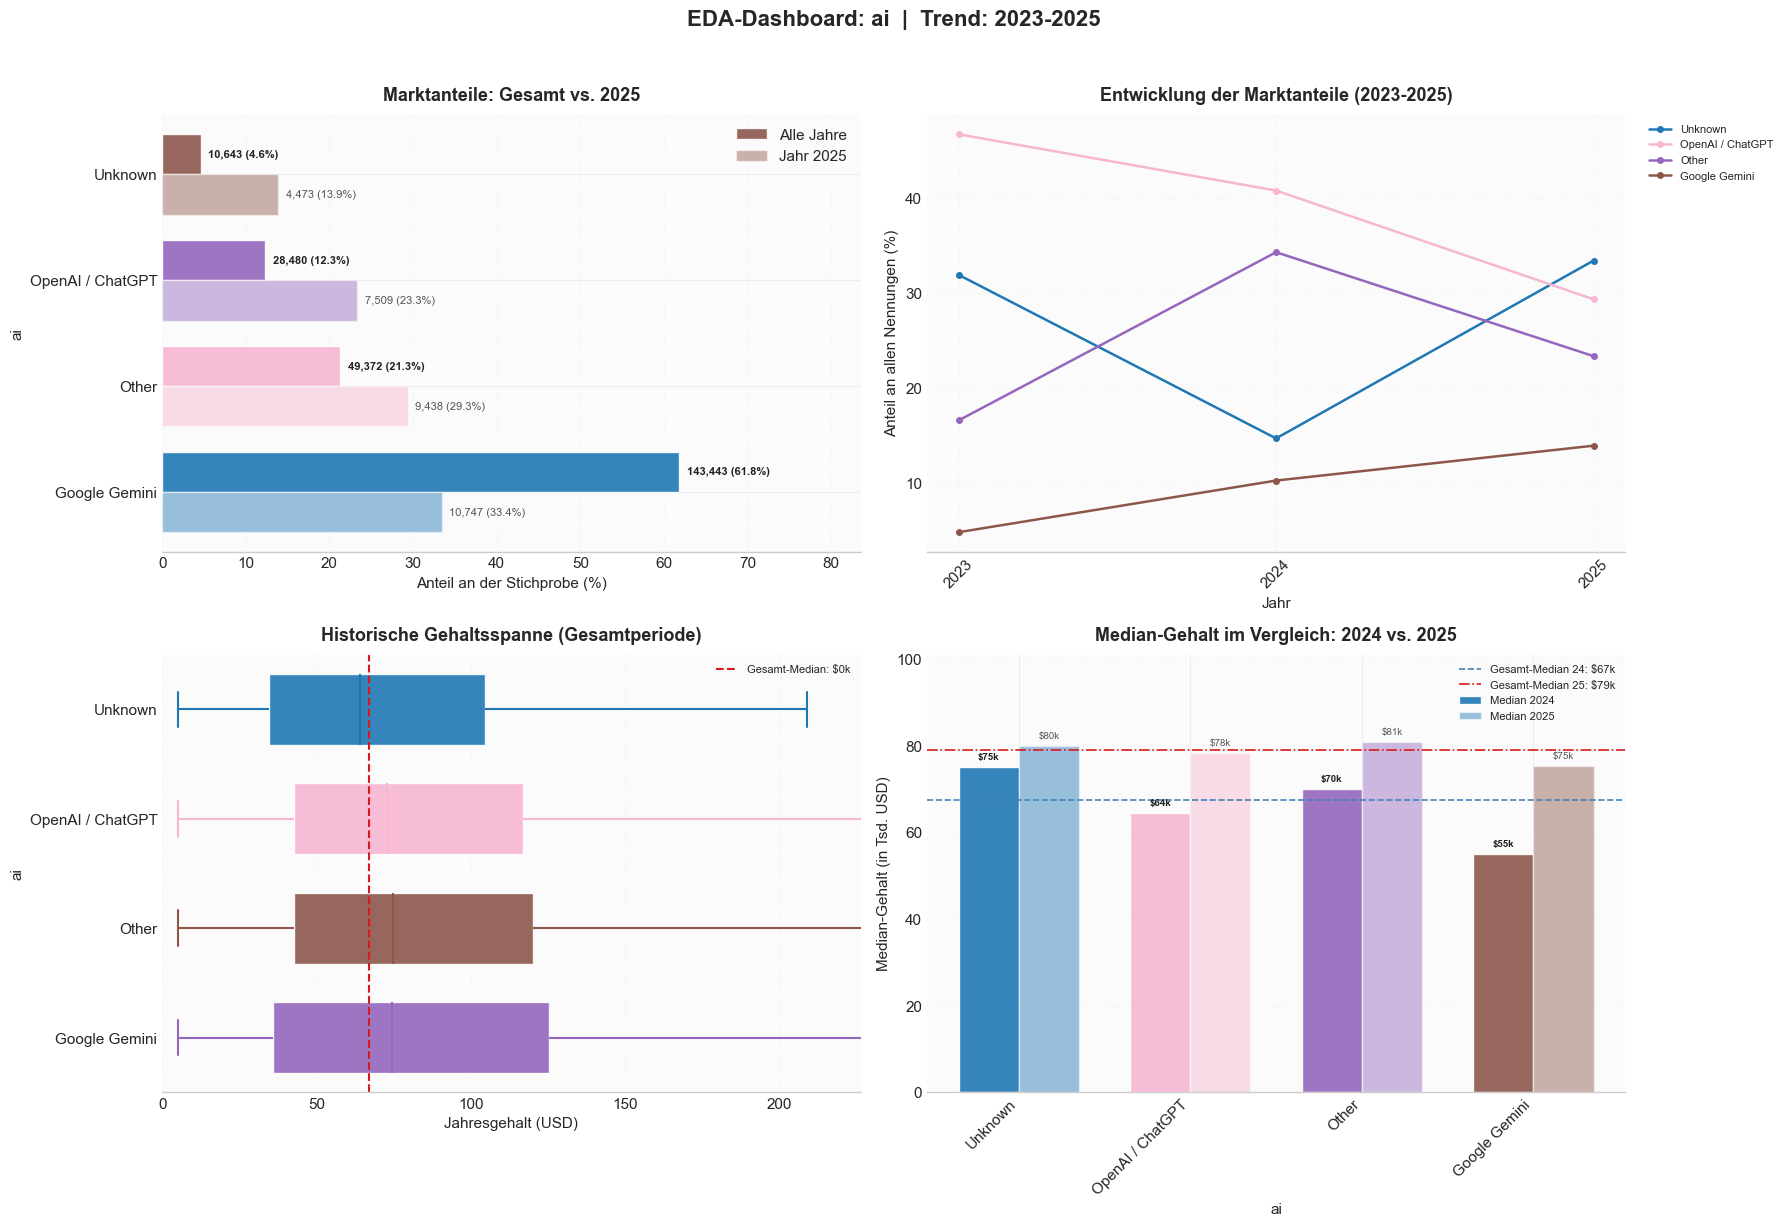

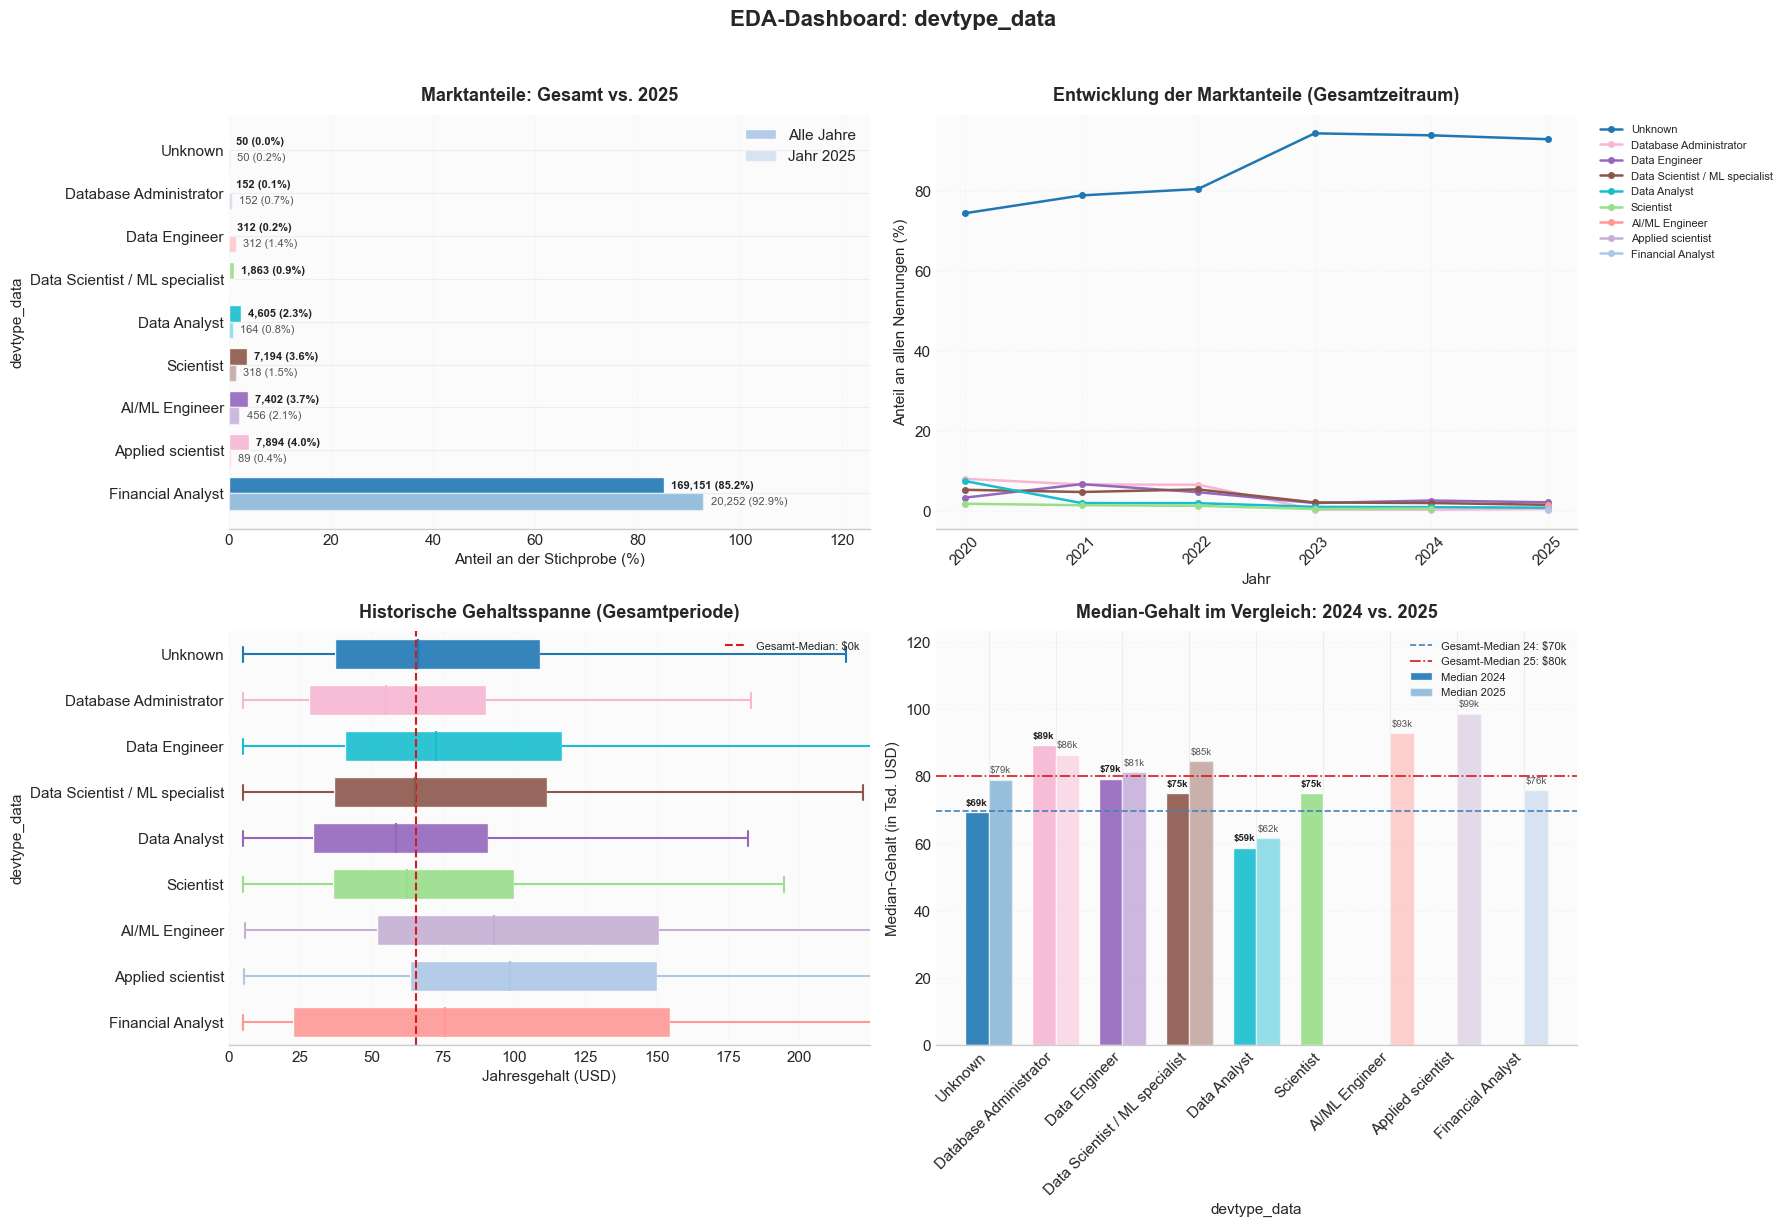

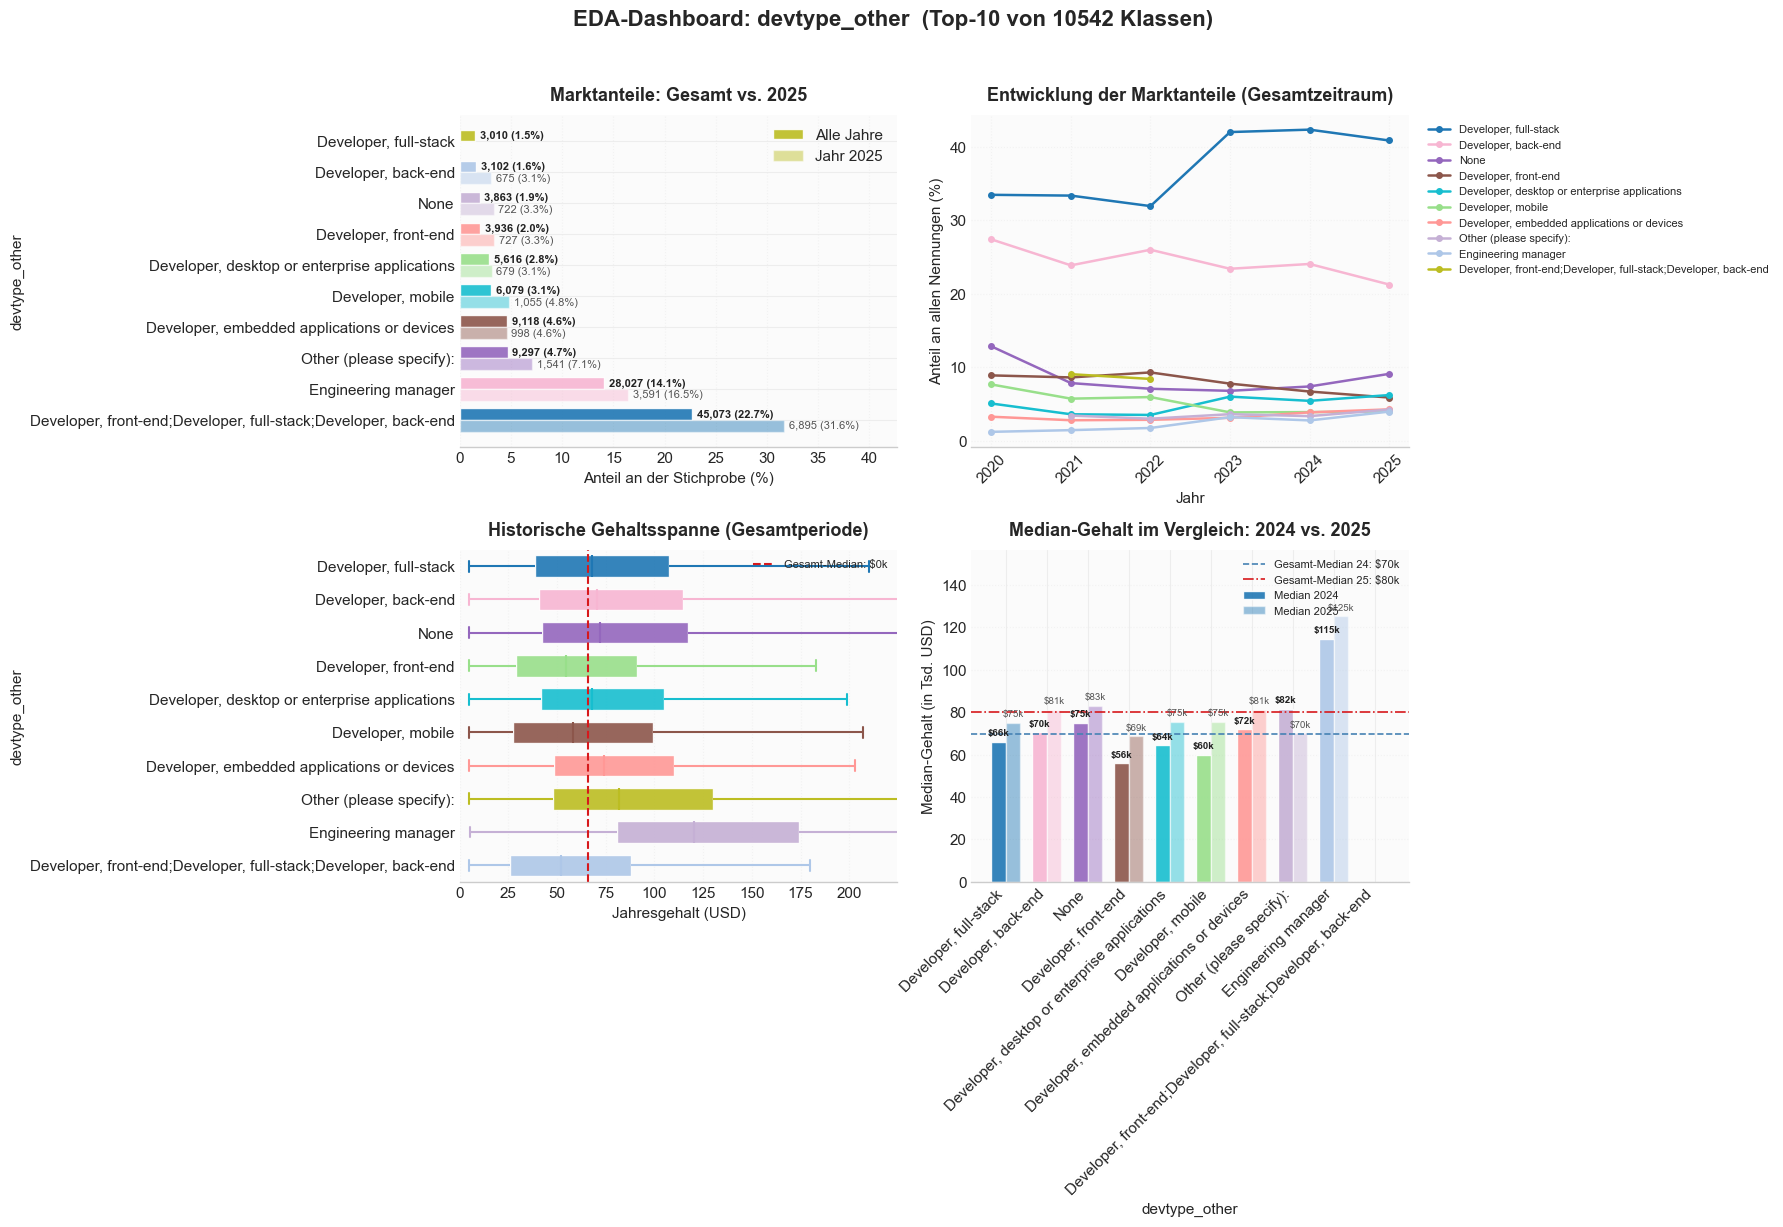

UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

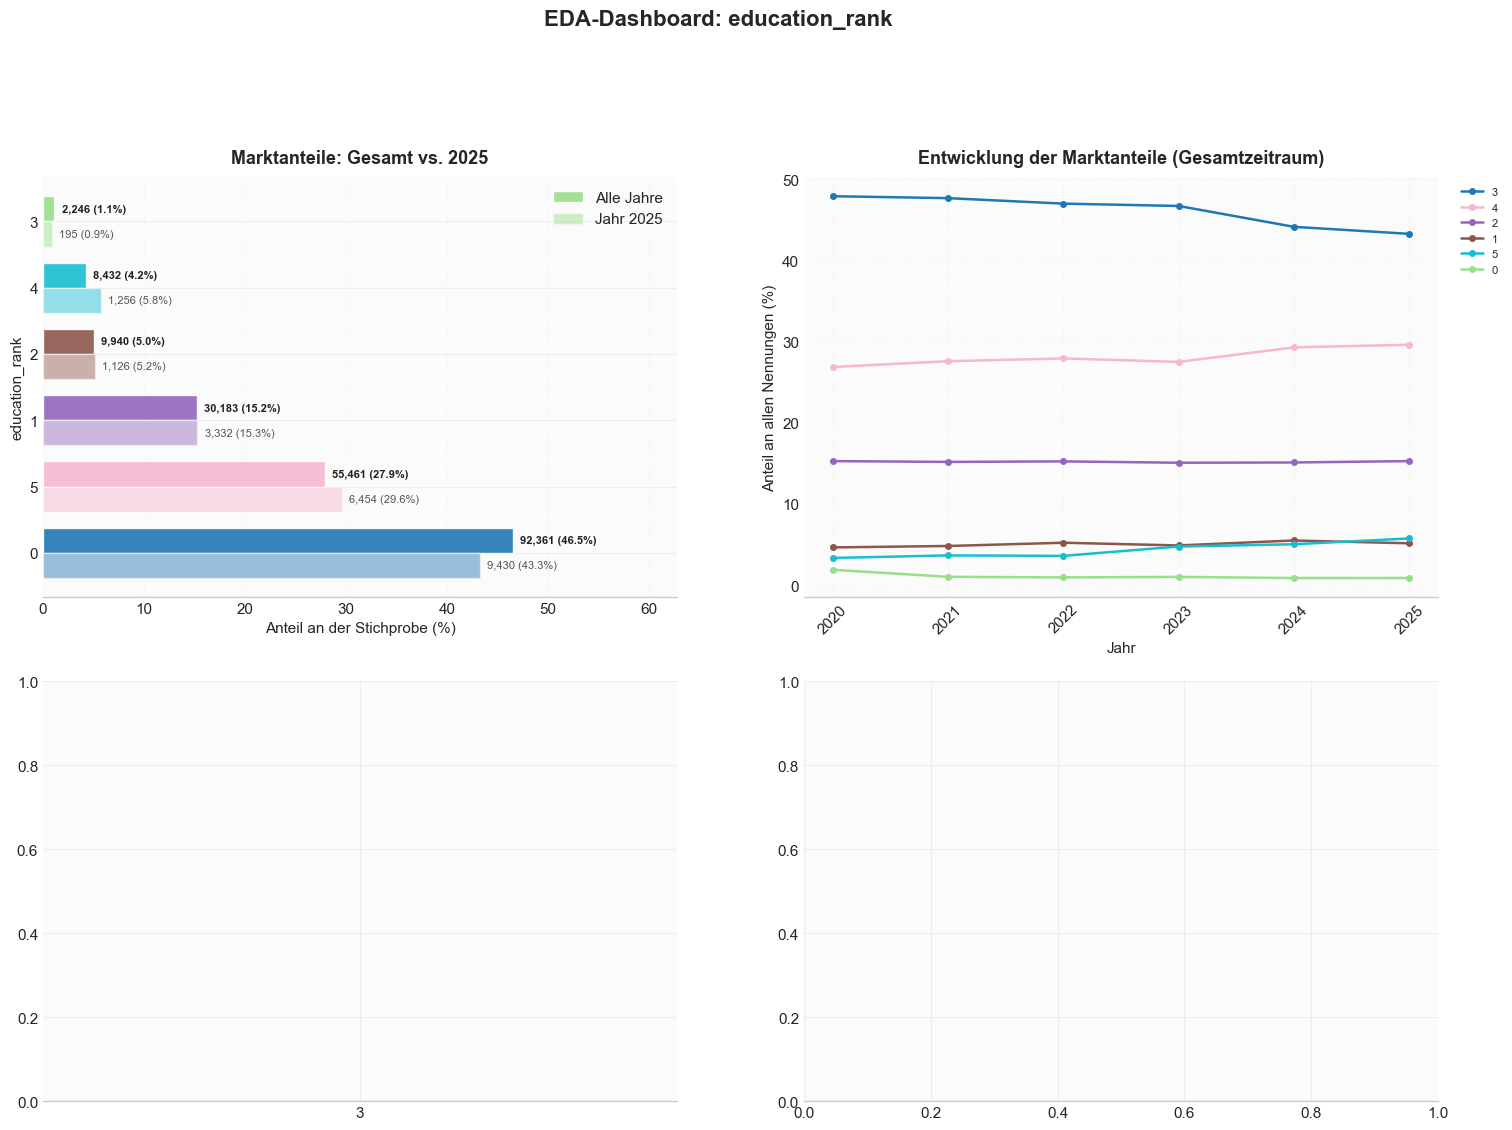

In [22]:
for c in df_grp.select_dtypes(exclude=[np.number]).columns:
    if c in df_grp.columns:
        if c not in ['language', 'database', 'platform', 'webframe', 'tech', 'ai', 'ai_agents']:
            if c in ['remote', 'icorpm']:
                eda_categorical(df_grp, c, trend_years=(2022, 2025))
            elif c in ['industry']:
                eda_categorical(df_grp, c, year=2025)
            else:
                eda_categorical(df_grp, c)
        else:
            exploded_df_grp = df_grp.copy()
            exploded_df_grp[c] = exploded_df_grp[c].astype(str).str.split(';') 
            exploded_df_grp = exploded_df_grp.explode(c)
            exploded_df_grp = exploded_df_grp.reset_index(drop=True)
            if c in ['tech']:
                  eda_categorical(exploded_df_grp, c, trend_years=(2020, 2024))
            elif c in ['ai']:
                eda_categorical(exploded_df_grp, c, trend_years=(2023, 2025))
            elif c in ['ai_select', 'ai_agents']:
                eda_categorical(exploded_df_grp, c, year=2025)
            else:
                eda_categorical(exploded_df_grp, c)


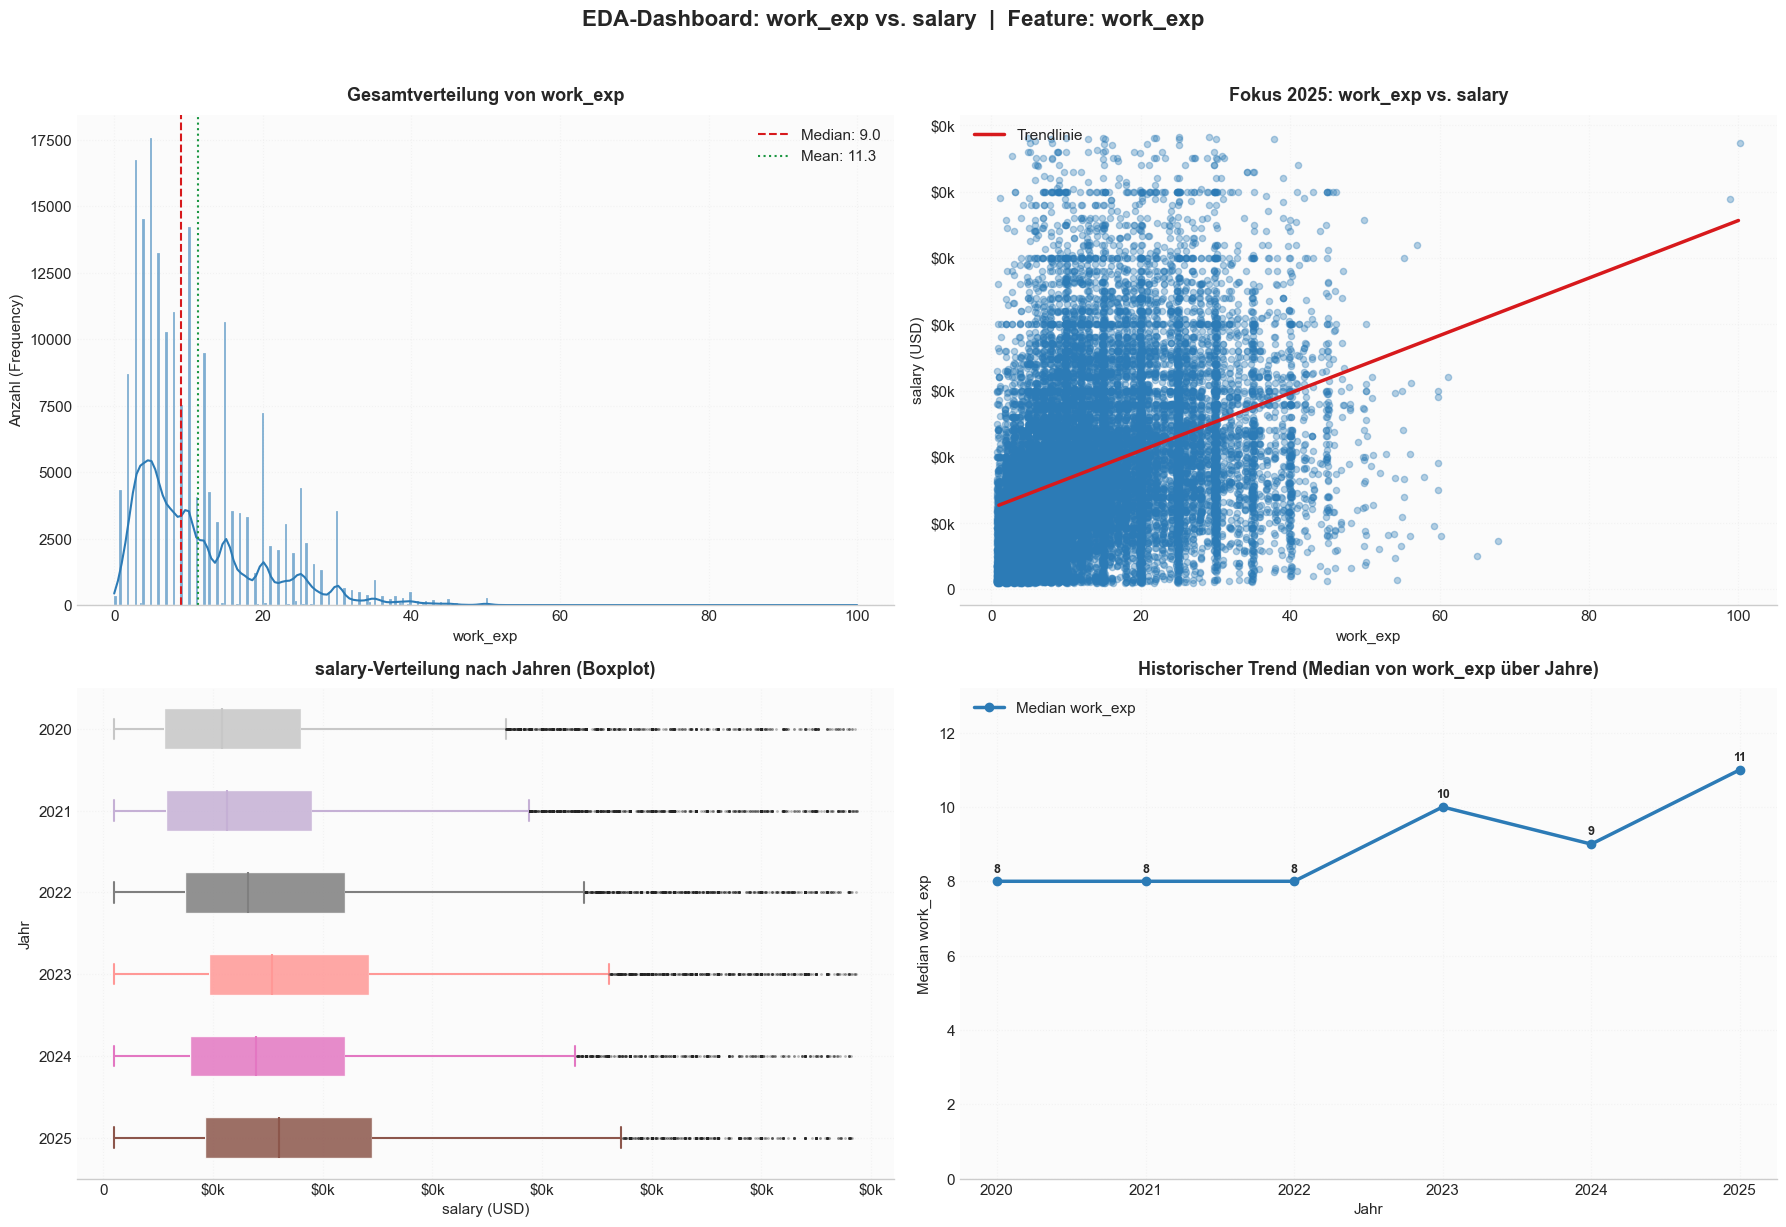

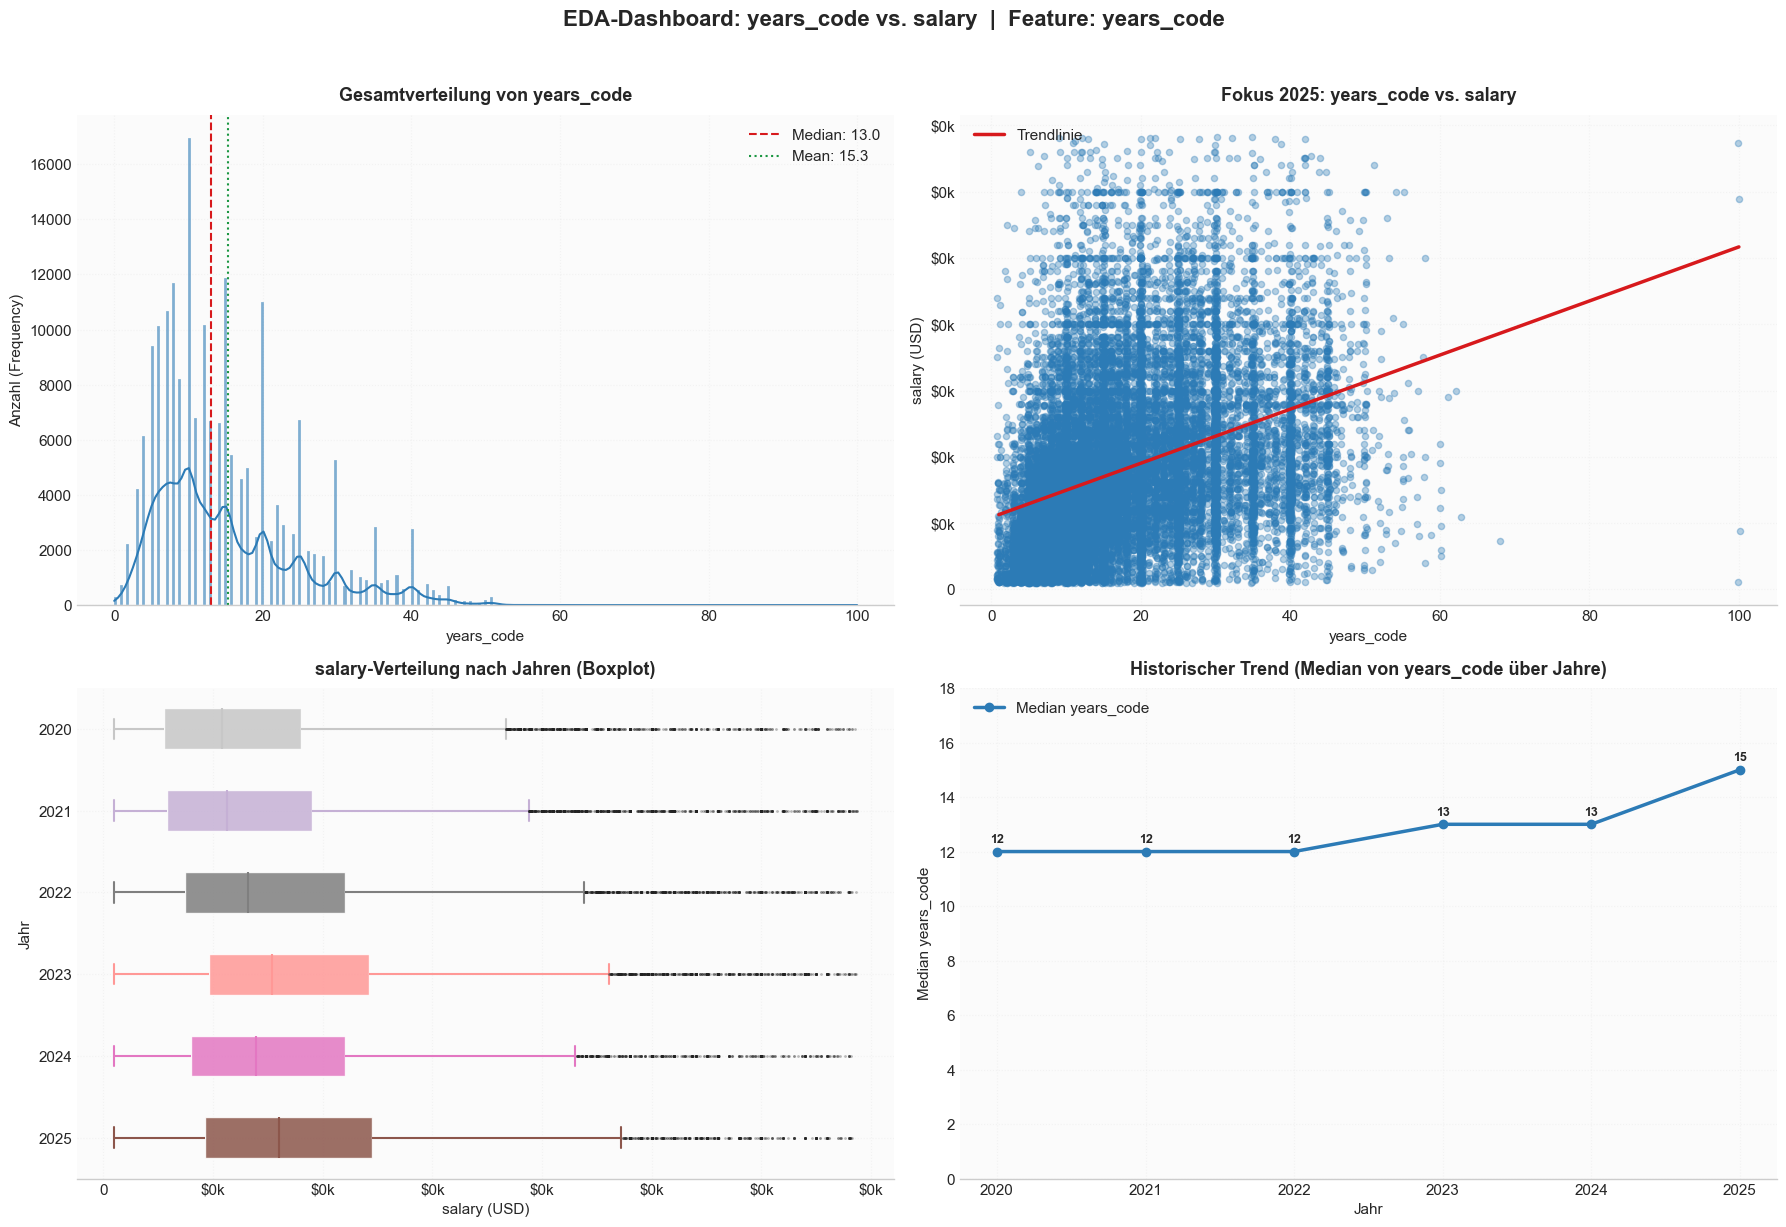

In [23]:
for c in ['work_exp', 'years_code']:
    if c in df.columns:
        eda_numeric(df_grp, col=c)

---
## ⚙️ 2. Base Model

In [ ]:
# Baseline
features_train, features_test, target_train, target_test = data_split(df)

num_cols_raw  = ['year', 'work_exp', 'years_code']
cat_cols_raw  = ['country', 'remote', 'branch', 'education', 'employment', 'industry', 'org_size', 'icorpm', 'ai_select']


cat_transformer_raw = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown = 'ignore'))])

num_transformer_raw = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', StandardScaler())]) 


preprocessor_raw = ColumnTransformer(transformers = [('cat', cat_transformer_raw, cat_cols_raw),
                                                 ('num', num_transformer_raw, num_cols_raw)], remainder = 'drop') 

model_base = Pipeline(steps = [('preprocessor', preprocessor_raw),
                               ('LinearRegression (base)', LinearRegression())])


model_base.fit(features_train, np.log1p(np.ravel(target_train)))
target_pred_base = np.expm1(model_base.predict(features_test))

df_results = pd.DataFrame(columns=["MAE", "RMSE", "R2"])
df_results.index.name = "Model"

df_results = result(df_results, "LinearRegression (base)", target_test, target_pred_base)

df_results

,MAE,RMSE,R2
Model,,,
Linear Regression (base),34.07823,50.379701,0.341946


### ➗ 3. SPLIT

In [25]:
df['country_region'] = (df['country'].map(cfg.region_mapping).fillna('Other')) 
features_train, features_test, target_train, target_test = data_split(df)

In [26]:
train_df       = df.loc[features_train.index]

global_median  = train_df["salary"].median()

country_median = (
    train_df.groupby("country")["salary"]
    .median()
)

country_role_median = (
    train_df
    .assign(primary_role=train_df["devtype_data"].str.split(";").str[0].str.strip())
    .groupby(["country", "primary_role"])["salary"]
    .median()
)

# ШАГ 3 — маппим на весь df_grp
df["country_salary_median"] = (
    df["country"].map(country_median).fillna(global_median)
)

df["country_role_median"] = df.apply(
    lambda row: country_role_median.get(
        (row["country"], str(row["devtype_data"]).split(";")[0].strip()),
        global_median
    ),
    axis=1,
)

# 
region_median = (
    train_df.groupby("country_region")["salary"]
    .median()
    .rename("region_salary_median")
)

region_role_median = (
    train_df.groupby(["country_region", "devtype_data"])["salary"]
    .median()
)

# Маппим на весь df
df["region_salary_median"] = (
    df["country_region"]
    .map(region_median)
    .fillna(global_median)
)

df["region_role_median"] = df.apply(
    lambda row: region_role_median.get(
        (row["country_region"], row["devtype_data"]),
        global_median
    ),
    axis=1,
)

# 
features_train = df.loc[features_train.index].drop(columns=["salary"])
features_test  = df.loc[features_test.index].drop(columns=["salary"])

In [27]:
def features_engineering(df_features):
    df_features = normalize_multivalue_column(df_features, 'devtype_data', mapping=cfg.data_role_mapping)
    for c in ['remote', 'branch', 'industry', 'icorpm', 'ai_select']:
        df_features[c] = df_features[c].replace(getattr(cfg, f"{c}_mapping"))
    df_features['education'] = df_features['education'].replace(cfg.education_mapping).astype(object)
    df_features['education_rank'] = df_features['education'].replace(cfg.education_rank_mapping).astype(object)
    df_features['org_size'] = df_features['org_size'].replace(cfg.org_size_mapping).astype(object)
    df_features['org_size_rank'] = df_features['org_size'].replace(cfg.org_size_rank_mapping).astype(object)
    df_features['employment'] = df_features['employment'].apply(clean_employment_status)
    
    df_features["country_region"] = (df_features["country"].map(cfg.region_mapping).fillna("Other"))    
    # df_features["is_usa"] = (df_features["country"].isin(["United States", "United States of America"])).astype(int)
    # df_features["is_germany"] = (df_features["country"] == "Germany").astype(int)
    # df_features["is_uk"] = (df_features["country"].isin(["United Kingdom", "United Kingdom of Great Britain and Northern Ireland"])).astype(int)
    # df_features["is_india"] = (df_features["country"] == "India").astype(int)
   
    df_features['country'] = df_features['country'].replace({'United States of America': 'United States',
                                                'United Kingdom of Great Britain and Northern Ireland': 'Great Britain'})
    df_features['country'] = group_rare_categories(df_features, 'country')
    df_features['currency'] = df_features['currency'].apply(categorize_currency)
    df_features['currency'] = group_rare_categories(df_features, 'currency')
    for c in ['language', 'database', 'platform', 'webframe', 'tech', 'ai']:
        current_mapping = getattr(cfg, f"{c}_mapping")
        df_features = normalize_multivalue_column(df_features, c, mapping=current_mapping)
        df_features = replace_rare_with_other(df_features, c)
    df_features["temporal_weight"] = df_features["year"].map({2020: 0.5, 2021: 0.7, 2022: 1.0, 2023: 1.5, 2024: 2.5, 2025: 3.0})
    df_features = impute_work_exp(df_features)
    return df_features

In [28]:
features_train = features_engineering(features_train)
features_test = features_engineering(features_test)

In [29]:
overview(features_train)

,dtype,count,missing_n,missing_%,uniques_n,uniques
year,int64,176830,0,0.000000,5,"[2020, 2021, 2022, 2023, 2024]"
currency,str,176830,0,0.000000,5,"[USD, GBP, EUR, Other, INR]"
country,str,176830,0,0.000000,5,"[United States, Other, Germany, India, Great B..."
work_exp,float64,176830,0,0.000000,71,"[12.0, 5.0, 6.0, 26.0, 3.0, 28.0, 4.0, 23.0, 2..."
years_code,float64,176224,606,0.342702,52,"[17.0, 8.0, 10.0, 7.0, 35.0, 5.0, 37.0, 9.0, 3..."
remote,str,176830,0,0.000000,4,"[Unknown, Hybrid, Remote, On-site]"
branch,str,176830,0,0.000000,2,"[Professional, Coding at Work/Studies]"
education,object,176830,0,0.000000,6,"[Bachelor, Master, College / Undergrad, School..."
employment,str,176830,0,0.000000,4,"[Full-time, Freelance, Part-time, Unknown]"
industry,str,176830,0,0.000000,13,"[Unknown, IT, Telecom & Tech, Other, Banking, ..."


---
## 🧠 4. ML

In [30]:
cat_cols  = ['country', 
             'currency', 
             'remote', 
             'branch', 
             'employment',
             'industry', 
             'icorpm', 
             'ai_select', 
             'education', 
             'org_size',
             'country_region'
             ]

multi_cols = ['language', 'database', 'platform', 'webframe', 'tech', 'ai',
              'devtype_data',
              'devtype_other'
              ] 

pca_cols  = []

num_cols   = ['year', 'education_rank', 'org_size_rank', 'work_exp', 'years_code',
              # -'role_count', 
              # - 'data_role_purity', 
              # - 'count_data', 
              # 'count_developer', 'count_manager', 'count_other',
              # 'has_data', 'has_developer', 'has_manager', 'has_other',
            'temporal_weight',
            'country_salary_median', 'country_role_median',
            'region_salary_median', 'region_role_median'
            ] 

for c in cat_cols:
    features_train[c] = features_train[c].fillna('Unknown')
    features_train[c] = features_train[c].astype('category')

for c in num_cols:
    # Umwandlung in Fließkommazahlen und Imputation fehlender Werte durch den Median
    features_train[c] = features_train[c].astype('float32')
    features_train[c] = features_train[c].fillna(features_train[c].median())
    
    # Durchführung der automatischen Typoptimierung basierend auf Wertebereichen
    if (features_train[c] % 1 != 0).any():
        # Zuweisung des Datentyps 'float32' bei Vorhandensein von Nachkommastellen
        features_train[c] = features_train[c].astype('float32')
    else:
        if features_train[c].min() < 0:
            # Klassifizierung für vorzeichenbehaftete Ganzzahlen
            if features_train[c].min() >= -128 and features_train[c].max() <= 127:
                features_train[c] = features_train[c].astype('int8')
            elif features_train[c].min() >= -32768 and features_train[c].max() <= 32767:
                features_train[c] = features_train[c].astype('int16')
            else:
                features_train[c] = features_train[c].astype('int32')
        else:
            # Klassifizierung für vorzeichenlose Ganzzahlen
            if features_train[c].max() < 255:
                features_train[c] = features_train[c].astype('uint8')
            elif features_train[c].max() < 65535:
                features_train[c] = features_train[c].astype('uint16')
            else:
                features_train[c] = features_train[c].astype('int32')

# weights_all = compute_sample_weights(features_train, strategy='purity')
# weights_train = weights_all.loc[features_train.index]

In [31]:
# Transformation für numerische Daten: Imputation durch Median und Skalierung
num_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),
                             ('scaler', StandardScaler())]) 

# Transformation für PCA-Komponenten: Median-Imputation, Skalierung und anschließend PCA
pca_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                    ('scaler', StandardScaler()), 
                                    ('pca', PCA(n_components=1))])

# Transformation für kategoriale Daten: Imputation durch häufigsten Wert und One-Hot-Encoding
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

# Multilabel-Vektorisierung mittels CountVectorizer (Trennung durch Semikolon)
vectorizer_step = CountVectorizer(tokenizer=lambda x: str(x).split(';'), lowercase=False)

# Liste der Transformer für den ColumnTransformer
transformers_list = [('num', num_transformer, num_cols),
                     ('cat', cat_transformer, cat_cols),
                     ('pca', pca_transformer, pca_cols)]

# Automatische Hinzufügung jeder Multivalue-Spalte einzeln.
# Dies stellt sicher, dass der ColumnTransformer sie als 1D-Vektoren verarbeitet
for col in multi_cols:
    transformers_list.append(
        (f'multi_{col}', vectorizer_step, col)  # Передаем col как строку, а не ['col']
    )
    
# Initialisierung des finalen Preprocessors
preprocessor = ColumnTransformer(transformers=transformers_list, remainder='drop')

In [32]:
# Daten durch den Preprocessor leiten (Training und Transformation)
features_transformed = preprocessor.fit_transform(features_train)

# Namen der neuen Spalten abrufen, die durch OHE und CountVectorizer generiert wurden
column_names = preprocessor.get_feature_names_out()

# Den DataFrame wieder schön zusammenbauen
# Falls das Ergebnis eine sparse matrix (scipy) ist, 
# nutzen wir .toarray(), ansonsten verwenden wir die Daten direkt
if hasattr(features_transformed, "toarray"):
    df_transformed = pd.DataFrame(features_transformed.toarray(), columns=column_names, index=df.index)
else:
    df_transformed = pd.DataFrame(features_transformed, columns=column_names, index=features_train.index)

print(f"Dimensionen des DataFrames VORHER: {features_train.shape}")
print(f"Dimensionen des DataFrames NACHHER: {df_transformed.shape}")
display(df_transformed.head())

Dimensionen des DataFrames VORHER: (176830, 33)
Dimensionen des DataFrames NACHHER: (176830, 188)


,num__year,num__education_rank,num__org_size_rank,num__work_exp,num__years_code,num__temporal_weight,num__country_salary_median,num__country_role_median,num__region_salary_median,num__region_role_median,...,multi_devtype_other__None,multi_devtype_other__Other (please specify):,multi_devtype_other__Product manager,multi_devtype_other__Project manager,multi_devtype_other__Research & Development role,multi_devtype_other__Security professional,"multi_devtype_other__Senior Executive (C-Suite, VP, etc.)",multi_devtype_other__Senior executive/VP,multi_devtype_other__Student,multi_devtype_other__System administrator
7,-1.457186,-0.076296,-0.699304,0.113702,0.208832,-1.046088,1.015918,0.984917,1.447719,1.503576,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,-1.457186,0.983762,-1.094125,-0.712695,-0.727221,-1.046088,-0.139450,-0.342744,0.198219,-0.174945,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,-1.457186,-0.076296,1.669622,-0.594638,-0.519210,-1.046088,-0.139450,-0.148915,0.198219,0.206920,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,-1.457186,-1.136353,-1.094125,-0.712695,-0.831227,-1.046088,-0.681916,-0.644583,-0.509231,-0.499258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,-1.457186,-2.196411,-1.094125,1.766496,2.080938,-1.046088,-0.133619,-0.143192,-0.509231,-0.499258,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
# Wörterbuch der Modelle
models = {'LinearRegression': LinearRegression(),
          'Ridge': Ridge(random_state=42),
          'XGBoost': xgb.XGBRegressor(random_state=42),
          'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1),
          'CatBoostRegressor': CatBoostRegressor(random_state=42, verbose=0),
          'DecisionTree': DecisionTreeRegressor(random_state=42),
          'ExtraTrees': ExtraTreesRegressor(random_state=42),
          'RandomForest': RandomForestRegressor(random_state=42),
          'ElasticNet': ElasticNet(alpha=0.01)}

for name, model_instance in models.items():
    print(f"Modelltraining: {name}...")
    
    # Pipeline-Erstellung und -Training, Vorhersage
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model_instance)])
    
    pipeline.fit(features_train, np.log1p(np.ravel(target_train)))
    target_pred = np.expm1(pipeline.predict(features_test))
    
    # Das Ergebnis in eine Tabelle schreiben
    result(df_results, name, target_test, target_pred)

df_results

Modelltraining: Linear Regression...
Modelltraining: Ridge...
Modelltraining: XGBoost...
Modelltraining: LightGBM...
Modelltraining: CatBoostRegressor...
Modelltraining: DecisionTree...
Modelltraining: ExtraTrees...
Modelltraining: RandomForest...
Modelltraining: ElasticNet...


,MAE,RMSE,R2
Model,,,
Linear Regression (base),34.078230,50.379701,0.341946
Linear Regression,29.939397,44.553446,0.485349
Ridge,29.939142,44.553627,0.485344
XGBoost,27.965632,42.384370,0.534240
LightGBM,27.162430,41.465057,0.554226
CatBoostRegressor,26.149152,39.983664,0.585508
DecisionTree,38.772602,56.784736,0.163986
ExtraTrees,27.225978,41.341027,0.556888
RandomForest,27.755915,42.140638,0.539582


In [43]:
# N_TRIALS = 50  # увелич до 100 для финала

# # ── Пространства гиперпараметров ─────────────────────────────────────────────
# def get_params(trial, name):
#     if name == 'Ridge':
#         return {"alpha": trial.suggest_float("alpha", 1e-3, 100, log=True)}

#     if name == 'ElasticNet':
#         return {
#             "alpha":    trial.suggest_float("alpha", 1e-4, 10, log=True),
#             "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
#         }

#     if name == 'DecisionTree':
#         return {
#             "max_depth":         trial.suggest_int("max_depth", 3, 20),
#             "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
#             "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
#         }

#     if name == 'ExtraTrees':
#         return {
#             "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
#             "max_depth":         trial.suggest_int("max_depth", 5, 30),
#             "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
#         }

#     if name == 'RandomForest':
#         return {
#             "n_estimators": trial.suggest_int("n_estimators", 100, 600),
#             "max_depth":    trial.suggest_int("max_depth", 5, 30),
#             "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
#         }

#     if name == 'XGBoost':
#         return {
#             "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
#             "max_depth":        trial.suggest_int("max_depth", 3, 10),
#             "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
#             "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#             "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
#             "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
#         }

#     if name == 'LightGBM':
#         return {
#             "n_estimators":  trial.suggest_int("n_estimators", 200, 1000),
#             "max_depth":     trial.suggest_int("max_depth", 3, 12),
#             "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             "num_leaves":    trial.suggest_int("num_leaves", 20, 150),
#             "subsample":     trial.suggest_float("subsample", 0.6, 1.0),
#             "reg_alpha":     trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
#             "reg_lambda":    trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
#         }

#     if name == 'CatBoostRegressor':
#         return {
#             "iterations":          trial.suggest_int("iterations", 300, 1500),
#             "depth":               trial.suggest_int("depth", 4, 10),
#             "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1, 15),
#             "subsample":           trial.suggest_float("subsample", 0.6, 1.0),
#             "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
#         }

#     return {}


# # ── Конструктор модели по имени и параметрам ──────────────────────────────────
# def build_model(name, params):
#     constructors = {
#         'Ridge':             lambda p: Ridge(**p),
#         'ElasticNet':        lambda p: ElasticNet(**p),
#         'DecisionTree':      lambda p: DecisionTreeRegressor(random_state=42, **p),
#         'ExtraTrees':        lambda p: ExtraTreesRegressor(random_state=42, **p),
#         'RandomForest':      lambda p: RandomForestRegressor(random_state=42, **p),
#         'XGBoost':           lambda p: xgb.XGBRegressor(random_state=42, **p),
#         'LightGBM':          lambda p: lgb.LGBMRegressor(random_state=42, verbose=-1, **p),
#         'CatBoostRegressor': lambda p: CatBoostRegressor(random_state=42, verbose=0, **p),
#     }
#     return constructors[name](params)


# # ── Словарь моделей ───────────────────────────────────────────────────────────
# models = {
#     'Linear Regression': LinearRegression(),
#     'Ridge':             Ridge(random_state=42),
#     'XGBoost':           xgb.XGBRegressor(random_state=42),
#     'LightGBM':          lgb.LGBMRegressor(random_state=42, verbose=-1),
#     'CatBoostRegressor': CatBoostRegressor(random_state=42, verbose=0),
#     'DecisionTree':      DecisionTreeRegressor(random_state=42),
#     'ExtraTrees':        ExtraTreesRegressor(random_state=42),
#     'RandomForest':      RandomForestRegressor(random_state=42),
#     'ElasticNet':        ElasticNet(alpha=0.01), 'GradientBoosting': GradientBoostingRegressor(random_state=42)
# }

# # ── Основной цикл ─────────────────────────────────────────────────────────────
# for name, base_instance in models.items():
#     print(f"\n{'─'*50}")
#     print(f"▶ {name}")

#     # 1. Базовая модель
#     pipe_base = Pipeline([('preprocessor', preprocessor),
#                           ('regressor', base_instance)])
#     pipe_base.fit(features_train, np.log1p(np.ravel(target_train)))
#     pred_base = np.expm1(pipe_base.predict(features_test))
#     df_results = result(df_results, name, target_test, pred_base)
#     print(f"  base MAE: {mean_absolute_error(target_test, pred_base):.2f}")

#     # LinearRegression — гиперпараметров нет, пропускаем Optuna
#     if name == 'Linear Regression':
#         continue

#     # 2. Optuna
#     def objective(trial):
#         params = get_params(trial, name)
#         model  = build_model(name, params)
#         pipe   = Pipeline([('preprocessor', preprocessor),
#                            ('regressor', model)])
#         pipe.fit(features_train, np.log1p(np.ravel(target_train)))
#         pred = np.expm1(pipe.predict(features_test))
#         return mean_absolute_error(target_test, pred)

#     study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
#     study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

#     # 3. Финальная модель с лучшими параметрами
#     best_params    = study.best_params
#     best_model_opt = build_model(name, best_params)
#     pipe_opt = Pipeline([('preprocessor', preprocessor),
#                          ('regressor', best_model_opt)])
#     pipe_opt.fit(features_train, np.log1p(np.ravel(target_train)))
#     pred_opt = np.expm1(pipe_opt.predict(features_test))

#     df_results = result(df_results, f"{name} (Optuna)", target_test, pred_opt)

#     improvement = mean_absolute_error(target_test, pred_base) - mean_absolute_error(target_test, pred_opt)
#     print(f"  best MAE:   {mean_absolute_error(target_test, pred_opt):.2f}  (улучшение: {improvement:+.2f})")
#     print(f"  best params: {best_params}")

# print(f"\n{'='*50}")
# print("✅ Все модели обучены")
# df_results

In [ ]:
# Stacking /  Ensemble?

In [34]:
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', CatBoostRegressor(random_state=42))])

best_model.fit(features_train, np.log1p(np.ravel(target_train)))
target_pred = np.expm1(best_model.predict(features_test))


Learning rate set to 0.092746
0:	learn: 0.7898018	total: 31.2ms	remaining: 31.1s
1:	learn: 0.7504934	total: 49.9ms	remaining: 24.9s
2:	learn: 0.7163753	total: 68.2ms	remaining: 22.7s
3:	learn: 0.6861196	total: 85.9ms	remaining: 21.4s
4:	learn: 0.6602131	total: 105ms	remaining: 20.8s
5:	learn: 0.6376492	total: 121ms	remaining: 20.1s
6:	learn: 0.6175689	total: 140ms	remaining: 19.9s
7:	learn: 0.6003942	total: 158ms	remaining: 19.5s
8:	learn: 0.5848725	total: 175ms	remaining: 19.3s
9:	learn: 0.5712378	total: 194ms	remaining: 19.2s
10:	learn: 0.5595494	total: 213ms	remaining: 19.1s
11:	learn: 0.5493356	total: 232ms	remaining: 19.1s
12:	learn: 0.5402862	total: 250ms	remaining: 19s
13:	learn: 0.5326126	total: 268ms	remaining: 18.9s
14:	learn: 0.5259849	total: 285ms	remaining: 18.7s
15:	learn: 0.5201012	total: 304ms	remaining: 18.7s
16:	learn: 0.5146879	total: 323ms	remaining: 18.7s
17:	learn: 0.5099219	total: 342ms	remaining: 18.7s
18:	learn: 0.5058269	total: 362ms	remaining: 18.7s
19:	learn

In [35]:
result(df_results, 'best_model', target_test, target_pred)

,MAE,RMSE,R2
Model,,,
Linear Regression (base),34.078230,50.379701,0.341946
Linear Regression,29.939397,44.553446,0.485349
Ridge,29.939142,44.553627,0.485344
XGBoost,27.965632,42.384370,0.534240
LightGBM,27.162430,41.465057,0.554226
CatBoostRegressor,26.149152,39.983664,0.585508
DecisionTree,38.772602,56.784736,0.163986
ExtraTrees,27.225978,41.341027,0.556888
RandomForest,27.755915,42.140638,0.539582


In [ ]:
# def catboost_objective(trial):
#     params = {
#         "loss_function":   "MAE",
#         "iterations":      trial.suggest_int("iterations", 500, 2000),
#         "depth":           trial.suggest_int("depth", 3, 7),
#         "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
#         "l2_leaf_reg":     trial.suggest_float("l2_leaf_reg", 1.0, 15.0),
#         "subsample":       trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
#         "min_data_in_leaf":  trial.suggest_int("min_data_in_leaf", 5, 50),
#         "random_state":    42,
#         "verbose":         False,
#     }

#     model = Pipeline([
#         ("preprocessor", preprocessor),
#         ("regressor",    CatBoostRegressor(**params)),
#     ])
#     model.fit(
#         features_train,
#         np.log1p(np.ravel(target_train)),
#         #regressor__sample_weight=weights_train.values,
#     )
#     pred = np.expm1(model.predict(features_test))
#     return mean_absolute_error(target_test, pred)


# study = optuna.create_study(direction="minimize")
# study.optimize(catboost_objective, n_trials=50, show_progress_bar=True)
# best_params = study.best_params

# print(f"\nBest MAE:    {study.best_value:.3f}")
# print(f"Best params: {study.best_params}")

[I 2026-06-02 02:37:01,212] A new study created in memory with name: no-name-0525874d-492e-4383-b989-95ef8288a5b7


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-02 02:37:23,909] Trial 0 finished with value: 26.493564016589172 and parameters: {'iterations': 978, 'depth': 4, 'learning_rate': 0.06284115773726538, 'l2_leaf_reg': 11.218837995631496, 'subsample': 0.9125446621757126, 'colsample_bylevel': 0.7959894905665409, 'min_data_in_leaf': 9}. Best is trial 0 with value: 26.493564016589172.
[I 2026-06-02 02:38:03,473] Trial 1 finished with value: 27.299726910162285 and parameters: {'iterations': 1585, 'depth': 5, 'learning_rate': 0.010801757498336628, 'l2_leaf_reg': 3.7835800441255927, 'subsample': 0.8028545250685372, 'colsample_bylevel': 0.9298343095072672, 'min_data_in_leaf': 26}. Best is trial 0 with value: 26.493564016589172.
[I 2026-06-02 02:38:28,031] Trial 2 finished with value: 27.283114226410934 and parameters: {'iterations': 788, 'depth': 5, 'learning_rate': 0.020783131036461882, 'l2_leaf_reg': 9.199646189239239, 'subsample': 0.9447967145624179, 'colsample_bylevel': 0.7589758698863874, 'min_data_in_leaf': 46}. Best is trial 0

In [ ]:
#best_params.update({"loss_function": "MAE", "random_state": 42, "verbose": 100})

In [ ]:
# # [32m[I 2026-06-02 03:17:16,858][0m Trial 48 finished with value: 25.872713804605624 and parameters: {'iterations': 1818, 'depth': 7, 'learning_rate': 0.06704878894910303, 'l2_leaf_reg': 2.331491290479047, 'subsample': 0.7893335678071498, 'colsample_bylevel': 0.6028082428270319, 'min_data_in_leaf': 21}. Best is trial 48 with value: 25.872713804605624.[0m
#  MAE:    25.873
#  params: {'iterations': 1818, 'depth': 7, 'learning_rate': 0.06704878894910303, 'l2_leaf_reg': 2.331491290479047, 'subsample': 0.7893335678071498, 'colsample_bylevel': 0.6028082428270319, 'min_data_in_leaf': 21}


In [39]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor",    CatBoostRegressor(**{'loss_function': 'MAE',
                                          'iterations': 1818, 
                                          'depth': 7, 
                                          'learning_rate': 0.06704878894910303, 
                                          'l2_leaf_reg': 2.331491290479047, 
                                          'subsample': 0.7893335678071498, 
                                          'colsample_bylevel': 0.6028082428270319, 
                                          'min_data_in_leaf': 21,
                                          'random_state': 42}))])

best_model.fit(
    features_train,
    np.log1p(np.ravel(target_train)),
    #regressor__sample_weight=weights_train.values,
)

target_pred = np.expm1(best_model.predict(features_test))
result(df_results, "best_model_optuna", target_test, target_pred)
df_results

0:	learn: 0.6275379	total: 29ms	remaining: 52.6s
1:	learn: 0.6022024	total: 58.3ms	remaining: 52.9s
2:	learn: 0.5790742	total: 89.6ms	remaining: 54.2s
3:	learn: 0.5579523	total: 119ms	remaining: 54s
4:	learn: 0.5394717	total: 152ms	remaining: 55.1s
5:	learn: 0.5221754	total: 184ms	remaining: 55.4s
6:	learn: 0.5054413	total: 217ms	remaining: 56.2s
7:	learn: 0.4908602	total: 249ms	remaining: 56.4s
8:	learn: 0.4775315	total: 288ms	remaining: 57.9s
9:	learn: 0.4655370	total: 320ms	remaining: 57.9s
10:	learn: 0.4546168	total: 353ms	remaining: 57.9s
11:	learn: 0.4440696	total: 380ms	remaining: 57.2s
12:	learn: 0.4355531	total: 411ms	remaining: 57s
13:	learn: 0.4275881	total: 441ms	remaining: 56.8s
14:	learn: 0.4199290	total: 471ms	remaining: 56.6s
15:	learn: 0.4132481	total: 503ms	remaining: 56.6s
16:	learn: 0.4075702	total: 531ms	remaining: 56.2s
17:	learn: 0.4015915	total: 557ms	remaining: 55.7s
18:	learn: 0.3959925	total: 585ms	remaining: 55.4s
19:	learn: 0.3908251	total: 613ms	remaining:

,MAE,RMSE,R2
Model,,,
Linear Regression (base),34.078230,50.379701,0.341946
Linear Regression,29.939397,44.553446,0.485349
Ridge,29.939142,44.553627,0.485344
XGBoost,27.965632,42.384370,0.534240
LightGBM,27.162430,41.465057,0.554226
CatBoostRegressor,26.149152,39.983664,0.585508
DecisionTree,38.772602,56.784736,0.163986
ExtraTrees,27.225978,41.341027,0.556888
RandomForest,27.755915,42.140638,0.539582


---
## 4. SHAP

Вычисляем SHAP значения...
shap_df (all):  (21793, 188)
Чистых строк в тесте: 1541
shap_df_pure:   (1541, 188)
median_salary_global: 65.7k  (= $65,663)

══════════════════════════════════════════════════════════════
  БЛОК А — Весь тестовый датасет
══════════════════════════════════════════════════════════════

SHAP — все признаки (весь тест) — топ-20 признаков


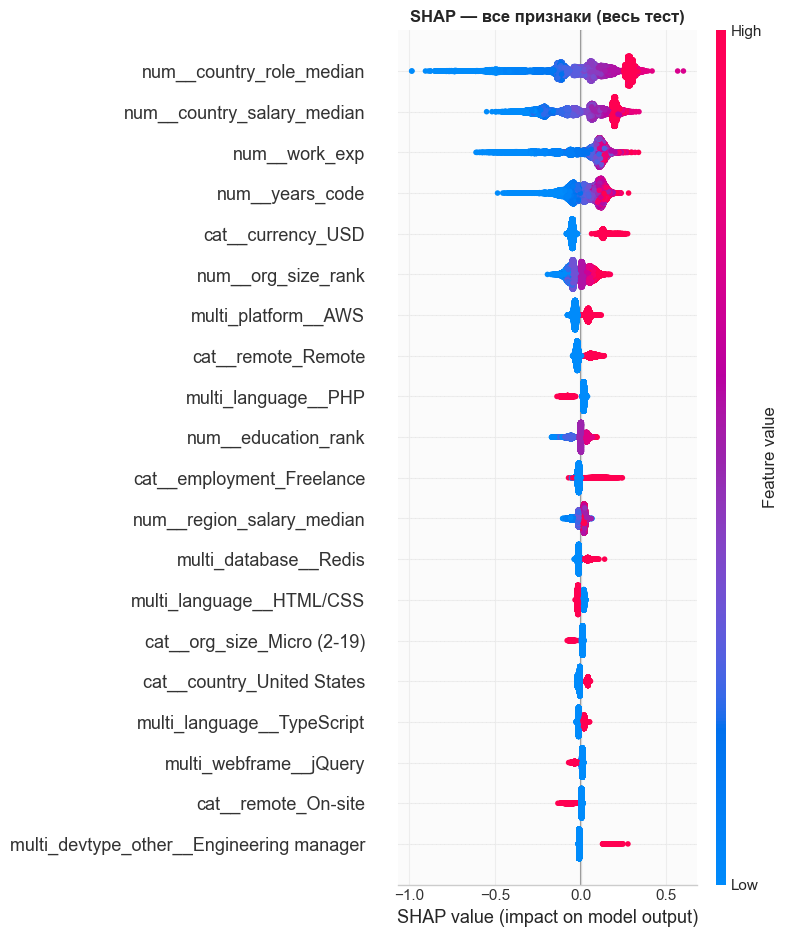

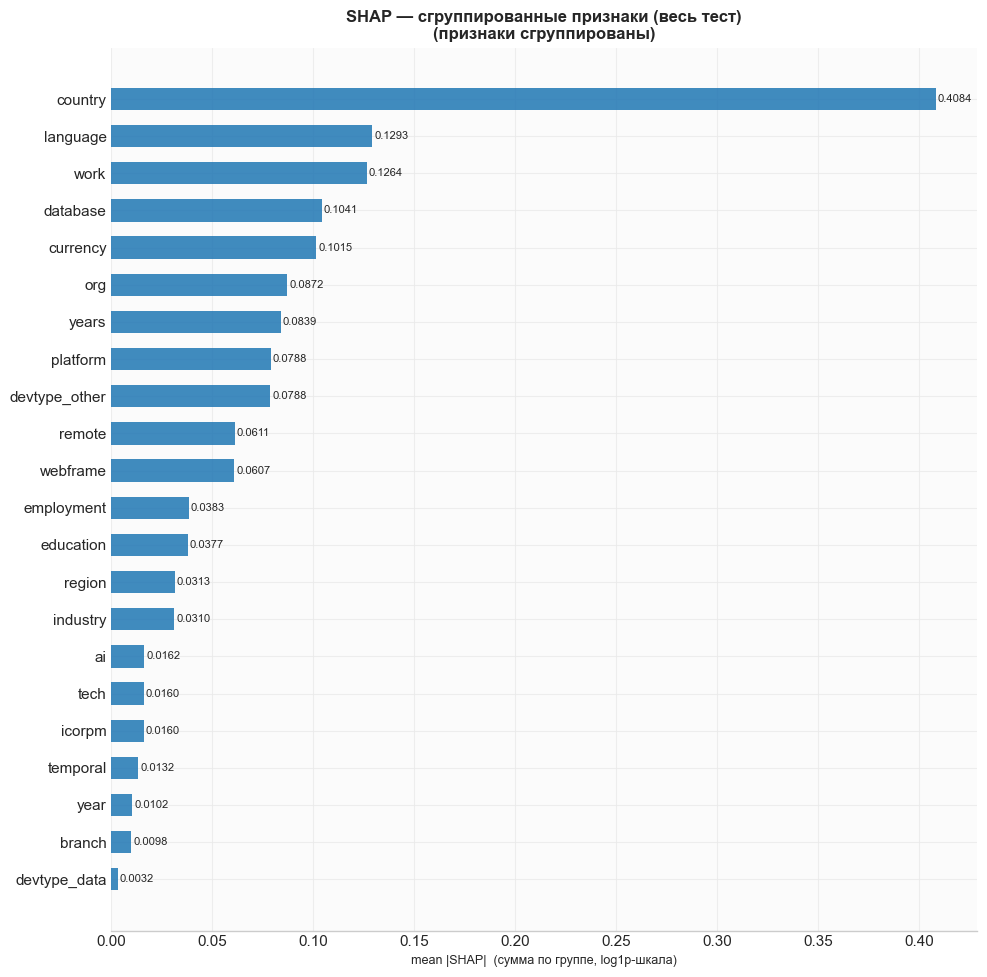

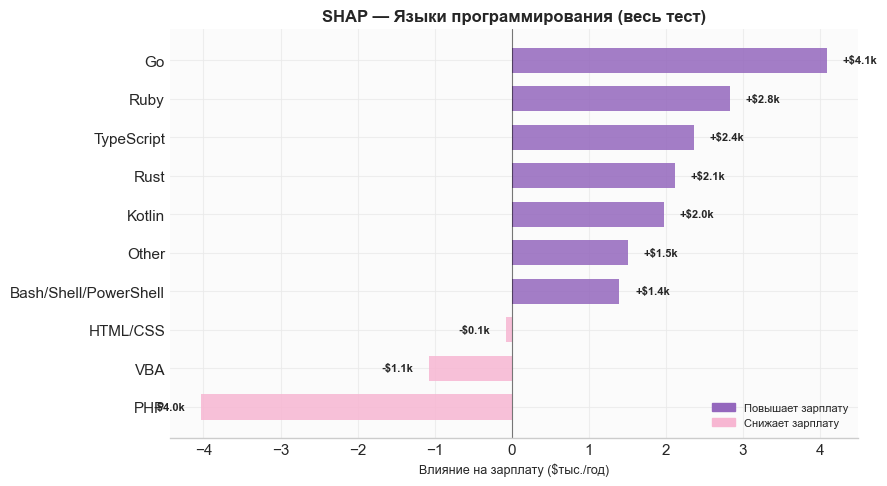

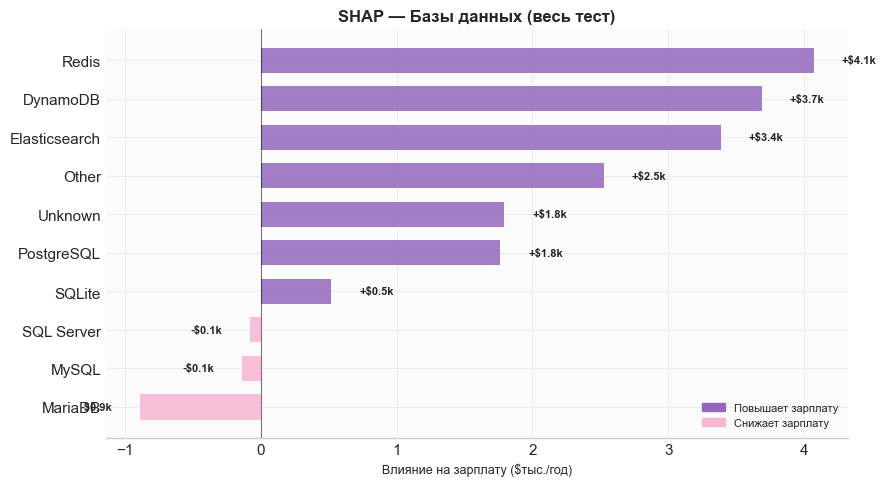

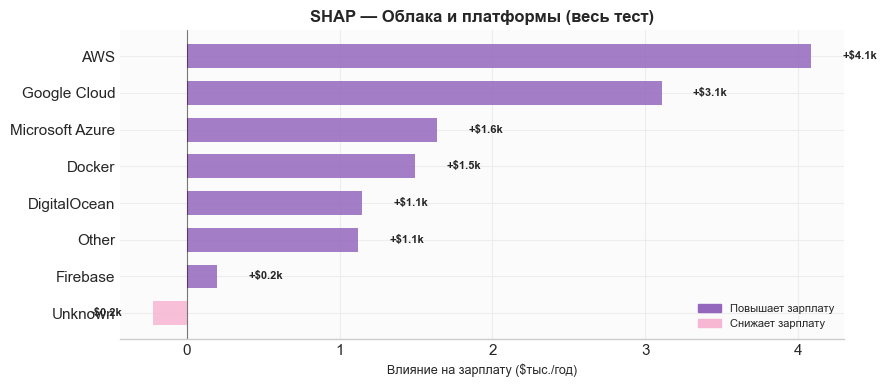

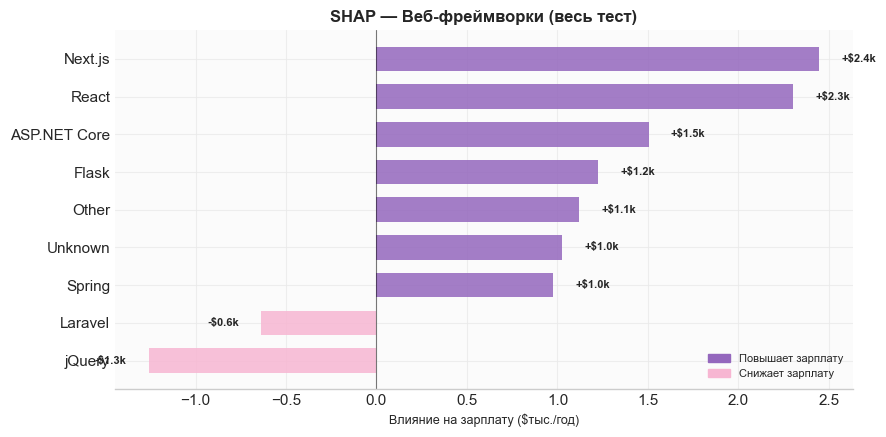

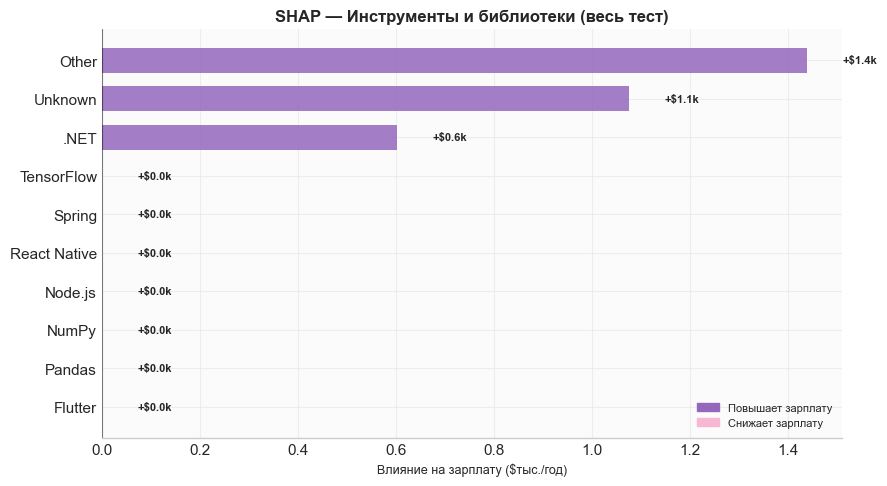

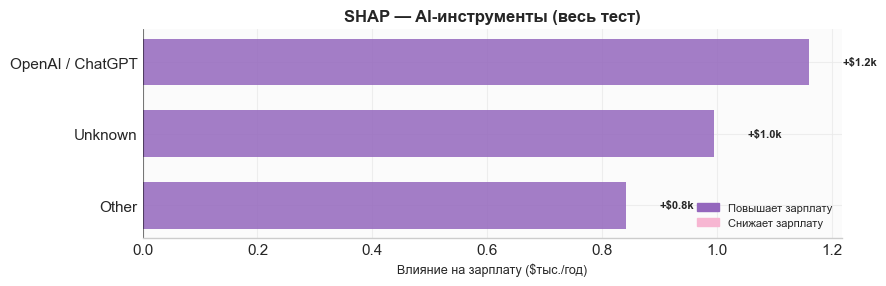


══════════════════════════════════════════════════════════════
  БЛОК Б — Только pure data roles (purity = 1.0)
══════════════════════════════════════════════════════════════

SHAP — все признаки (pure data roles) — топ-20 признаков


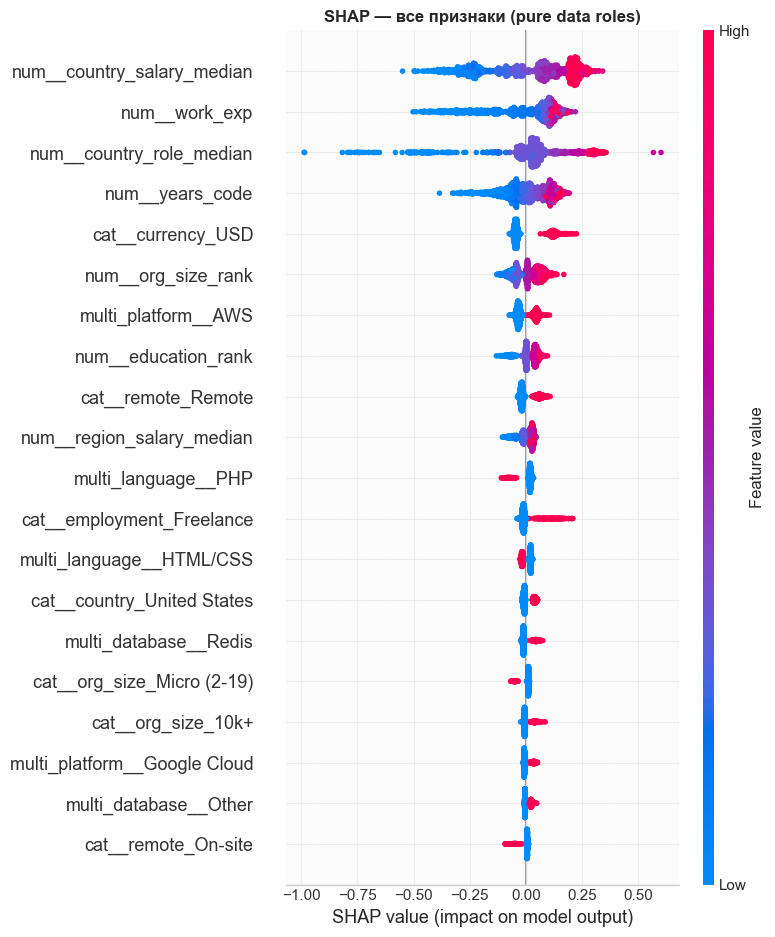

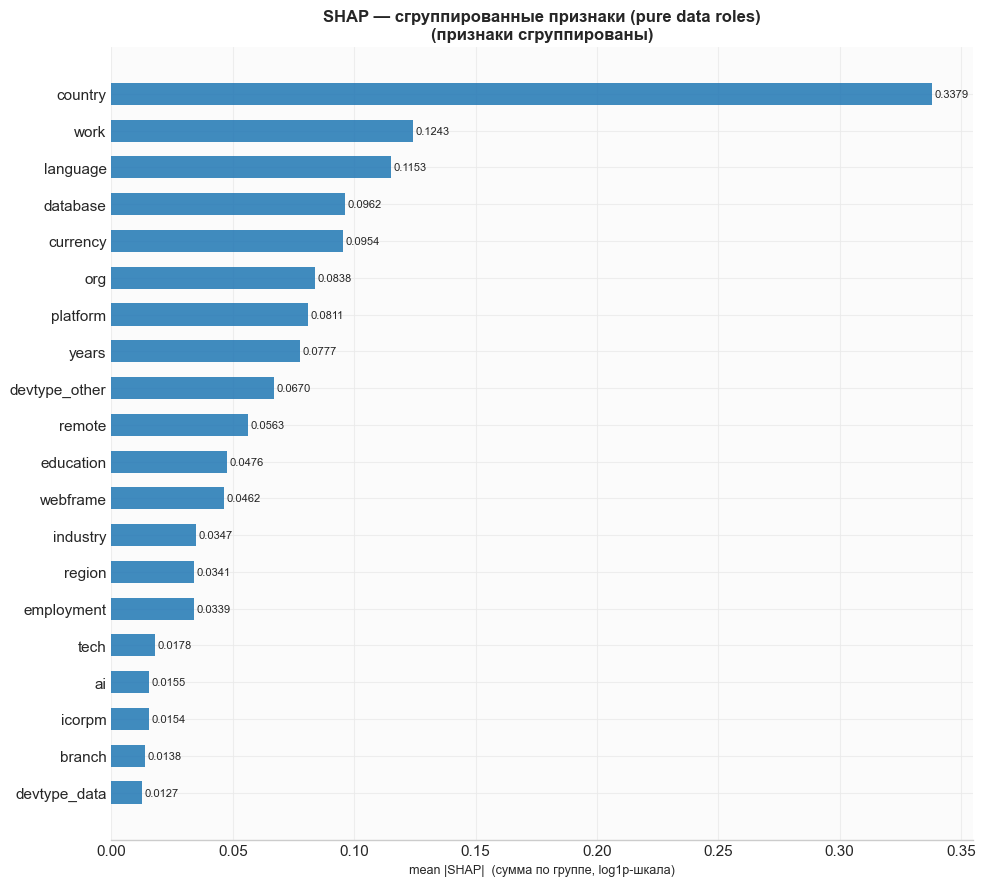

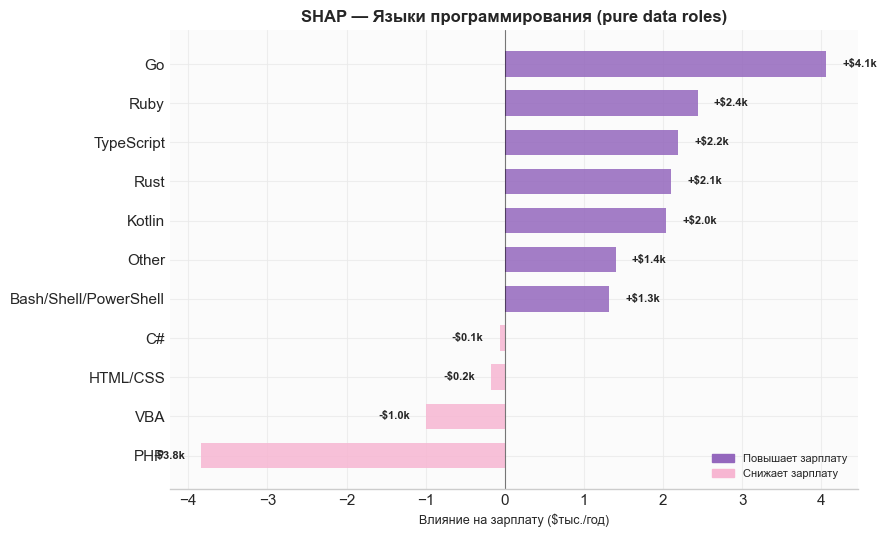

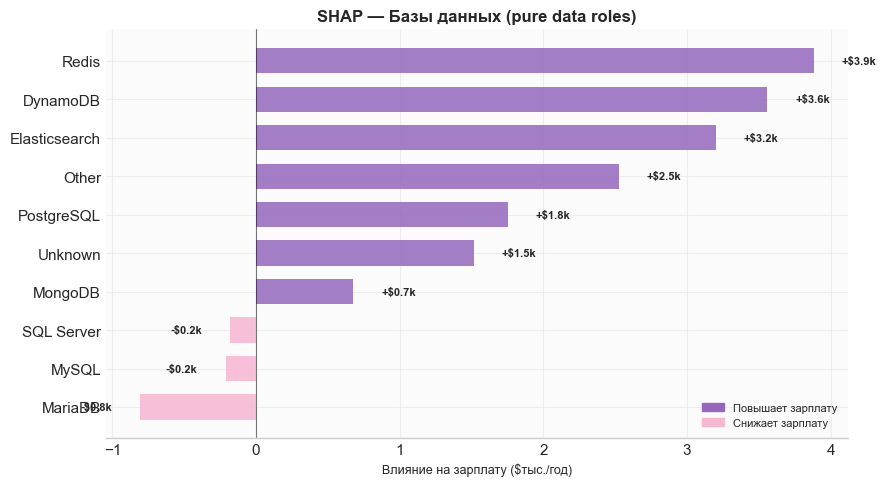

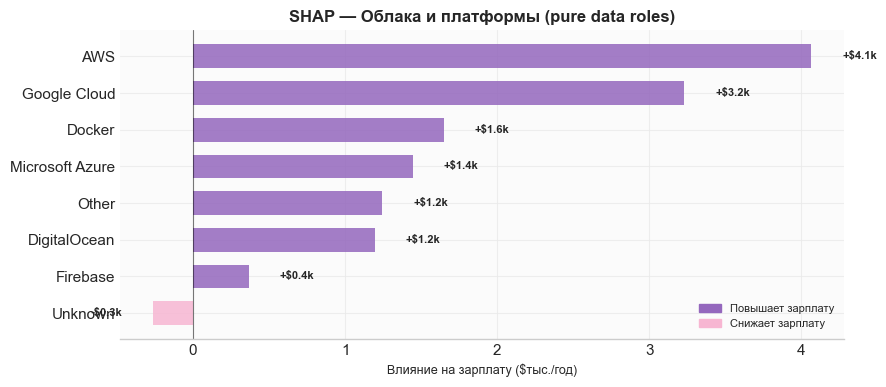

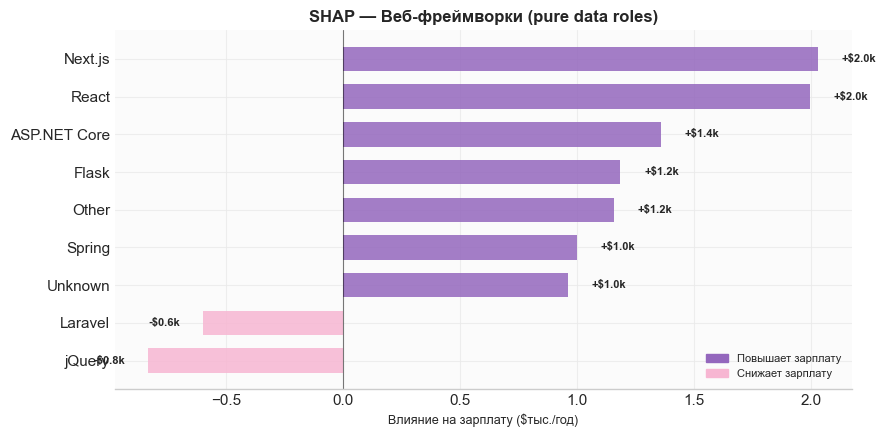

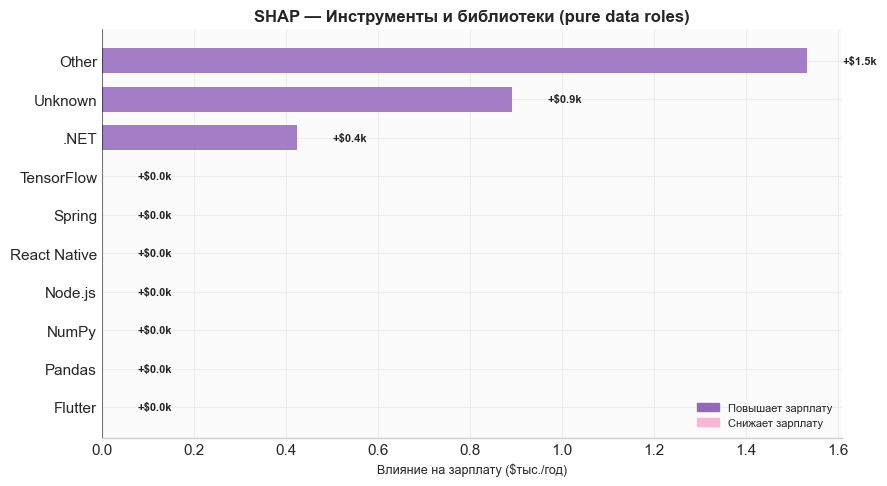

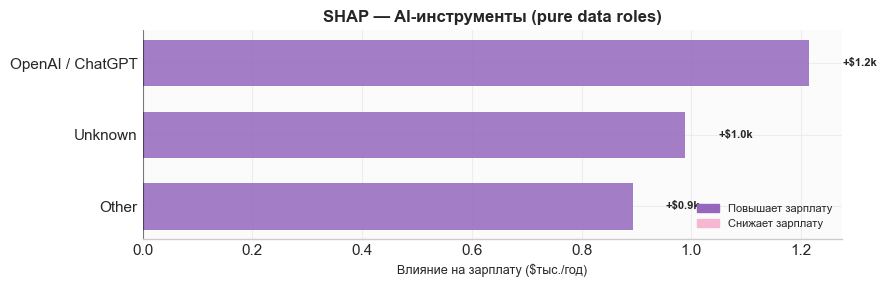


Покрытие навыков в shap_df_pure:
                                n_with_skill    pct  mean_shap  usd_k
None                                  1541.0  100.0     0.0041   1.27
Python                                1282.0   83.2    -0.0016   0.90
SQL                                   1026.0   66.6    -0.0023   0.85
Bash/Shell/PowerShell                  881.0   57.2     0.0048   1.32
C                                      843.0   54.7    -0.0015   0.90
Docker                                 808.0   52.4     0.0097   1.65
PostgreSQL                             728.0   47.2     0.0112   1.75
OpenAI / ChatGPT                       702.0   45.6     0.0032   1.21
Java                                   682.0   44.3    -0.0003   0.98
HTML/CSS                               603.0   39.1    -0.0178  -0.17
JavaScript                             591.0   38.4    -0.0035   0.77
AWS                                    550.0   35.7     0.0450   4.06
SQL Server                             460.0   29.9    -

In [42]:
# ════════════════════════════════════════════════════════════════════════════
# SHAP: полный расчёт — все признаки + мульти-колонки + pure фильтр
# ════════════════════════════════════════════════════════════════════════════

print("Вычисляем SHAP значения...")

# ── 1. Трансформация и базовые объекты ───────────────────────────────────────
X_test_transformed = best_model.named_steps["preprocessor"].transform(features_test)
feat_names         = best_model.named_steps["preprocessor"].get_feature_names_out()
model_only         = best_model.named_steps["regressor"]

explainer  = shap.TreeExplainer(model_only)
shap_vals  = explainer.shap_values(X_test_transformed)
shap_df    = pd.DataFrame(shap_vals, columns=feat_names, index=features_test.index)
skill_meta = generate_skill_meta(feat_names)

print(f"shap_df (all):  {shap_df.shape}")

# ── Pure маска ────────────────────────────────────────────────────────────────
pure_idx  = df[df["data_role_purity"] == 1.0].index
pure_mask = features_test.index.isin(pure_idx)
print(f"Чистых строк в тесте: {pure_mask.sum()}")

if pure_mask.sum() >= 100:
    shap_vals_pure = explainer.shap_values(X_test_transformed[pure_mask])
    shap_df_pure   = pd.DataFrame(
        shap_vals_pure,
        columns=feat_names,
        index=features_test[pure_mask].index,
    )
else:
    print("⚠ Мало pure строк — используем весь shap_df")
    shap_df_pure = shap_df

print(f"shap_df_pure:   {shap_df_pure.shape}")

# ── Исходные признаки для pure-строк (до препроцессора) ──────────────────────
source_all  = features_test                            # весь тест
source_pure = features_test.loc[shap_df_pure.index]   # только pure

# ── Медиана ───────────────────────────────────────────────────────────────────
median_salary_global = float(df["salary"].median())
print(f"median_salary_global: {median_salary_global:.1f}k  (= ${median_salary_global*1000:,.0f})")


# ════════════════════════════════════════════════════════════════════════════
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ════════════════════════════════════════════════════════════════════════════

def shap_log_to_usd_skill(feat, shap_df, median_salary,
                           source_features=None, min_rows=10):
    """
    Считает средний SHAP только по строкам где навык реально присутствует
    в исходных (нетрансформированных) данных.

    SHAP ненулевой для всех строк даже при отсутствии навыка —
    поэтому фильтруем по source_features (исходный DataFrame до препроцессора),
    а не по shap_df[feat] != 0.

    feat            : "multi_language__Python"
    source_features : features_test.loc[shap_df.index] — до препроцессора
    """
    if feat not in shap_df.columns:
        return 0.0

    if source_features is not None and "__" in feat:
        prefix, skill_name = feat.split("__", 1)
        col_name = prefix.replace("multi_", "")  # "language", "database" ...

        if col_name in source_features.columns:
            has_skill = source_features[col_name].str.contains(
                skill_name, regex=False, na=False
            )
            idx = shap_df.index.intersection(source_features[has_skill].index)
        else:
            idx = shap_df.index
    else:
        idx = shap_df.index

    if len(idx) < min_rows:
        return 0.0

    mean_shap = shap_df.loc[idx, feat].mean()
    return float(np.exp(np.log1p(median_salary) + mean_shap) - median_salary)


def plot_shap_global(sv, Xt, feat_names, title, max_display=20):
    """График 1: beeswarm по всем признакам."""
    print(f"\n{title} — топ-{max_display} признаков")
    shap.summary_plot(
        sv, Xt,
        feature_names=feat_names,
        max_display=max_display,
        show=False,
    )
    plt.title(title, fontweight="bold", fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_shap_grouped(sv_df, feat_names, title, max_display=20):
    """
    График 2: признаки сгруппированы по префиксу.
    cat__currency_USD → currency
    multi_language__Python → language
    """
    group_shap = {}
    for col in feat_names:
        if "__" in col:
            prefix, rest = col.split("__", 1)
            if prefix.startswith("multi_"):
                group = prefix.replace("multi_", "")
            else:
                parts = rest.split("_")
                group = parts[0] if parts else rest
        else:
            group = col

        if group not in group_shap:
            group_shap[group] = np.zeros(len(sv_df))
        group_shap[group] += np.abs(sv_df[col].values)

    group_mean = pd.Series(
        {g: vals.mean() for g, vals in group_shap.items()}
    ).sort_values(ascending=False).head(max_display)

    fig, ax = plt.subplots(figsize=(10, max(4, len(group_mean) * 0.45)))
    ax.barh(group_mean.index[::-1], group_mean.values[::-1],
            color=C_BLUE, alpha=0.85, height=0.6)
    ax.set_title(f"{title}\n(признаки сгруппированы)", fontweight="bold", fontsize=12)
    ax.set_xlabel("mean |SHAP|  (сумма по группе, log1p-шкала)", fontsize=9)
    for i, (g, v) in enumerate(group_mean[::-1].items()):
        ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_shap_multi_cols(sv_df, skill_meta, median_sal,
                          source_features,          # ← обязательный параметр
                          title_suffix="",
                          multi_cols_to_show=None,
                          max_per_col=15):
    """
    Графики 3-8: отдельный bar-chart для каждой мульти-колонки.
    Фильтрует SHAP по реальному наличию навыка в source_features.
    """
    if multi_cols_to_show is None:
        multi_cols_to_show = ["language", "database", "platform",
                              "webframe", "tech", "ai"]

    COL_LABELS = {
        "language": "Языки программирования",
        "database": "Базы данных",
        "platform": "Облака и платформы",
        "webframe": "Веб-фреймворки",
        "tech":     "Инструменты и библиотеки",
        "ai":       "AI-инструменты",
    }

    half = max(1, max_per_col // 2)

    for col in multi_cols_to_show:
        level_key = f"multi_{col}"

        feats = [f for f, m in skill_meta.items()
                 if m["level"] == level_key and f in sv_df.columns]
        if not feats:
            print(f"  ⚠ {col}: признаки не найдены в shap_df")
            continue

        skill_usd = {}
        for f in feats:
            # FIX: передаём source_features для фильтрации по реальному наличию
            usd = shap_log_to_usd_skill(
                f, sv_df, median_sal,
                source_features=source_features,
                min_rows=5,
            )
            skill_usd[skill_meta[f]["skill"]] = usd

        skill_series = pd.Series(skill_usd)

        pos = skill_series[skill_series > 0].nlargest(half)
        neg = skill_series[skill_series < 0].nsmallest(half)

        if neg.empty:
            plot_data = skill_series.nlargest(max_per_col).sort_values()
        elif pos.empty:
            plot_data = skill_series.nsmallest(max_per_col).sort_values()
        else:
            plot_data = pd.concat([neg, pos]).sort_values()

        if plot_data.empty:
            print(f"  ⚠ {col}: нет данных для отображения")
            continue

        fig, ax = plt.subplots(figsize=(9, max(3, len(plot_data) * 0.5)))
        colors = [C_RED if v < 0 else C_GREEN for v in plot_data.values]
        ax.barh(plot_data.index, plot_data.values, color=colors,
                alpha=0.85, height=0.65)
        ax.axvline(0, color="black", lw=0.8, alpha=0.5)

        for i, (skill, val) in enumerate(plot_data.items()):
            offset = 0.05 * (plot_data.abs().max() or 1)
            ha = "left" if val >= 0 else "right"
            sign = "+$" if val >= 0 else "-$"
            ax.text(val + (offset if val >= 0 else -offset), i,
                    f"{sign}{abs(val):.1f}k",
                    va="center", ha=ha, fontsize=8, fontweight="bold")

        label = COL_LABELS.get(col, col)
        ax.set_title(f"SHAP — {label}{title_suffix}",
                     fontweight="bold", fontsize=12)
        ax.set_xlabel("Влияние на зарплату ($тыс./год)", fontsize=9)
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color=C_GREEN, label="Повышает зарплату"),
            Patch(color=C_RED,   label="Снижает зарплату"),
        ], loc="lower right", fontsize=8)
        plt.tight_layout()
        plt.show()


# ════════════════════════════════════════════════════════════════════════════
# БЛОК А: ВЕСЬ ДАТАСЕТ
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  БЛОК А — Весь тестовый датасет")
print("═"*62)

plot_shap_global(
    shap_vals, X_test_transformed, feat_names,
    title="SHAP — все признаки (весь тест)",
    max_display=20,
)

plot_shap_grouped(
    shap_df, feat_names,
    title="SHAP — сгруппированные признаки (весь тест)",
    max_display=30,
)

plot_shap_multi_cols(
    shap_df, skill_meta, median_salary_global,
    source_features=source_all,       # ← исходные данные всего теста
    title_suffix=" (весь тест)",
)


# ════════════════════════════════════════════════════════════════════════════
# БЛОК Б: ТОЛЬКО ЧИСТЫЕ ДАТА-СПЕЦИАЛИСТЫ
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*62)
print("  БЛОК Б — Только pure data roles (purity = 1.0)")
print("═"*62)

X_pure = X_test_transformed[pure_mask]

plot_shap_global(
    shap_vals_pure, X_pure, feat_names,
    title="SHAP — все признаки (pure data roles)",
    max_display=20,
)

plot_shap_grouped(
    shap_df_pure, feat_names,
    title="SHAP — сгруппированные признаки (pure data roles)",
    max_display=20,
)

plot_shap_multi_cols(
    shap_df_pure, skill_meta, median_salary_global,
    source_features=source_pure,      # ← исходные данные только pure-строк
    title_suffix=" (pure data roles)",
)


# ════════════════════════════════════════════════════════════════════════════
# ДИАГНОСТИКА покрытия навыков в shap_df_pure
# ════════════════════════════════════════════════════════════════════════════
print("\nПокрытие навыков в shap_df_pure:")
multi_feats = [f for f, m in skill_meta.items()
               if m["level"].startswith("multi_") and f in shap_df_pure.columns]

coverage = {}
for f in multi_feats:
    if f not in shap_df_pure.columns:
        continue

    # FIX: покрытие по исходным данным, а не по ненулевому SHAP
    prefix, skill_name = (f.split("__", 1) if "__" in f else (f, f))
    col_name = prefix.replace("multi_", "")
    if col_name in source_pure.columns:
        n_with_skill = source_pure[col_name].str.contains(
            skill_name, regex=False, na=False
        ).sum()
    else:
        n_with_skill = len(shap_df_pure)

    n_total  = len(shap_df_pure)
    usd      = shap_log_to_usd_skill(
        f, shap_df_pure, median_salary_global,
        source_features=source_pure,
    )

    # mean_shap только по строкам с навыком
    if col_name in source_pure.columns:
        has_skill = source_pure[col_name].str.contains(skill_name, regex=False, na=False)
        idx       = shap_df_pure.index.intersection(source_pure[has_skill].index)
        mean_shap = shap_df_pure.loc[idx, f].mean() if len(idx) > 0 else 0.0
    else:
        mean_shap = shap_df_pure[f].mean()

    coverage[skill_meta[f]["skill"]] = {
        "n_with_skill": n_with_skill,
        "pct":          round(n_with_skill / n_total * 100, 1),
        "mean_shap":    round(mean_shap, 4),
        "usd_k":        round(usd, 2),
    }

coverage_df = (
    pd.DataFrame(coverage).T
    .sort_values("n_with_skill", ascending=False)
)
print(coverage_df.head(30).to_string())
print(f"\nНавыков с usd > 0:           {(coverage_df['usd_k'] > 0).sum()}")
print(f"Навыков с usd < 0:           {(coverage_df['usd_k'] < 0).sum()}")
print(f"Навыков с n < 10 (отфильтр): {(coverage_df['n_with_skill'] < 10).sum()}")

---
## 6. Empfehlungssystem

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

ALL_PIPELINE_COLS = num_cols + cat_cols + pca_cols + multi_cols

# ── Normalisierung der Apostrophe in cfg-Mappings (einmalig beim Laden) ───────
def _fix_apostrophes(mapping: dict) -> dict:
    """Ersetzt typografische Apostrophe ' (U+2019) durch Standard ' (U+0027)."""
    return {
        k.replace("\u2019", "'").replace("\u2018", "'"): v
        for k, v in mapping.items()
    }

cfg.education_mapping      = _fix_apostrophes(cfg.education_mapping)
cfg.education_rank_mapping = _fix_apostrophes(cfg.education_rank_mapping)
cfg.org_size_mapping       = _fix_apostrophes(cfg.org_size_mapping)
cfg.org_size_rank_mapping  = _fix_apostrophes(cfg.org_size_rank_mapping)
cfg.remote_mapping         = _fix_apostrophes(cfg.remote_mapping)
cfg.industry_mapping       = _fix_apostrophes(cfg.industry_mapping)
cfg.icorpm_mapping         = _fix_apostrophes(cfg.icorpm_mapping)

# ── SO Survey → interne Rollenbezeichnungen ───────────────────────────────────
ROLE_NAME_MAPPING = {
    "Data scientist or machine learning specialist": "Data Scientist / ML specialist",
    "Data scientist":                               "Data Scientist / ML specialist",
    "Applied scientist":                            "Applied scientist",
    "Data engineer":                                "Data Engineer",
    "Engineer, data":                               "Data Engineer",
    "AI/ML engineer":                               "AI/ML Engineer",
    "Database administrator":                       "Database Administrator",
    "Database administrator or engineer":           "Database Administrator",
    "Data or business analyst":                     "Data Analyst",
    "Financial analyst or engineer":                "Financial Analyst",
    "Scientist":                                    "Scientist",
}

DATA_ROLE_SKILLS = {
    "Data Analyst": {
        "Python", "SQL", "R", "Tableau", "Power BI", "Looker", "Qlik",
        "dbt", "BigQuery", "Snowflake", "PostgreSQL", "MySQL",
        "Microsoft SQL Server", "MongoDB", "Spark", "Airflow",
        "Pandas", "NumPy", "Matplotlib", "Seaborn", "Plotly",
        "Excel", "Google Sheets", "Metabase",
    },
    "Data Scientist / ML specialist": {
        "Python", "SQL", "R", "Scala", "Julia",
        "PyTorch", "TensorFlow", "Scikit-Learn", "Keras", "MLflow",
        "Spark", "Airflow", "dbt", "BigQuery", "Snowflake",
        "PostgreSQL", "MongoDB", "Redis",
        "AWS", "Google Cloud", "Microsoft Azure", "Docker",
        "Pandas", "NumPy", "Matplotlib", "Seaborn", "Plotly", "OpenCV",
        "OpenAI / ChatGPT", "Claude", "Google Gemini", "GitHub Copilot",
    },
    "Data Engineer": {
        "Python", "SQL", "Scala", "Java", "Bash/Shell/PowerShell",
        "Spark", "Airflow", "dbt", "Kafka",
        "BigQuery", "Snowflake", "PostgreSQL", "MySQL",
        "Microsoft SQL Server", "MongoDB", "Redis", "Cassandra",
        "Elasticsearch", "DynamoDB",
        "AWS", "Google Cloud", "Microsoft Azure",
        "Docker", "Kubernetes", "Terraform", "Ansible",
    },
    "Database Administrator": {
        "SQL", "Python", "Bash/Shell/PowerShell",
        "PostgreSQL", "MySQL", "Microsoft SQL Server", "Oracle",
        "MongoDB", "Redis", "Cassandra", "Elasticsearch",
        "AWS", "Google Cloud", "Microsoft Azure", "Docker",
    },
    "AI/ML Engineer": {
        "Python", "Scala", "Julia", "Rust",
        "PyTorch", "TensorFlow", "Scikit-Learn", "Keras", "MLflow", "OpenCV",
        "Spark", "Airflow", "Docker", "Kubernetes",
        "AWS", "Google Cloud", "Microsoft Azure",
        "OpenAI / ChatGPT", "Claude", "Google Gemini", "GitHub Copilot",
        "BigQuery", "Snowflake", "PostgreSQL", "MongoDB",
    },
    "Applied scientist": {
        "Python", "R", "SQL", "Scala", "Julia",
        "PyTorch", "TensorFlow", "Scikit-Learn", "Keras", "MLflow",
        "Spark", "Pandas", "NumPy", "Matplotlib", "Seaborn", "Plotly",
        "AWS", "Google Cloud", "Microsoft Azure", "Docker",
    },
    "Financial Analyst": {
        "Python", "SQL", "R", "VBA",
        "Excel", "Google Sheets", "Power BI", "Tableau", "Looker",
        "PostgreSQL", "MySQL", "Microsoft SQL Server",
        "Pandas", "NumPy", "Matplotlib", "Plotly",
    },
    "Scientist": {
        "Python", "R", "SQL", "Julia", "Matlab",
        "PyTorch", "TensorFlow", "Scikit-Learn", "Keras",
        "Pandas", "NumPy", "Matplotlib", "Seaborn", "Plotly",
        "AWS", "Google Cloud", "Docker",
    },
}
_ALL_DATA_SKILLS = set().union(*DATA_ROLE_SKILLS.values())

COUNTRY_CURRENCY = {
    "Germany":        "EUR European Euro",
    "France":         "EUR European Euro",
    "Netherlands":    "EUR European Euro",
    "Spain":          "EUR European Euro",
    "Italy":          "EUR European Euro",
    "Poland":         "EUR European Euro",
    "Switzerland":    "CHF Swiss Franc",
    "United Kingdom": "GBP British Pound",
    "United States":  "USD US Dollar",
    "Canada":         "CAD Canadian Dollar",
    "Australia":      "AUD Australian Dollar",
    "India":          "INR Indian Rupee",
    "Brazil":         "BRL Brazilian Real",
    "Japan":          "JPY Japanese Yen",
}


def shap_log_to_usd_skill(feat, shap_df, median_salary,
                           source_features=None, min_rows=10):
    """
    Berechnet den mittleren SHAP-Wert nur für Zeilen,
    in denen der Skill tatsächlich vorhanden ist (Quelldaten vor dem Preprocessor).

    TreeExplainer liefert für ALLE Zeilen Nicht-Null-SHAP-Werte,
    daher filtern wir über source_features statt shap != 0.
    """
    if feat not in shap_df.columns:
        return 0.0

    if source_features is not None and "__" in feat:
        prefix, skill_name = feat.split("__", 1)
        col_name = prefix.replace("multi_", "")

        if col_name in source_features.columns:
            has_skill = source_features[col_name].str.contains(
                skill_name, regex=False, na=False
            )
            idx = shap_df.index.intersection(source_features[has_skill].index)
        else:
            idx = shap_df.index
    else:
        idx = shap_df.index

    if len(idx) < min_rows:
        return 0.0

    mean_shap = shap_df.loc[idx, feat].mean()
    return float(np.exp(np.log1p(median_salary) + mean_shap) - median_salary)


class DataCareerAdvisor:

    def __init__(self, df, skill_meta, pipeline, shap_df,
                 source_features=None, features_train=None):
        self.df              = df.copy()
        self.skill_meta      = skill_meta
        self.pipeline        = pipeline
        self.shap_df         = shap_df
        self.source_features = source_features

        if features_train is not None and "temporal_weight" in features_train.columns:
            self.tw_by_year = (
                features_train.groupby("year")["temporal_weight"]
                .median()
            )
        else:
            self.tw_by_year = pd.Series({
                2020: 0.5, 2021: 0.7, 2022: 1.0,
                2023: 1.5, 2024: 2.5, 2025: 3.0,
            })

        self.skill_price = {}
        for feat, meta in skill_meta.items():
            if not meta["level"].startswith("multi_"): continue
            if feat not in shap_df.columns: continue
            usd = shap_log_to_usd_skill(
                feat, shap_df, median_salary_global,
                source_features=self.source_features,
            )
            self.skill_price[meta["skill"]] = usd

    @staticmethod
    def _fix_input(s: str) -> str:
        """Normalisiert typografische Apostrophe in Eingabestrings."""
        return str(s).replace("\u2019", "'").replace("\u2018", "'").strip()

    def _normalize_role(self, role: str) -> str:
        """Übersetzt SO-Survey-Rollenname in internen Namen für DATA_ROLE_SKILLS."""
        return ROLE_NAME_MAPPING.get(role, role)

    # ── available_* Methoden ─────────────────────────────────────────────────

    def available_roles(self):
        """Liste der Rollen (SO-Survey-Namen — in profile['role'] eingeben)."""
        roles = (
            self.df["devtype_data"]
            .dropna().str.split(";").explode().str.strip()
            .value_counts()
        )
        print("Verfügbare Rollen (in profile['role'] eingeben):\n")
        for role in roles.index:
            print(f"  {role}")

    def available_countries(self):
        """Liste der Länder nach Feature Engineering."""
        print("Verfügbare Länder (in profile['country'] eingeben):\n")
        for val in self.df["country"].dropna().value_counts().index:
            print(f"  {val}")

    def available_education(self):
        """Liste der Bildungsabschlüsse nach Feature Engineering."""
        print("Verfügbare Bildungsabschlüsse (in profile['education'] eingeben):\n")
        for val in self.df["education"].dropna().value_counts().index:
            print(f"  {val}")

    def available_remote(self):
        """Liste der Arbeitsformate nach Feature Engineering."""
        print("Verfügbare Arbeitsformate (in profile['remote'] eingeben):\n")
        for val in self.df["remote"].dropna().value_counts().index:
            print(f"  {val}")

    def available_org_sizes(self):
        """Liste der Unternehmensgrößen nach Feature Engineering."""
        print("Verfügbare Unternehmensgrößen (in profile['org_size'] eingeben):\n")
        for val in self.df["org_size"].dropna().value_counts().index:
            print(f"  {val}")

    def available_industries(self):
        """Liste der Branchen nach Feature Engineering."""
        print("Verfügbare Branchen (in profile['industry'] eingeben):\n")
        for val in self.df["industry"].dropna().value_counts().index:
            print(f"  {val}")

    def available_icorpm(self):
        """IC oder Manager nach Feature Engineering."""
        print("Verfügbare icorpm-Werte (in profile['icorpm'] eingeben):\n")
        for val in self.df["icorpm"].dropna().value_counts().index:
            print(f"  {val}")

    def available_skills(self, role=None):
        """Skills aus der Whitelist für eine Rolle. role — SO-Survey-Name."""
        role_normalized = self._normalize_role(role) if role else None
        skills = DATA_ROLE_SKILLS.get(role_normalized, _ALL_DATA_SKILLS) \
                 if role_normalized else _ALL_DATA_SKILLS
        label  = f"'{role_normalized}'" if role_normalized else "alle Data-Rollen"
        print(f"Skills für {label}:\n")
        for skill in sorted(skills):
            print(f"  {skill}")

    # ── Hauptmethoden ─────────────────────────────────────────────────────────

    def get_context_median(self, country: str, role: str) -> float:
        """
        Gibt den Median in Tausend zurück (wie df["salary"]).
        role und country — wie in df (nach features_engineering).
        """
        df = self.df
        mask_both    = (
            (df["country"] == country) &
            (df["devtype_data"].str.contains(role, regex=False, na=False))
        )
        mask_country = (df["country"] == country)

        for mask in (mask_both, mask_country):
            sub = df.loc[mask, "salary"].dropna()
            if len(sub) >= 30:
                return float(sub.median())

        return float(median_salary_global)

    def _build_profile_row(self, profile):
        country      = profile.get("country", "Germany")
        role         = profile.get("role", "Data or business analyst")
        years_exp    = int(profile.get("years_experience", 3))
        year_profile = int(profile.get("year", 2024))

        # ── Normalisierung + Mapping wie in features_engineering ─────────────
        edu_raw  = self._fix_input(profile.get("education",
                                   "Bachelor's degree (B.A., B.S., B.Eng., etc.)"))
        edu_can  = cfg.education_mapping.get(edu_raw, edu_raw)
        edu_rank = cfg.education_rank_mapping.get(edu_can, 0)

        org_raw  = self._fix_input(profile.get("org_size", "100 to 499 employees"))
        org_can  = cfg.org_size_mapping.get(org_raw, org_raw)
        org_rank = cfg.org_size_rank_mapping.get(org_can, 0)

        remote_raw   = self._fix_input(profile.get("remote", "Hybrid"))
        remote_can   = cfg.remote_mapping.get(remote_raw, remote_raw)

        industry_raw = self._fix_input(profile.get("industry", "IT, Telecom & Tech"))
        industry_can = cfg.industry_mapping.get(industry_raw, industry_raw)

        icorpm_raw   = self._fix_input(profile.get("icorpm", "IC"))
        icorpm_can   = cfg.icorpm_mapping.get(icorpm_raw, icorpm_raw)

        # Ländernormalisierung wie in features_engineering
        country_can = country
        if country_can == "United States of America":
            country_can = "United States"
        elif country_can == "United Kingdom of Great Britain and Northern Ireland":
            country_can = "Great Britain"
        country_can = cfg.country_mapping.get(country_can, country_can)

        # Währung aus df für das Land — nicht über categorize_currency
        currency_mask = self.df["country"] == country_can
        if currency_mask.sum() > 0:
            currency_can = self.df.loc[currency_mask, "currency"].mode()[0]
        else:
            currency_can = "USD US Dollar"

        region = cfg.region_mapping.get(country, "Other")

        # ── Mediane ───────────────────────────────────────────────────────────
        def _safe_median(mask, fallback):
            sub = self.df.loc[mask, "salary"].dropna()
            return float(sub.median()) if len(sub) >= 10 else fallback

        global_med       = float(median_salary_global)
        country_med      = _safe_median(
            self.df["country"] == country_can, global_med)
        country_role_med = _safe_median(
            (self.df["country"] == country_can) &
            (self.df["devtype_data"].str.contains(role, regex=False, na=False)),
            country_med)
        region_med       = _safe_median(
            self.df["country_region"] == region, global_med)
        region_role_med  = _safe_median(
            (self.df["country_region"] == region) &
            (self.df["devtype_data"].str.contains(role, regex=False, na=False)),
            region_med)

        # temporal_weight aus features_train
        tw = self.tw_by_year.get(year_profile, None)
        tw = float(tw) if tw is not None and not pd.isna(tw) \
             else float(self.tw_by_year.max())

        row = {
            # ── num_cols ──────────────────────────────────────────────
            "year":                  year_profile,
            "education_rank":        edu_rank,
            "org_size_rank":         org_rank,
            "work_exp":              years_exp,
            "years_code":            years_exp + 2,
            "temporal_weight":       tw,
            "is_usa":                int(country in ("United States",
                                                      "United States of America")),
            "is_germany":            int(country == "Germany"),
            "country_salary_median": country_med,
            "country_role_median":   country_role_med,
            "region_salary_median":  region_med,
            "region_role_median":    region_role_med,

            # ── cat_cols ──────────────────────────────────────────────
            "country":               country_can,
            "currency":              currency_can,
            "remote":                remote_can,
            "branch":                "Professional",
            "education":             edu_can,
            "employment":            "Employed, full-time",
            "industry":              industry_can,
            "org_size":              org_can,
            "icorpm":                icorpm_can,
            "data_role":             role,
            "country_region":        region,
        }

        user_skills = [s.strip() for s in profile.get("skills", [])]

        LANG_KNOWN = {"Python","SQL","R","Java","C++","Go","Rust","Scala",
                      "TypeScript","JavaScript","Bash/Shell/PowerShell","HTML/CSS",
                      "PHP","C#","Kotlin","Swift","Ruby","VBA","Dart","Matlab",
                      "LISP","COBOL","Perl","Julia","Haskell","Groovy"}
        DB_KNOWN   = {"PostgreSQL","MySQL","MongoDB","Redis","Snowflake","BigQuery",
                      "Elasticsearch","DynamoDB","SQLite","Microsoft SQL Server",
                      "Oracle","Cassandra","CockroachDB","Neo4J","Firebase"}
        PLAT_KNOWN = {"AWS","Google Cloud","Microsoft Azure","Docker","Kubernetes",
                      "Terraform","Heroku","DigitalOcean","Ansible","Linode, now Akamai"}
        WEB_KNOWN  = {"FastAPI","Flask","Django","Streamlit","React","Angular",
                      "Vue.js","Node.js","Spring Framework","ASP.NET Core"}
        TECH_KNOWN = {"Scikit-Learn","TensorFlow","PyTorch","Pandas","NumPy","Spark",
                      "Airflow","dbt","Tableau","Power BI","Looker","Matplotlib",
                      "Seaborn","Plotly","OpenCV","MLflow","Keras"}
        AI_KNOWN   = {"OpenAI / ChatGPT","Claude","Google Gemini","GitHub Copilot",
                      "DeepSeek","Meta AI","Perplexity AI","Tabnine","Codeium"}

        row["language"]  = ";".join(s for s in user_skills if s in LANG_KNOWN)
        row["database"]  = ";".join(s for s in user_skills if s in DB_KNOWN)
        row["platform"]  = ";".join(s for s in user_skills if s in PLAT_KNOWN)
        row["webframe"]  = ";".join(s for s in user_skills if s in WEB_KNOWN)
        row["tech"]      = ";".join(s for s in user_skills if s in TECH_KNOWN)
        row["ai"]        = ";".join(s for s in user_skills if s in AI_KNOWN)
        row["ai_agents"] = ""
        row["ai_select"] = "Yes" if row["ai"] else "No"

        row["devtype_data"]  = role
        row["devtype_other"] = "None"

        OFFICE_TOOLS = {"Power BI","Tableau","Looker","Qlik","Metabase",
                        "Excel","Google Sheets","SPSS","SAS","Stata"}
        found = [s for s in user_skills if s in OFFICE_TOOLS]
        row["office_tools_used"] = ";".join(found) if found else "None"

        row["role_count"]       = 1
        row["data_role_purity"] = 1.0
        for col in num_cols:
            if col not in row:
                if col.startswith("count_"):
                    row[col] = 1 if col == "count_data" else 0
                elif col.startswith("has_"):
                    row[col] = 1 if col == "has_data" else 0
                else:
                    row[col] = 0

        return pd.DataFrame([row])

    def predict_salary(self, profile):
        X    = self._build_profile_row(profile)
        pred = self.pipeline.predict(X)[0]
        return float(np.expm1(pred)) * 1000

    def recommend_skills_to_learn(self, profile, top_n=5):
        user_skills     = {s.lower() for s in profile.get("skills", [])}
        role            = profile.get("role", "")
        country         = profile.get("country", "Germany")
        role_normalized = self._normalize_role(role)
        allowed         = {s.lower() for s in
                           DATA_ROLE_SKILLS.get(role_normalized, _ALL_DATA_SKILLS)}
        context_median  = self.get_context_median(country, role)

        EXCLUDE    = {"multi_devtype_data", "multi_devtype_other"}
        candidates = {}

        for feat, meta in self.skill_meta.items():
            if meta["level"] in EXCLUDE or not meta["level"].startswith("multi_"):
                continue
            if feat not in self.shap_df.columns:
                continue
            skill = meta["skill"]
            if skill.lower() in user_skills:
                continue
            if skill.lower() not in allowed:
                continue
            usd = shap_log_to_usd_skill(
                feat, self.shap_df, context_median,
                source_features=self.source_features,
            )
            if usd > 0:
                candidates[skill] = usd

        return sorted(candidates.items(), key=lambda x: -x[1])[:top_n]

    def recommend_country(self, profile, min_n=30, top_n=5):
        role = profile.get("role", "Data or business analyst")
        mask = self.df["devtype_data"].str.contains(role, regex=False, na=False)
        return (self.df[mask].groupby("country")["salary"]
                   .agg(["median", "count"])
                   .query(f"count >= {min_n}")
                   .sort_values("median", ascending=False)
                   .head(top_n))

    def full_report(self, profile):
        SEP          = "=" * 62
        country      = profile.get("country", "—")
        role         = profile.get("role", "—")
        role_display = ROLE_NAME_MAPPING.get(role, role)

        valid_roles = set(self.df["devtype_data"].dropna().str.strip().unique())
        if role not in valid_roles:
            print(f"⚠ Rolle '{role}' nicht in den Daten gefunden.")
            print("  Verwende advisor.available_roles() für die Rollenliste.")
            return

        print(SEP)
        print("  📊 DATA CAREER ADVISOR — GEHALTSREPORT")
        print(SEP)
        print(f"  Rolle:        {role_display}")
        print(f"  Skills:       {', '.join(profile.get('skills', []))}")
        print(f"  Erfahrung:    {profile.get('years_experience', 0)} Jahre")
        print(f"  Land:         {country}")
        print(f"  Abschluss:    {profile.get('education', '—')}")
        print(f"  Arbeitsform:  {profile.get('remote', '—')}")

        salary = self.predict_salary(profile)
        print(f"\n  💰 Erwartetes Gehalt: ${salary:,.0f} / Jahr")

        ctx_median = self.get_context_median(country, role)
        print(f"  📍 Marktmedian ({country}, {role_display}): "
              f"${ctx_median * 1000:,.0f} / Jahr")

        recs = self.recommend_skills_to_learn(profile, top_n=5)
        if recs:
            print(f"\n  📚 Top-5 Skills zum Erlernen:")
            for skill, usd in recs:
                meta  = next((m for m in self.skill_meta.values()
                               if m["skill"] == skill), {})
                level = meta.get("level", "").replace("multi_", "")
                print(f"     {skill:<24}  +${usd * 1000:>8,.0f}/Jahr   [{level}]")

        print(SEP)

    def diagnose(self, profile):
        """Profildiagnose — was das Modell sieht."""
        role    = profile.get("role", "—")
        country = profile.get("country", "—")
        X_row   = self._build_profile_row(profile)

        print("=== Numerische Merkmale des Profils ===")
        for col in num_cols:
            if col in X_row.columns:
                print(f"  {col:<30} = {X_row[col].values[0]}")

        print("\n=== Kategorische Merkmale ===")
        for col in cat_cols:
            if col in X_row.columns:
                print(f"  {col:<30} = {X_row[col].values[0]}")

        print("\n=== Target Encoding (Mediane) ===")
        for col in ["country_salary_median", "country_role_median",
                    "region_salary_median",  "region_role_median"]:
            if col in X_row.columns:
                val = X_row[col].values[0]
                print(f"  {col:<30} = {val:.2f}k  (= ${val*1000:,.0f})")

        print("\n=== Vorhersage ===")
        raw = self.pipeline.predict(X_row)[0]
        print(f"  Rohvorhersage (log1p): {raw:.4f}")
        print(f"  expm1(raw):            {np.expm1(raw):.2f}k")
        print(f"  Ergebnis $:            ${np.expm1(raw)*1000:,.0f}")

        print("\n=== Vergleich mit realen Daten ===")
        mask    = (
            (self.df["country"] == country) &
            (self.df["devtype_data"].str.contains(role, regex=False, na=False))
        )
        sub_all = self.df[mask]
        print(f"  {country} + '{role}': {len(sub_all)} Zeilen")
        if len(sub_all) > 0:
            print(f"  Median (alle):    {sub_all['salary'].median():.1f}k"
                  f"  (= ${sub_all['salary'].median()*1000:,.0f})")
            print(f"  25. Perzentil:    {sub_all['salary'].quantile(0.25):.1f}k"
                  f"  (= ${sub_all['salary'].quantile(0.25)*1000:,.0f})")
            print(f"  75. Perzentil:    {sub_all['salary'].quantile(0.75):.1f}k"
                  f"  (= ${sub_all['salary'].quantile(0.75)*1000:,.0f})")


# ── Initialisierung ────────────────────────────────────────────────────────────
advisor = DataCareerAdvisor(
    df              = df,
    skill_meta      = skill_meta,
    pipeline        = best_model,
    shap_df         = shap_df_pure,
    source_features = source_pure,
    features_train  = features_train,
)
print("✓ DataCareerAdvisor initialisiert")

✓ DataCareerAdvisor initialisiert


In [52]:
advisor.available_roles()
advisor.available_countries()
advisor.available_education()
advisor.available_remote()
advisor.available_org_sizes()
advisor.available_industries()
advisor.available_icorpm()
advisor.available_skills()

Verfügbare Rollen (in profile['role'] eingeben):

  Unknown
  Database administrator
  Data scientist or machine learning specialist
  Engineer, data
  Data or business analyst
  Scientist
  Data engineer
  Data scientist
  AI/ML engineer
  Applied scientist
  Database administrator or engineer
  Financial analyst or engineer
Verfügbare Länder (in profile['country'] eingeben):

  United States of America
  Germany
  United Kingdom of Great Britain and Northern Ireland
  India
  Canada
  France
  United States
  Brazil
  Netherlands
  Poland
  Spain
  Australia
  Italy
  Sweden
  Ukraine
  Switzerland
  Russian Federation
  United Kingdom
  Austria
  Czech Republic
  Israel
  Turkey
  Denmark
  Belgium
  Norway
  Portugal
  Romania
  Finland
  Mexico
  South Africa
  New Zealand
  Greece
  Argentina
  Hungary
  Ireland
  Bulgaria
  Colombia
  Japan
  Pakistan
  Iran, Islamic Republic of...
  China
  Serbia
  Slovenia
  Bangladesh
  Slovakia
  Lithuania
  Croatia
  Chile
  Indonesia
  Si

In [53]:
# Junior Data Analyst in Germany
profile_junior_de = {
    "role":             "Data or business analyst",
    "skills":           ["Python", "SQL", "Pandas", "MySQL", "NumPy"],
    "years_experience": 2,
    "country":          "Germany",
    "education":        "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    "remote":           "Hybrid",
    "year":             2025,
}
advisor.full_report(profile_junior_de)
#advisor.diagnose(profile_junior_de)

  📊 DATA CAREER ADVISOR — GEHALTSREPORT
  Rolle:        Data Analyst
  Skills:       Python, SQL, Pandas, MySQL, NumPy
  Erfahrung:    2 Jahre
  Land:         Germany
  Abschluss:    Master's degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Hybrid

  💰 Erwartetes Gehalt: $56,863 / Jahr
  📍 Marktmedian (Germany, Data Analyst): $64,860 / Jahr

  📚 Top-5 Skills zum Erlernen:
     PostgreSQL                +$   1,743/Jahr   [database]
     MongoDB                   +$     681/Jahr   [database]


In [54]:
# Senior Data Scientist in USA
profile_senior_us = {
    "role":             "Data scientist or machine learning specialist",
    "skills":           ["Python", "SQL", "PyTorch", "TensorFlow",
                         "AWS", "Docker", "Kubernetes", "Spark", "Airflow",
                         "OpenAI / ChatGPT"],
    "years_experience": 8,
    "country":          "United States",
    "education":        "Master's degree (M.A., M.S., M.Eng., MBA, etc.)",
    "remote":           "Remote",
    "org_size":         "1,000 to 4,999 employees",
    "year":             2025,
}
advisor.full_report(profile_senior_us)

  📊 DATA CAREER ADVISOR — GEHALTSREPORT
  Rolle:        Data Scientist / ML specialist
  Skills:       Python, SQL, PyTorch, TensorFlow, AWS, Docker, Kubernetes, Spark, Airflow, OpenAI / ChatGPT
  Erfahrung:    8 Jahre
  Land:         United States
  Abschluss:    Master's degree (M.A., M.S., M.Eng., MBA, etc.)
  Arbeitsform:  Remote

  💰 Erwartetes Gehalt: $135,900 / Jahr
  📍 Marktmedian (United States, Data Scientist / ML specialist): $126,057 / Jahr

  📚 Top-5 Skills zum Erlernen:
     Redis                     +$   6,496/Jahr   [database]
     Google Cloud              +$   5,248/Jahr   [platform]
     PostgreSQL                +$   2,433/Jahr   [database]
     Microsoft Azure           +$   1,850/Jahr   [platform]
     MongoDB                   +$     385/Jahr   [database]
